In [1]:
# Import required libraries
import numpy as np

import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from shapely.geometry import Point
import rioxarray
import rasterio
from rasterio import features
from dask.distributed import Client
# Set plotting style
#plt.style.use('seaborn-v0_8-darkgrid')

%matplotlib inline



In [8]:
pip install cartopy


Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install dask

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install dask[distributed]

Note: you may need to restart the kernel to use updated packages.


In [2]:
client = Client(n_workers=2, threads_per_worker=2, memory_limit='4GB')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 7.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36667,Workers: 2
Dashboard: http://127.0.0.1:8787/status,Total threads: 4
Started: Just now,Total memory: 7.45 GiB
Comm: tcp://127.0.0.1:44037,Total threads: 2
Dashboard: http://127.0.0.1:46515/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:40391,


In [3]:
def mask_df_optimized(ds, shapefile_path=None):
    """
    Mask AND crop dataset to shapefile.
    Keeps only grid points inside the shapefile extent.
    """

    if shapefile_path is None:
        shapefile_path = (
            f"/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp")

    # ---- CACHE SHAPEFILE ----
    if not hasattr(mask_df_optimized, "_shp_cache"):
        mask_df_optimized._shp_cache = {}

    if shapefile_path not in mask_df_optimized._shp_cache:
        shp = gpd.read_file(shapefile_path)
        mask_df_optimized._shp_cache[shapefile_path] = shp
    else:
        shp = mask_df_optimized._shp_cache[shapefile_path]

    # ---- CRS CHECK ----
    if ds.rio.crs is None:
        ds = ds.rio.write_crs("EPSG:4326", inplace=True)

    shp = shp.to_crs(ds.rio.crs)

    # ---- CACHE RASTER MASK ----
    mask_key = (ds.sizes['latitude'], ds.sizes['longitude'], shapefile_path)

    if not hasattr(mask_df_optimized, "_mask_cache"):
        mask_df_optimized._mask_cache = {}

    if mask_key not in mask_df_optimized._mask_cache:
        mask = features.rasterize(
            [(geom, 1) for geom in shp.geometry],
            out_shape=(ds.sizes['latitude'], ds.sizes['longitude']),
            transform=rasterio.transform.from_bounds(
                *ds.rio.bounds(),
                ds.sizes['longitude'],
                ds.sizes['latitude']
            ),
            fill=0,
            dtype="uint8",
        )
        mask_df_optimized._mask_cache[mask_key] = mask
    else:
        mask = mask_df_optimized._mask_cache[mask_key]

    # ---- CREATE MASK AS DATAARRAY ----
    mask_da = xr.DataArray(mask, coords=[ds["latitude"], ds["longitude"]], dims=["latitude", "longitude"])

    # ---- APPLY MASK ----
    ds_masked = ds.where(mask_da == 1)

    # -------------------------------------------------------------------
    # NEW: CROP TO THE SHAPEFILE BOUNDING BOX (to reduce grid points)
    # -------------------------------------------------------------------
    minx, miny, maxx, maxy = shp.total_bounds

    ds_cropped = ds_masked.sel(
        longitude=slice(minx, maxx),
        latitude=slice(maxy, miny) if ds.latitude[0] > ds.latitude[-1] else slice(miny, maxy)
    )

    return ds_cropped



In [4]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_ACCESS-CM2_historical_rpf_gn_1985_2014_Nigeria_regrid.nc"
ds_ACCESS_CM2_historical = xr.open_dataset(file)
ds_ACCESS_CM2_historical

<xarray.Dataset>
Dimensions:    (time: 30, bnds: 2, longitude: 229, latitude: 188)
Coordinates:
  * time       (time) datetime64[ns] 1985-07-02T12:00:00 ... 2014-07-02T12:00:00
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    tas        (time, latitude, longitude) float32 ...
Attributes: (12/24)
    CDI:                   Climate Data Interface version 2.4.0 (https://mpim...
    Conventions:           CF-1.7
    source:                BCSD
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    history:               Mon Dec 22 16:04:19 2025: cdo yearmean tas_day_ACC...
    activity:              NEX-GDDP-CMIP6
    ...                    ...
    disclaimer:            This data is considered provisional and subject to...
    external_variables:    areacella
    cmip6_source_id:       ACCESS-CM2
    cmip6_institution_id:  CSIRO-ARCCSS
    cmip6_license:         CC-BY-SA 4.0
    CDO:                   Climate Data Operators version 2.4.0 (https://mpim...

In [5]:
ds_mask_ACCESS_historical = mask_df_optimized(ds_ACCESS_CM2_historical)
ds_mask_ACCESS_historical

<xarray.Dataset>
Dimensions:      (time: 30, bnds: 2, latitude: 188, longitude: 229)
Coordinates:
  * time         (time) datetime64[ns] 1985-07-02T12:00:00 ... 2014-07-02T12:...
  * longitude    (longitude) float32 2.775 2.825 2.875 ... 14.07 14.12 14.17
  * latitude     (latitude) float32 4.325 4.375 4.425 ... 13.57 13.62 13.67
    spatial_ref  int64 0
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (time, bnds, latitude, longitude) datetime64[ns] NaT ... NaT
    tas          (time, latitude, longitude) float32 nan nan nan ... nan nan nan
Attributes: (12/24)
    CDI:                   Climate Data Interface version 2.4.0 (https://mpim...
    Conventions:           CF-1.7
    source:                BCSD
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    history:               Mon Dec 22 16:04:19 2025: cdo yearmean tas_day_ACC...
    activity:              NEX-GDDP-CMIP6
    ...                    ...
    disclaimer:            This data is considered provisional and subject to...
    external_variables:    areacella
    cmip6_source_id:       ACCESS-CM2
    cmip6_institution_id:  CSIRO-ARCCSS
    cmip6_license:         CC-BY-SA 4.0
    CDO:                   Climate Data Operators version 2.4.0 (https://mpim...

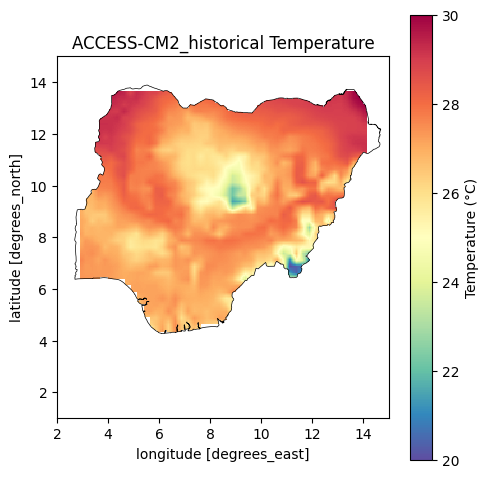

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Select date and convert K → °C
time_0 = (
    ds_mask_ACCESS_historical['tas']
    .sel(time="1985-07-02", method="nearest")
    - 273.15
)

# Ensure CRS on raster
if not hasattr(time_0.rio, 'crs') or time_0.rio.crs is None:
    time_0.rio.write_crs("EPSG:4326", inplace=True)

# Read Nigeria boundary
shapefile = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"
shp = gpd.read_file(shapefile).to_crs(time_0.rio.crs)

# 🔹 CLIP raster to Nigeria
time_0_clip = time_0.rio.clip(
    shp.geometry,
    shp.crs,
    drop=True
)

# Plot clipped data with vmin and vmax set to -20 and 20
time_0_clip.plot(
    ax=ax,
    cmap="Spectral_r",
    vmin=20,
    vmax=30,
    cbar_kwargs={"label": "Temperature (°C)"}
)

# Plot Nigeria boundary
shp.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)
ax.set_xlim(2, 15)
ax.set_ylim(1, 15)

plt.title("ACCESS-CM2_historical Temperature")
plt.tight_layout()
plt.show()

In [7]:
ds_mask_ACCESS_historical

<xarray.Dataset>
Dimensions:      (time: 30, bnds: 2, latitude: 188, longitude: 229)
Coordinates:
  * time         (time) datetime64[ns] 1985-07-02T12:00:00 ... 2014-07-02T12:...
  * longitude    (longitude) float32 2.775 2.825 2.875 ... 14.07 14.12 14.17
  * latitude     (latitude) float32 4.325 4.375 4.425 ... 13.57 13.62 13.67
    spatial_ref  int64 0
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (time, bnds, latitude, longitude) datetime64[ns] NaT ... NaT
    tas          (time, latitude, longitude) float32 nan nan nan ... nan nan nan
Attributes: (12/24)
    CDI:                   Climate Data Interface version 2.4.0 (https://mpim...
    Conventions:           CF-1.7
    source:                BCSD
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    history:               Mon Dec 22 16:04:19 2025: cdo yearmean tas_day_ACC...
    activity:              NEX-GDDP-CMIP6
    ...                    ...
    disclaimer:            This data is considered provisional and subject to...
    external_variables:    areacella
    cmip6_source_id:       ACCESS-CM2
    cmip6_institution_id:  CSIRO-ARCCSS
    cmip6_license:         CC-BY-SA 4.0
    CDO:                   Climate Data Operators version 2.4.0 (https://mpim...

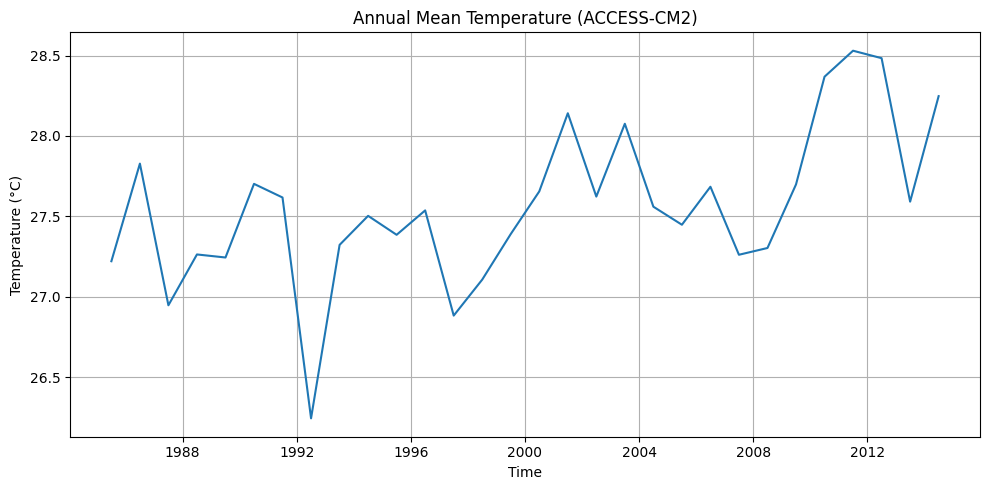

In [8]:
import matplotlib.pyplot as plt

# Compute Nigeria mean temperature
Nigeria_mean = (
    ds_mask_ACCESS_historical
    .mean(dim=['longitude', 'latitude'])
    .to_dataframe()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(Nigeria_mean['time'], Nigeria_mean['tas'] - 273.15)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Annual Mean Temperature (ACCESS-CM2)")
plt.grid(True)
plt.tight_layout()

# 🔹 SAVE FIGURE
plt.savefig(
    "/media/precious/Tpresh/CCI_2025/Nigeria_Mean_Temperature_ACCESS_CM2.png",
    dpi=300,
    bbox_inches="tight"
)

# Optional JPG version
plt.savefig(
    "/media/precious/Tpresh/CCI_2025/Nigeria_Mean_Temperature_ACCESS_CM2.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


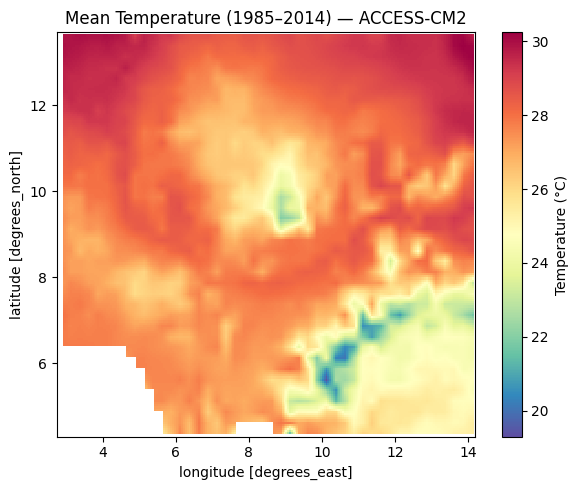

In [9]:
import matplotlib.pyplot as plt

# Select period and convert K → °C
time_2014 = (
    ds_ACCESS_CM2_historical['tas']
    .sel(time=slice("1985-07-02", "2014-07-02"))
    - 273.15
)

# Compute time mean
time_mean = time_2014.mean(dim="time")

# Plot
plt.figure(figsize=(6, 5))
time_mean.plot(cmap="Spectral_r", cbar_kwargs={"label": "Temperature (°C)"})
plt.title("Mean Temperature (1985–2014) — ACCESS-CM2")
plt.tight_layout()

# 🔹 SAVE FIGURE
plt.savefig(
    "/media/precious/Tpresh/CCI_2025/ACCESS_CM2_Mean_Temperature_1985_2014.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [10]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_MPI-ESM1-2-HR_historical_rpf_gn_1985_2014_Nigeria_regrid.nc"
ds_MPI_ESM1_2_HR_historical = xr.open_dataset(file)
ds_MPI_ESM1_2_HR_historical

<xarray.Dataset>
Dimensions:    (time: 30, bnds: 2, longitude: 229, latitude: 188)
Coordinates:
  * time       (time) datetime64[ns] 1985-07-02T12:00:00 ... 2014-07-02T12:00:00
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    tas        (time, latitude, longitude) float32 ...
Attributes: (12/24)
    CDI:                   Climate Data Interface version 2.4.0 (https://mpim...
    Conventions:           CF-1.7
    source:                BCSD
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    history:               Mon Dec 22 16:06:18 2025: cdo yearmean tas_day_MPI...
    activity:              NEX-GDDP-CMIP6
    ...                    ...
    disclaimer:            This data is considered provisional and subject to...
    external_variables:    areacella
    cmip6_source_id:       MPI-ESM1-2-HR
    cmip6_institution_id:  MPI-M
    cmip6_license:         CC-BY-SA 4.0
    CDO:                   Climate Data Operators version 2.4.0 (https://mpim...

In [11]:
ds_mask_MPI_historical = mask_df_optimized(ds_MPI_ESM1_2_HR_historical)
ds_mask_MPI_historical

<xarray.Dataset>
Dimensions:      (time: 30, bnds: 2, latitude: 188, longitude: 229)
Coordinates:
  * time         (time) datetime64[ns] 1985-07-02T12:00:00 ... 2014-07-02T12:...
  * longitude    (longitude) float32 2.775 2.825 2.875 ... 14.07 14.12 14.17
  * latitude     (latitude) float32 4.325 4.375 4.425 ... 13.57 13.62 13.67
    spatial_ref  int64 0
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (time, bnds, latitude, longitude) datetime64[ns] NaT ... NaT
    tas          (time, latitude, longitude) float32 nan nan nan ... nan nan nan
Attributes: (12/24)
    CDI:                   Climate Data Interface version 2.4.0 (https://mpim...
    Conventions:           CF-1.7
    source:                BCSD
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    history:               Mon Dec 22 16:06:18 2025: cdo yearmean tas_day_MPI...
    activity:              NEX-GDDP-CMIP6
    ...                    ...
    disclaimer:            This data is considered provisional and subject to...
    external_variables:    areacella
    cmip6_source_id:       MPI-ESM1-2-HR
    cmip6_institution_id:  MPI-M
    cmip6_license:         CC-BY-SA 4.0
    CDO:                   Climate Data Operators version 2.4.0 (https://mpim...

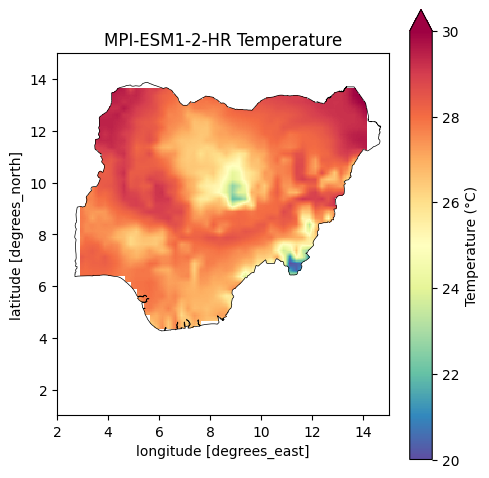

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Select date and convert Kelvin → Celsius
time_0 = (
    ds_mask_MPI_historical['tas']
    .sel(time="1985-07-02", method="nearest")
    - 273.15
)

# Ensure CRS on raster
if not hasattr(time_0.rio, 'crs') or time_0.rio.crs is None:
    time_0.rio.write_crs("EPSG:4326", inplace=True)

# Load Nigeria boundary
shapefile = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"
shp = gpd.read_file(shapefile).to_crs(time_0.rio.crs)

# 🔹 CLIP raster to Nigeria (THIS is the key)
time_0_clip = time_0.rio.clip(
    shp.geometry,
    shp.crs,
    drop=True
)

# Plot clipped raster
time_0_clip.plot(
    vmin=20,
    vmax=30,
    ax=ax,
    cmap='Spectral_r',
    cbar_kwargs={"label": "Temperature (°C)"}
)

# Plot boundary on top
shp.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
ax.set_xlim(2,15)
ax.set_ylim(1,15)

plt.title("MPI-ESM1-2-HR Temperature")
plt.tight_layout()
plt.show()


In [13]:
ds_mask_MPI_historical

<xarray.Dataset>
Dimensions:      (time: 30, bnds: 2, latitude: 188, longitude: 229)
Coordinates:
  * time         (time) datetime64[ns] 1985-07-02T12:00:00 ... 2014-07-02T12:...
  * longitude    (longitude) float32 2.775 2.825 2.875 ... 14.07 14.12 14.17
  * latitude     (latitude) float32 4.325 4.375 4.425 ... 13.57 13.62 13.67
    spatial_ref  int64 0
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (time, bnds, latitude, longitude) datetime64[ns] NaT ... NaT
    tas          (time, latitude, longitude) float32 nan nan nan ... nan nan nan
Attributes: (12/24)
    CDI:                   Climate Data Interface version 2.4.0 (https://mpim...
    Conventions:           CF-1.7
    source:                BCSD
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    history:               Mon Dec 22 16:06:18 2025: cdo yearmean tas_day_MPI...
    activity:              NEX-GDDP-CMIP6
    ...                    ...
    disclaimer:            This data is considered provisional and subject to...
    external_variables:    areacella
    cmip6_source_id:       MPI-ESM1-2-HR
    cmip6_institution_id:  MPI-M
    cmip6_license:         CC-BY-SA 4.0
    CDO:                   Climate Data Operators version 2.4.0 (https://mpim...

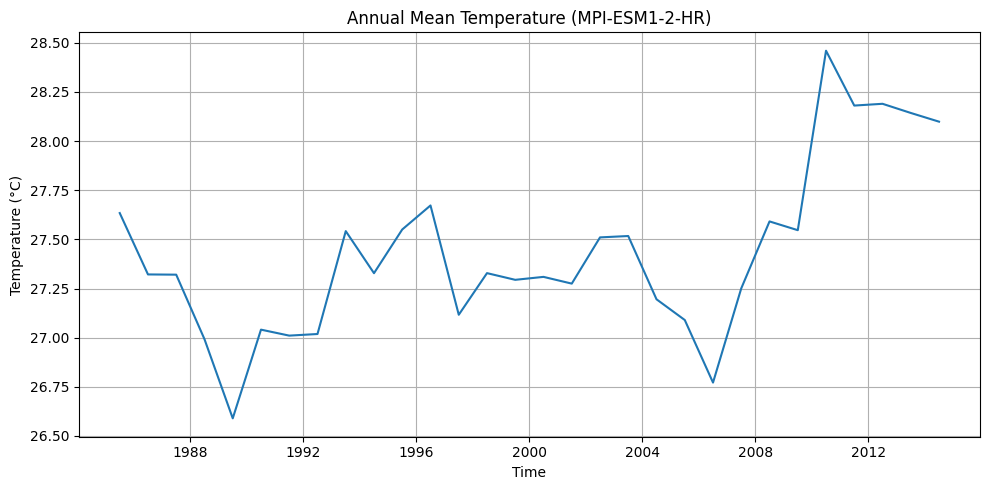

In [14]:
import matplotlib.pyplot as plt

# Compute Nigeria mean temperature
Nigeria_mean = (
    ds_mask_MPI_historical
    .mean(dim=['longitude', 'latitude'])
    .to_dataframe()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(Nigeria_mean['time'], Nigeria_mean['tas'] - 273.15)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Annual Mean Temperature (MPI-ESM1-2-HR)")
plt.grid(True)
plt.tight_layout()

# 🔹 SAVE FIGURE
plt.savefig(
    "/media/precious/Tpresh/CCI_2025/Nigeria_Mean_Temperature_MPI_ESM1_2_HR.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


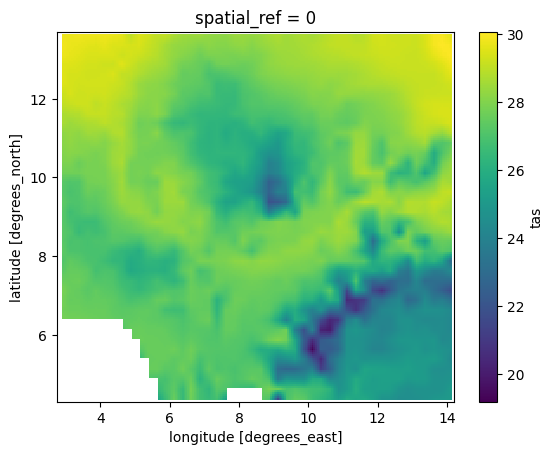

In [15]:
time_2014 = (ds_MPI_ESM1_2_HR_historical['tas'] - 273.15).sel(time = slice ("1985-07-02","2014-07-02"))
time_mean = time_2014.mean(dim = 'time')
time_mean.plot()

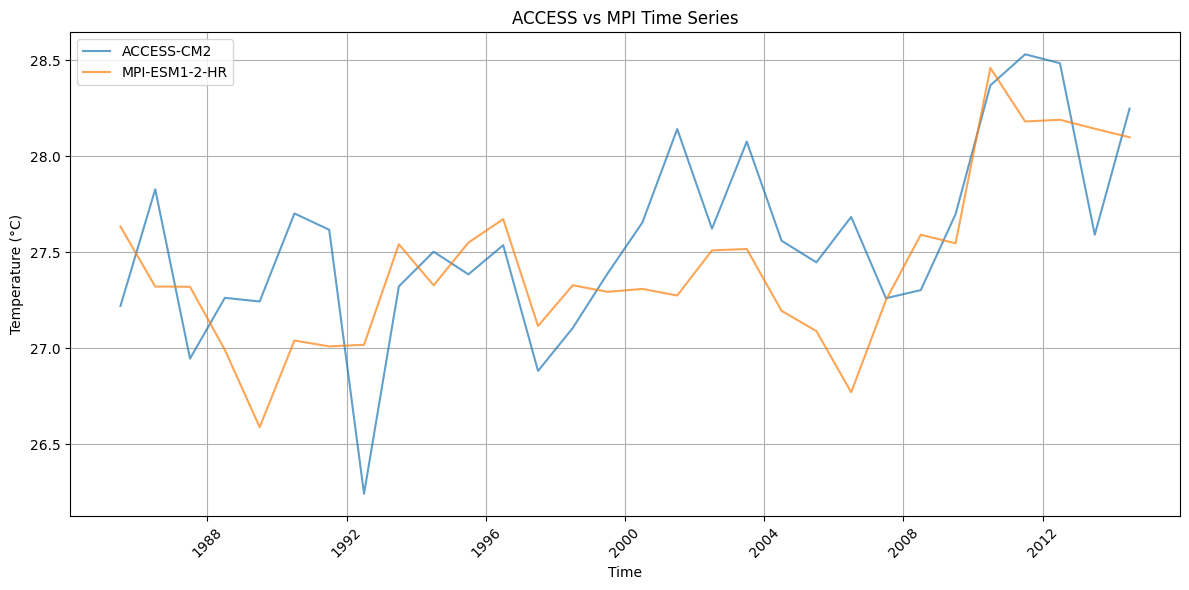

In [16]:
import matplotlib.pyplot as plt

# Compute Nigeria mean for ACCESS-CM2
Nigeria_mean_ACCESS = (
    ds_mask_ACCESS_historical
    .mean(dim=['longitude','latitude'])
    .to_dataframe()
    .reset_index()
)

# Compute Nigeria mean for MPI-ESM1-2-HR
Nigeria_mean_MPI = (
    ds_mask_MPI_historical
    .mean(dim=['longitude','latitude'])
    .to_dataframe()
    .reset_index()
)

# Plot time series
plt.figure(figsize=(12, 6))
plt.plot(Nigeria_mean_ACCESS['time'], Nigeria_mean_ACCESS['tas'] - 273.15, label="ACCESS-CM2", alpha=0.7)
plt.plot(Nigeria_mean_MPI['time'], Nigeria_mean_MPI['tas'] - 273.15, label="MPI-ESM1-2-HR", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("ACCESS vs MPI Time Series")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# 🔹 SAVE FIGURE
plt.savefig(
    "/media/precious/Tpresh/CCI_2025/Nigeria_Mean_Temperature_ACCESS_vs_MPI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


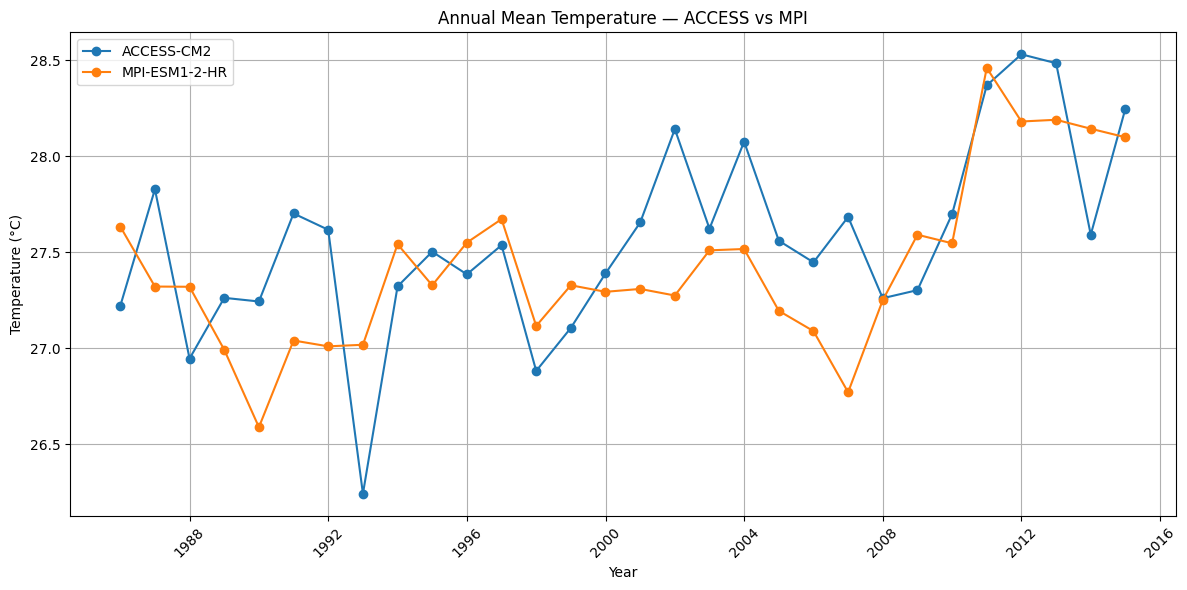

In [17]:
import matplotlib.pyplot as plt

# Compute Nigeria mean for ACCESS and resample to annual mean
Historical_mean_ACCESS_annual = (
    ds_mask_ACCESS_historical['tas']
    .mean(dim=['longitude','latitude'])
    .resample(time="Y")  # 'Y' = yearly
    .mean()
    - 273.15             # Convert to °C
)

# Compute Nigeria mean for MPI and resample to annual mean
Historical_mean_MPI_annual = (
    ds_mask_MPI_historical['tas']
    .mean(dim=['longitude','latitude'])
    .resample(time="Y")
    .mean()
    - 273.15
)

# Plot annual mean time series
plt.figure(figsize=(12, 6))
plt.plot(Historical_mean_ACCESS_annual['time'], Historical_mean_ACCESS_annual, label="ACCESS-CM2", marker='o')
plt.plot(Historical_mean_MPI_annual['time'], Historical_mean_MPI_annual, label="MPI-ESM1-2-HR", marker='o')
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Annual Mean Temperature — ACCESS vs MPI")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save figure
plt.savefig("/media/precious/Tpresh/CCI_2025/Historical_Annual_Mean_Temperature_ACCESS_vs_MPI.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
def annual_mean(da):
    """
    Compute annual mean from a DataArray and drop all-NaN lat/lon points.
    """
    # 1️⃣ Resample to annual mean
    da_annual = da.resample(time='Y').mean(dim='time', skipna=True)

    # 2️⃣ Add 'year' coordinate
    da_annual = da_annual.assign_coords(year=da_annual['time'].dt.year)

    # 3️⃣ Swap 'time' for 'year'
    da_annual = da_annual.swap_dims({'time': 'year'}).drop('time')

    # 4️⃣ Drop all-NaN rows/columns
    da_annual = da_annual.dropna(dim='latitude', how='all') \
                         .dropna(dim='longitude', how='all')

    return da_annual


In [19]:
#annual
ds_ACCESS_C_annual = annual_mean(ds_ACCESS_CM2_historical['tas'])
ds_ACCESS_C_annual 
ds_MPI_C_annual = annual_mean(ds_MPI_ESM1_2_HR_historical['tas'])
ds_MPI_C_annual

<xarray.DataArray 'tas' (year: 30, latitude: 186, longitude: 225)>
array([[[      nan,       nan,       nan, ..., 298.48224, 298.49872,
         298.5152 ],
        [      nan,       nan,       nan, ..., 298.45587, 298.48526,
         298.51462],
        [      nan,       nan,       nan, ..., 298.42953, 298.47177,
         298.51404],
        ...,
        [302.9379 , 302.91913, 302.90036, ..., 302.94504, 302.88257,
         302.82013],
        [302.91953, 302.90387, 302.8882 , ..., 302.8806 , 302.80573,
         302.73083],
        [302.90112, 302.8886 , 302.87607, ..., 302.8162 , 302.72888,
         302.64154]],

       [[      nan,       nan,       nan, ..., 298.44507, 298.4634 ,
         298.48172],
        [      nan,       nan,       nan, ..., 298.41852, 298.4496 ,
         298.48065],
        [      nan,       nan,       nan, ..., 298.392  , 298.4358 ,
         298.47958],
...
        [303.04498, 303.04352, 303.04205, ..., 303.08328, 303.0169 ,
         302.95053],
        [303.02936, 303.03125, 303.03314, ..., 303.01767, 302.9391 ,
         302.8605 ],
        [303.01373, 303.01898, 303.02426, ..., 302.9521 , 302.86127,
         302.77048]],

       [[      nan,       nan,       nan, ..., 298.27667, 298.29095,
         298.3052 ],
        [      nan,       nan,       nan, ..., 298.26733, 298.29456,
         298.3218 ],
        [      nan,       nan,       nan, ..., 298.258  , 298.2982 ,
         298.3384 ],
        ...,
        [303.74426, 303.73456, 303.72482, ..., 303.97253, 303.91058,
         303.84863],
        [303.73575, 303.7291 , 303.72247, ..., 303.92126, 303.84723,
         303.77325],
        [303.72723, 303.72366, 303.72012, ..., 303.86996, 303.7839 ,
         303.69785]]], dtype=float32)
Coordinates:
  * longitude    (longitude) float32 2.925 2.975 3.025 ... 14.02 14.07 14.12
  * latitude     (latitude) float32 4.375 4.425 4.475 ... 13.52 13.57 13.62
    spatial_ref  int64 0
  * year         (year) int64 1985 1986 1987 1988 1989 ... 2011 2012 2013 2014
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Near-Surface Air Temperature
    units:          K
    cell_methods:   area: mean time: maximum
    cell_measures:  area: areacella
    comment:        near-surface (usually, 2 meter) air temperature; derived ...

In [240]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import rioxarray

def plot_models_NIgeria(
    model1,
    model2=None,
    reference=None,
    model1_name="Model 1",
    model2_name="Model 2",
    ref_name="Reference",
    units="°C",
    cmap_main="Spectral_r",
    cmap_diff="bwr",
    shapefile_path=None
):
    """
    Plot one or two models (DataArray or Dataset), optionally with bias against a reference.
    Masked and clipped to Nigeria using shapefile.
    """
    # Load shapefile
    if shapefile_path is None:
        shapefile_path = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"
    shp = gpd.read_file(shapefile_path)
    
    datasets = [model1, model2]
    names = [model1_name, model2_name]
    datasets, names = zip(*[(d, n) for d, n in zip(datasets, names) if d is not None])
    
    ncols = len(datasets)
    nrows = 2 if reference is not None else 1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    
    # Ensure axes is 2D array
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])
    
    # Row 1: models
    for i, da in enumerate(datasets):
        if hasattr(da, "data_vars"):
            da = da['tas']
        
        # Mask & crop to Nigeria
        da = mask_df_optimized(da)
        
        # Convert from Kelvin to Celsius if needed
        if da.max() > 200:  # Assume it's in Kelvin if max > 200
            da = da - 273.15
        
        # Take first year slice
        time_0 = da.isel(year=0) if 'year' in da.dims else da.isel(time=0)
        
        # Ensure CRS
        if not hasattr(time_0.rio, 'crs') or time_0.rio.crs is None:
            time_0.rio.write_crs("EPSG:4326", inplace=True)
        
        # Clip data to Nigeria
        time_0_clip = time_0.rio.clip(shp.geometry, shp.crs, drop=True)
        
        # Plot clipped raster
        im = time_0_clip.plot(ax=axes[0, i], cmap=cmap_main,cbar_kwargs={"label": units})
        
        # Overlay boundary
        shp.boundary.plot(ax=axes[0, i], edgecolor='black', linewidth=0.5)
        axes[0, i].set_title(names[i])
        
        # Set axis limits
        axes[0, i].set_xlim(2, 15)
        axes[0, i].set_ylim(1, 15)
    
    # Row 2: bias
    if reference is not None:
        if hasattr(reference, "data_vars"):
            reference = reference['tas']
        reference = mask_df_optimized(reference)
        
        # Convert reference to Celsius if needed
        if reference.max() > 200:
            reference = reference - 273.15
        
        for i, da in enumerate(datasets):
            if hasattr(da, "data_vars"):
                da = da['tas']
            
            # Convert to Celsius if needed
            if da.max() > 200:
                da = da - 273.15
            
            da_data = da.isel(year=0) if 'year' in da.dims else da.isel(time=0)
            ref_data = reference.isel(year=0) if 'year' in reference.dims else reference.isel(time=0)
            
            # Clip both to Nigeria
            da_clip = da_data.rio.clip(shp.geometry, shp.crs, drop=True)
            ref_clip = ref_data.rio.clip(shp.geometry, shp.crs, drop=True)
            
            bias = da_clip - ref_clip
            vmax = np.nanmax(np.abs(bias.values))
            vmin = -vmax
            
            im = bias.plot(ax=axes[1, i], cmap=cmap_diff, vmin=vmin, vmax=vmax,
                           cbar_kwargs={"label": f"Bias ({units})"})
            shp.boundary.plot(ax=axes[1, i], edgecolor='black', linewidth=0.5)
            axes[1, i].set_title(f"{names[i]} − {ref_name}")
            
            # Set axis limits
            axes[1, i].set_xlim(2, 15)
            axes[1, i].set_ylim(3, 15)
    
    plt.suptitle("Historical Model Comparison (1985-2014)", 
                 fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    # Save figure
    plt.savefig("/media/precious/Tpresh/CCI_2025/historical.png",
                dpi=300, bbox_inches="tight")
    plt.show()

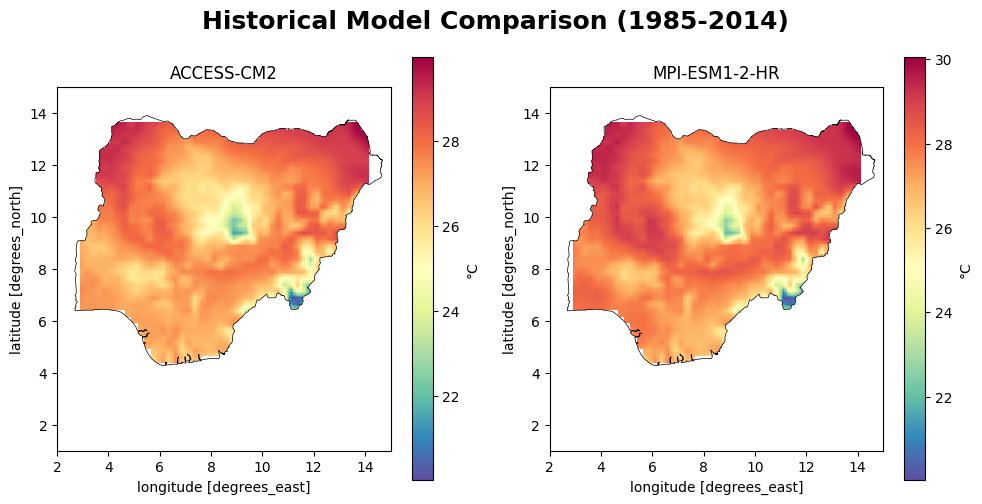

In [241]:
#plot two
plot_models_NIgeria(model1=ds_ACCESS_C_annual,
                  model2=ds_MPI_C_annual,
                  model1_name="ACCESS-CM2",
                  model2_name="MPI-ESM1-2-HR",
                  units="°C")
     


In [22]:
file = "/media/precious/Tpresh/Nigeria/newfile/era5_temp_nigeria_1985_2014_regrid.nc"
ds_era5 = xr.open_dataset(file)
ds_era5

<xarray.Dataset>
Dimensions:          (valid_time: 30, bnds: 2, longitude: 229, latitude: 188)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 1985-06-16 ... 2014-06-16
  * longitude        (longitude) float32 2.775 2.825 2.875 ... 14.07 14.12 14.17
  * latitude         (latitude) float32 4.325 4.375 4.425 ... 13.57 13.62 13.67
Dimensions without coordinates: bnds
Data variables:
    valid_time_bnds  (valid_time, bnds) datetime64[ns] ...
    t2m              (valid_time, latitude, longitude) float32 ...
Attributes:
    CDI:                     Climate Data Interface version 2.4.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Mon Dec 22 19:47:11 2025: cdo remapbil,annual_ta...
    frequency:               year
    CDO:                     Climate Data Operators version 2.4.0 (https://mp...

In [23]:
ds_mask_era5 = mask_df_optimized(ds_era5)
ds_mask_era5

<xarray.Dataset>
Dimensions:          (valid_time: 30, bnds: 2, latitude: 188, longitude: 229)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 1985-06-16 ... 2014-06-16
  * longitude        (longitude) float32 2.775 2.825 2.875 ... 14.07 14.12 14.17
  * latitude         (latitude) float32 4.325 4.375 4.425 ... 13.57 13.62 13.67
    spatial_ref      int64 0
Dimensions without coordinates: bnds
Data variables:
    valid_time_bnds  (valid_time, bnds, latitude, longitude) datetime64[ns] N...
    t2m              (valid_time, latitude, longitude) float32 nan nan ... nan
Attributes:
    CDI:                     Climate Data Interface version 2.4.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Mon Dec 22 19:47:11 2025: cdo remapbil,annual_ta...
    frequency:               year
    CDO:                     Climate Data Operators version 2.4.0 (https://mp...

In [40]:
# Check dimensions of your datasets
print("ERA5 dimensions:", ds_mask_era5.dims)
print("ERA5 shape:", ds_mask_era5['t2m'].shape if 't2m' in ds_mask_era5 else "No t2m variable")
print("\nACCESS dimensions:", ds_ACCESS_C_annual_celsius.dims)
print("ACCESS shape:", ds_ACCESS_C_annual_celsius['tas'].shape if 'tas' in ds_ACCESS_C_annual_celsius else "No tas variable")
print("\nMPI dimensions:", ds_MPI_C_annual_celsius.dims)
print("MPI shape:", ds_MPI_C_annual_celsius['tas'].shape if 'tas' in ds_MPI_C_annual_celsius else "No tas variable")

# Also check what happens after processing
if hasattr(ds_mask_era5, "data_vars"):
    ref_var = ds_mask_era5['t2m'] if 't2m' in ds_mask_era5.data_vars else ds_mask_era5['tas']
else:
    ref_var = ds_mask_era5

print("\nRef var dimensions:", ref_var.dims)
print("Ref var shape:", ref_var.shape)

# Check after mean
if 'time' in ref_var.dims:
    ref_test = ref_var.mean(dim='time').squeeze()
    print("\nAfter mean and squeeze:")
    print("Dimensions:", ref_test.dims)
    print("Shape:", ref_test.shape)
    print("Number of dimensions:", ref_test.ndim)

ERA5 dimensions: Frozen({'valid_time': 30, 'bnds': 2, 'latitude': 188, 'longitude': 229})
ERA5 shape: (30, 188, 229)

ACCESS dimensions: ('time', 'latitude', 'longitude')
ACCESS shape: No tas variable

MPI dimensions: ('time', 'latitude', 'longitude')
MPI shape: No tas variable

Ref var dimensions: ('valid_time', 'latitude', 'longitude')
Ref var shape: (30, 188, 229)


In [43]:
print("ACCESS type:", type(ds_ACCESS_C_annual_celsius))
print("MPI type:", type(ds_MPI_C_annual_celsius))

# If they're DataArrays, check their name
if hasattr(ds_ACCESS_C_annual_celsius, 'name'):
    print("ACCESS name:", ds_ACCESS_C_annual_celsius.name)
if hasattr(ds_MPI_C_annual_celsius, 'name'):
    print("MPI name:", ds_MPI_C_annual_celsius.name)

ACCESS type: <class 'xarray.core.dataarray.DataArray'>
MPI type: <class 'xarray.core.dataarray.DataArray'>
ACCESS name: tas
MPI name: tas


In [24]:
# If still in Kelvin:
ds_ACCESS_C_annual_celsius = ds_ACCESS_C_annual - 273.15
ds_MPI_C_annual_celsius    = ds_MPI_C_annual - 273.15
# ERA5 is likely already in Celsius


In [25]:
ds_ACCESS_C_annual_celsius = ds_ACCESS_C_annual_celsius.rename({'year': 'time'})
ds_MPI_C_annual_celsius    = ds_MPI_C_annual_celsius.rename({'year': 'time'})


In [55]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import rioxarray

def plot_models_Nigeria(
    model1,
    model2=None,
    reference=None,
    model1_name="Model 1",
    model2_name="Model 2",
    ref_name="Reference",
    units="°C",
    cmap_main="Spectral_r",
    cmap_diff="RdBu_r",
    shapefile_path=None
):
    """
    Plot two models with reference in a 2x3 grid:
    Row 1: ERA5 | ACCESS | BIAS (ACCESS - ERA5)
    Row 2: ERA5 | MPI | BIAS (MPI - ERA5)
    
    All temperature maps use the same color scale calculated from ERA5, ACCESS, and MPI.
    """
    # Load shapefile from geoBoundaries
    if shapefile_path is None:
        shapefile_path = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"
    
    shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    
    # Create 2x3 subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    
    # ========== PROCESS REFERENCE DATA ==========
    if hasattr(reference, "data_vars"):
        if 't2m' in reference.data_vars:
            ref_var = reference['t2m']
        elif 'tas' in reference.data_vars:
            ref_var = reference['tas']
        else:
            ref_var = reference[list(reference.data_vars)[0]]
    else:
        ref_var = reference
    
    # Get temporal mean of reference
    if 'year' in ref_var.dims:
        ref_data = ref_var.mean(dim='year').squeeze()
    elif 'time' in ref_var.dims:
        ref_data = ref_var.mean(dim='time').squeeze()
    elif 'valid_time' in ref_var.dims:
        ref_data = ref_var.mean(dim='valid_time').squeeze()
    else:
        ref_data = ref_var.squeeze()
    
    # Ensure reference has CRS and clip to Nigeria
    if not hasattr(ref_data.rio, 'crs') or ref_data.rio.crs is None:
        ref_data.rio.write_crs("EPSG:4326", inplace=True)
    
    ref_clip = ref_data.rio.clip(shp.geometry, shp.crs, drop=True, all_touched=True)
    
    # ========== PROCESS MODEL 1 (ACCESS) ==========
    da1 = model1
    if hasattr(da1, "data_vars"):
        if 'tas' in da1.data_vars:
            da1 = da1['tas']
        elif 't2m' in da1.data_vars:
            da1 = da1['t2m']
        else:
            da1 = da1[list(da1.data_vars)[0]]
    
    da1 = mask_df_optimized(da1)
    
    if 'year' in da1.dims:
        da1_mean = da1.mean(dim='year').squeeze()
    elif 'time' in da1.dims:
        da1_mean = da1.mean(dim='time').squeeze()
    elif 'valid_time' in da1.dims:
        da1_mean = da1.mean(dim='valid_time').squeeze()
    else:
        da1_mean = da1.squeeze()
    
    if not hasattr(da1_mean.rio, 'crs') or da1_mean.rio.crs is None:
        da1_mean.rio.write_crs("EPSG:4326", inplace=True)
    
    da1_clip = da1_mean.rio.clip(shp.geometry, shp.crs, drop=True, all_touched=True)
    
    # ========== PROCESS MODEL 2 (MPI) if provided ==========
    if model2 is not None:
        da2 = model2
        if hasattr(da2, "data_vars"):
            if 'tas' in da2.data_vars:
                da2 = da2['tas']
            elif 't2m' in da2.data_vars:
                da2 = da2['t2m']
            else:
                da2 = da2[list(da2.data_vars)[0]]
        
        da2 = mask_df_optimized(da2)
        
        if 'year' in da2.dims:
            da2_mean = da2.mean(dim='year').squeeze()
        elif 'time' in da2.dims:
            da2_mean = da2.mean(dim='time').squeeze()
        elif 'valid_time' in da2.dims:
            da2_mean = da2.mean(dim='valid_time').squeeze()
        else:
            da2_mean = da2.squeeze()
        
        if not hasattr(da2_mean.rio, 'crs') or da2_mean.rio.crs is None:
            da2_mean.rio.write_crs("EPSG:4326", inplace=True)
        
        da2_clip = da2_mean.rio.clip(shp.geometry, shp.crs, drop=True, all_touched=True)
        
        # Calculate GLOBAL min/max across all three datasets
        all_data = [ref_clip.values, da1_clip.values, da2_clip.values]
        global_vmin = float(np.nanmin([np.nanmin(d) for d in all_data]))
        global_vmax = float(np.nanmax([np.nanmax(d) for d in all_data]))
    else:
        # Only ERA5 and model1
        all_data = [ref_clip.values, da1_clip.values]
        global_vmin = float(np.nanmin([np.nanmin(d) for d in all_data]))
        global_vmax = float(np.nanmax([np.nanmax(d) for d in all_data]))
    
    print(f"Unified color scale: {global_vmin:.2f}°C to {global_vmax:.2f}°C")
    
    # ============= ROW 1: ACCESS =============
    
    # Column 0: ERA5 (Reference)
    ax = axes[0, 0]
    im = ref_clip.plot.pcolormesh(
        ax=ax, 
        cmap=cmap_main,
        vmin=global_vmin,
        vmax=global_vmax,
        add_colorbar=True,
        cbar_kwargs={"label": units, "shrink": 0.8}
    )
    shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
    ax.set_facecolor('white')
    ax.set_title(ref_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=10)
    ax.set_ylabel('Latitude (°N)', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(2, 15)
    ax.set_ylim(3, 15)
    
    # Column 1: ACCESS
    ax = axes[0, 1]
    im = da1_clip.plot.pcolormesh(
        ax=ax, 
        cmap=cmap_main,
        vmin=global_vmin,
        vmax=global_vmax,
        add_colorbar=True,
        cbar_kwargs={"label": units, "shrink": 0.8}
    )
    shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
    ax.set_facecolor('white')
    ax.set_title(model1_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=10)
    ax.set_ylabel('', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(2, 15)
    ax.set_ylim(3, 15)
        
    # Column 2: BIAS (ACCESS - ERA5)
    ax = axes[0, 2]
    bias1 = da1_clip - ref_clip
    vmax_bias1 = float(np.nanmax(np.abs(bias1.values)))
    vmin_bias1 = -vmax_bias1
    
    im = bias1.plot.pcolormesh(
        ax=ax, 
        cmap=cmap_diff, 
        vmin=vmin_bias1, 
        vmax=vmax_bias1,
        add_colorbar=True,
        cbar_kwargs={"label": f"Bias ({units})", "shrink": 0.8}
    )
    shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
    ax.set_facecolor('white')
    ax.set_title(f"{model1_name} − {ref_name}", fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=10)
    ax.set_ylabel('', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(2, 15)
    ax.set_ylim(3, 15)
    
    mean_bias1 = float(bias1.mean().values)
    ax.text(0.02, 0.98, f'Mean: {mean_bias1:.2f}°C',
           transform=ax.transAxes,
           fontsize=9,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    # ============= ROW 2: MPI =============
    
    if model2 is not None:
        # Column 0: ERA5 (Reference)
        ax = axes[1, 0]
        im = ref_clip.plot.pcolormesh(
            ax=ax, 
            cmap=cmap_main,
            vmin=global_vmin,
            vmax=global_vmax,
            add_colorbar=True,
            cbar_kwargs={"label": units, "shrink": 0.8}
        )
        shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
        ax.set_facecolor('white')
        ax.set_title(ref_name, fontsize=13, fontweight='bold')
        ax.set_xlabel('Longitude (°E)', fontsize=10)
        ax.set_ylabel('Latitude (°N)', fontsize=10)
        ax.tick_params(labelsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(2, 15)
        ax.set_ylim(3, 15)
        
        # Column 1: MPI
        ax = axes[1, 1]
        im = da2_clip.plot.pcolormesh(
            ax=ax, 
            cmap=cmap_main,
            vmin=global_vmin,
            vmax=global_vmax,
            add_colorbar=True,
            cbar_kwargs={"label": units, "shrink": 0.8}
        )
        shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
        ax.set_facecolor('white')
        ax.set_title(model2_name, fontsize=13, fontweight='bold')
        ax.set_xlabel('Longitude (°E)', fontsize=10)
        ax.set_ylabel('', fontsize=10)
        ax.tick_params(labelsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(2, 15)
        ax.set_ylim(3, 15)
        
        # Column 2: BIAS (MPI - ERA5)
        ax = axes[1, 2]
        bias2 = da2_clip - ref_clip
        vmax_bias2 = float(np.nanmax(np.abs(bias2.values)))
        vmin_bias2 = -vmax_bias2
        
        im = bias2.plot.pcolormesh(
            ax=ax, 
            cmap=cmap_diff, 
            vmin=vmin_bias2, 
            vmax=vmax_bias2,
            add_colorbar=True,
            cbar_kwargs={"label": f"Bias ({units})", "shrink": 0.8}
        )
        shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
        ax.set_facecolor('white')
        ax.set_title(f"{model2_name} − {ref_name}", fontsize=13, fontweight='bold')
        ax.set_xlabel('Longitude (°E)', fontsize=10)
        ax.set_ylabel('', fontsize=10)
        ax.tick_params(labelsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(2, 15)
        ax.set_ylim(3, 15)
        
        mean_bias2 = float(bias2.mean().values)
        ax.text(0.02, 0.98, f'Mean: {mean_bias2:.2f}°C',
               transform=ax.transAxes,
               fontsize=9,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    plt.suptitle("Model Evaluation over Nigeria (1985-2014)", 
                 fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    # Save figure
    plt.savefig("/media/precious/Tpresh/CCI_2025/Model_Annual_Mean_Temperature_ACCESS_vs_MPI.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    
    return fig, axes

Unified color scale: 19.77°C to 30.21°C


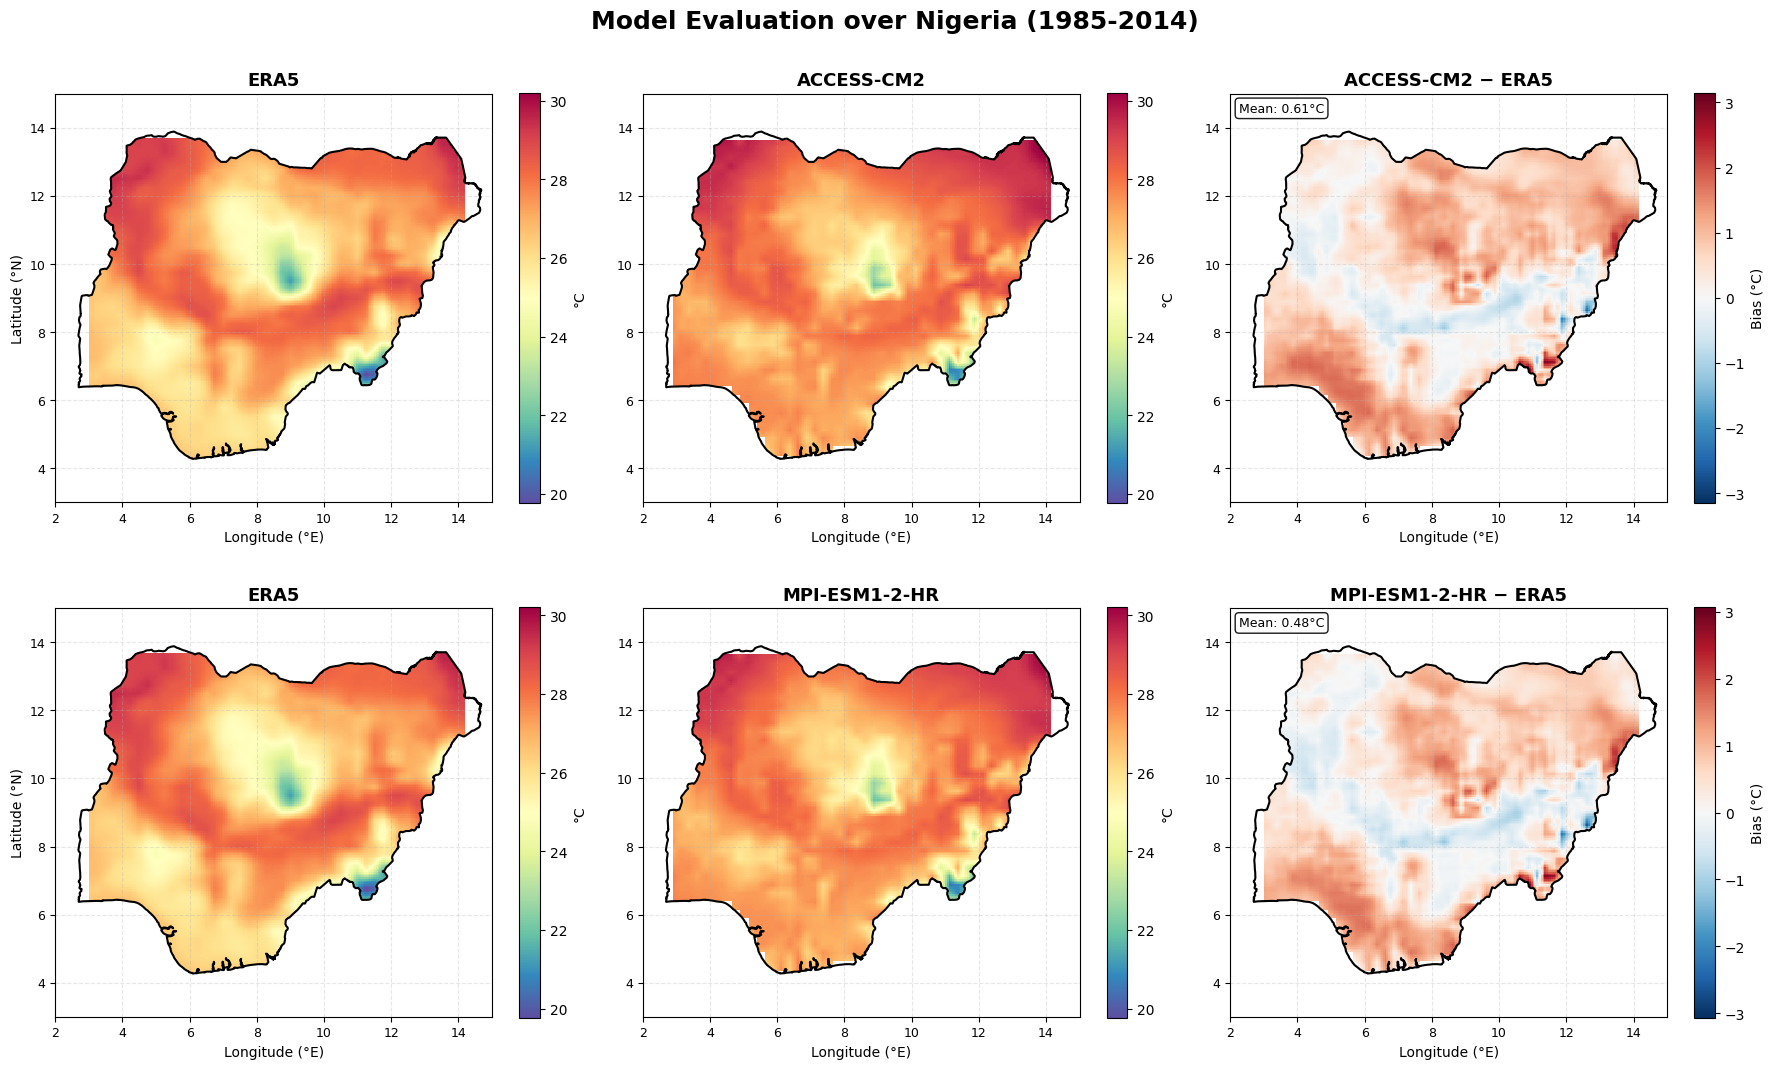

In [56]:
fig, axes = plot_models_Nigeria(
    model1=ds_ACCESS_C_annual_celsius,
    model2=ds_MPI_C_annual_celsius,
    reference=ds_mask_era5,
    model1_name="ACCESS-CM2",
    model2_name="MPI-ESM1-2-HR",
    ref_name="ERA5",
    units="°C"
)

In [57]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_ACCESS-CM2_ssp126_rpf_gn_2071_2100_Nigeria_regrid.nc"
ds_ACCESS_ssp126_ff = xr.open_dataset(file)
ds_ACCESS_ssp126_ff = ds_ACCESS_ssp126_ff['tas'] - 273.15
ds_ACCESS_ssp126_ff

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 28.115845, 28.134918,
               nan],
        [      nan,       nan,       nan, ..., 28.111664, 28.143402,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 32.92621 , 32.85089 ,
               nan],
        [      nan,       nan,       nan, ..., 32.861267, 32.77359 ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.940582, 26.963135,
               nan],
        [      nan,       nan,       nan, ..., 26.926147, 26.961243,
               nan],
...
        [      nan,       nan,       nan, ..., 31.812317, 31.737946,
               nan],
        [      nan,       nan,       nan, ..., 31.739807, 31.652985,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 27.421783, 27.439117,
               nan],
        [      nan,       nan,       nan, ..., 27.418457, 27.448517,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.960144, 31.885162,
               nan],
        [      nan,       nan,       nan, ..., 31.894897, 31.807434,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2071-07-02T12:00:00 ... 2100-07-02T12:00:00
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [58]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_ACCESS-CM2_ssp126_rpf_gn_2031_2600_Nigeria_regrid.nc"
ds_ACCESS_ssp126_nf = xr.open_dataset(file)
ds_ACCESS_ssp126_nf = ds_ACCESS_ssp126_nf['tas'] - 273.15
ds_ACCESS_ssp126_nf

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.90982 , 26.926361,
               nan],
        [      nan,       nan,       nan, ..., 26.912933, 26.942139,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.38498 , 31.31076 ,
               nan],
        [      nan,       nan,       nan, ..., 31.320099, 31.23346 ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.621399, 26.635986,
               nan],
        [      nan,       nan,       nan, ..., 26.617126, 26.644592,
               nan],
...
        [      nan,       nan,       nan, ..., 32.727966, 32.655792,
               nan],
        [      nan,       nan,       nan, ..., 32.665924, 32.581543,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 27.50943 , 27.526459,
               nan],
        [      nan,       nan,       nan, ..., 27.51059 , 27.540375,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 32.559845, 32.485443,
               nan],
        [      nan,       nan,       nan, ..., 32.501404, 32.414734,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2031-07-02T12:00:00 ... 2060-07-02
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [59]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_ACCESS-CM2_ssp245_rpf_gn_2031_2060_Nigeria_regrid.nc"
ds_ACCESS_ssp245_nf = xr.open_dataset(file)
ds_ACCESS_ssp245_nf = ds_ACCESS_ssp245_nf['tas'] - 273.15
ds_ACCESS_ssp245_nf

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.877625, 26.893677,
               nan],
        [      nan,       nan,       nan, ..., 26.873352, 26.902191,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.215332, 31.141602,
               nan],
        [      nan,       nan,       nan, ..., 31.140991, 31.054749,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.223541, 26.237274,
               nan],
        [      nan,       nan,       nan, ..., 26.215027, 26.241577,
               nan],
...
        [      nan,       nan,       nan, ..., 33.5802  , 33.503326,
               nan],
        [      nan,       nan,       nan, ..., 33.513763, 33.42444 ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 27.26233 , 27.276947,
               nan],
        [      nan,       nan,       nan, ..., 27.251984, 27.279388,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 32.000122, 31.925507,
               nan],
        [      nan,       nan,       nan, ..., 31.94345 , 31.856384,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2031-07-02T12:00:00 ... 2060-07-02
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [60]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_ACCESS-CM2_ssp245_rpf_gn_2071_2100_Nigeria_regrid.nc"
ds_ACCESS_ssp245_ff = xr.open_dataset(file)
ds_ACCESS_ssp245_ff = ds_ACCESS_ssp245_ff['tas'] - 273.15
ds_ACCESS_ssp245_ff

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 28.553986, 28.570099,
               nan],
        [      nan,       nan,       nan, ..., 28.557098, 28.58603 ,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 34.036926, 33.961853,
               nan],
        [      nan,       nan,       nan, ..., 33.98401 , 33.896667,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 28.352692, 28.368591,
               nan],
        [      nan,       nan,       nan, ..., 28.357056, 28.38565 ,
               nan],
...
        [      nan,       nan,       nan, ..., 34.529633, 34.456604,
               nan],
        [      nan,       nan,       nan, ..., 34.47455 , 34.389282,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 29.001373, 29.01773 ,
               nan],
        [      nan,       nan,       nan, ..., 29.003143, 29.032288,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 34.13562 , 34.059845,
               nan],
        [      nan,       nan,       nan, ..., 34.078186, 33.990143,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2071-07-02T12:00:00 ... 2100-07-02T12:00:00
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [61]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_ACCESS-CM2_ssp585_rpf_gn_2071_2100_Nigeria_regrid.nc"
ds_ACCESS_ssp585_ff = xr.open_dataset(file)
ds_ACCESS_ssp585_ff = ds_ACCESS_ssp585_ff['tas'] - 273.15
ds_ACCESS_ssp585_ff

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 30.384369, 30.399048,
               nan],
        [      nan,       nan,       nan, ..., 30.384277, 30.41156 ,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 36.149323, 36.073425,
               nan],
        [      nan,       nan,       nan, ..., 36.096405, 36.008026,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 29.65744 , 29.67395 ,
               nan],
        [      nan,       nan,       nan, ..., 29.654327, 29.683594,
               nan],
...
        [      nan,       nan,       nan, ..., 38.271545, 38.194824,
               nan],
        [      nan,       nan,       nan, ..., 38.227722, 38.13864 ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 33.15497 , 33.169495,
               nan],
        [      nan,       nan,       nan, ..., 33.1568  , 33.184113,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 38.607483, 38.53293 ,
               nan],
        [      nan,       nan,       nan, ..., 38.548584, 38.461548,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2071-07-02T12:00:00 ... 2100-07-02T12:00:00
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [62]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_ACCESS-CM2_ssp585_rpf_gn_2031_2060_Nigeria_regrid.nc"
ds_ACCESS_ssp585_nf = xr.open_dataset(file)
ds_ACCESS_ssp585_nf = ds_ACCESS_ssp585_nf['tas'] - 273.15
ds_ACCESS_ssp585_nf

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 27.288727, 27.30835 ,
               nan],
        [      nan,       nan,       nan, ..., 27.297516, 27.329773,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.227966, 31.153534,
               nan],
        [      nan,       nan,       nan, ..., 31.157318, 31.070465,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.34549 , 26.36316 ,
               nan],
        [      nan,       nan,       nan, ..., 26.33667 , 26.367004,
               nan],
...
        [      nan,       nan,       nan, ..., 34.202484, 34.126312,
               nan],
        [      nan,       nan,       nan, ..., 34.13614 , 34.047638,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 28.817993, 28.836823,
               nan],
        [      nan,       nan,       nan, ..., 28.8042  , 28.835693,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 33.570892, 33.494446,
               nan],
        [      nan,       nan,       nan, ..., 33.52591 , 33.437164,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2031-07-02T12:00:00 ... 2060-07-02
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [63]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_MPI-ESM1-2-HR_ssp126_rpf_gn_2031_2060_Nigeria_regrid.nc"
ds_MPI_ssp126_nf = xr.open_dataset(file)
ds_MPI_ssp126_nf = ds_MPI_ssp126_nf['tas'] - 273.15
ds_MPI_ssp126_nf

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.043182, 25.055908,
               nan],
        [      nan,       nan,       nan, ..., 25.03714 , 25.062897,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 29.574646, 29.500519,
               nan],
        [      nan,       nan,       nan, ..., 29.505035, 29.418549,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 24.956787, 24.969635,
               nan],
        [      nan,       nan,       nan, ..., 24.947632, 24.97348 ,
               nan],
...
        [      nan,       nan,       nan, ..., 31.470062, 31.391296,
               nan],
        [      nan,       nan,       nan, ..., 31.40274 , 31.311676,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.636261, 25.652924,
               nan],
        [      nan,       nan,       nan, ..., 25.640594, 25.67041 ,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 30.684967, 30.609955,
               nan],
        [      nan,       nan,       nan, ..., 30.613098, 30.525757,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2031-07-02T12:00:00 ... 2060-07-02
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [64]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_MPI-ESM1-2-HR_ssp126_rpf_gn_2071_2100_Nigeria_regrid.nc"
ds_MPI_ssp126_ff = xr.open_dataset(file)
ds_MPI_ssp126_ff = ds_MPI_ssp126_ff['tas'] - 273.15
ds_MPI_ssp126_ff

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.72287 , 25.74057 ,
               nan],
        [      nan,       nan,       nan, ..., 25.729736, 25.760925,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.553467, 31.478638,
               nan],
        [      nan,       nan,       nan, ..., 31.481506, 31.394226,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.526184, 25.546143,
               nan],
        [      nan,       nan,       nan, ..., 25.526855, 25.56009 ,
               nan],
...
        [      nan,       nan,       nan, ..., 30.275818, 30.200226,
               nan],
        [      nan,       nan,       nan, ..., 30.196533, 30.108429,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.540894, 25.553864,
               nan],
        [      nan,       nan,       nan, ..., 25.556763, 25.582855,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.021637, 30.950317,
               nan],
        [      nan,       nan,       nan, ..., 30.949982, 30.866089,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2071-07-02T12:00:00 ... 2100-07-02T12:00:00
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [65]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_MPI-ESM1-2-HR_ssp245_rpf_gn_2071_2100_Nigeria_regrid.nc"
ds_MPI_ssp245_ff = xr.open_dataset(file)
ds_MPI_ssp245_ff = ds_MPI_ssp245_ff['tas'] - 273.15
ds_MPI_ssp245_ff

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.796173, 26.814972,
               nan],
        [      nan,       nan,       nan, ..., 26.803955, 26.835693,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 32.268646, 32.189606,
               nan],
        [      nan,       nan,       nan, ..., 32.192383, 32.100983,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.251984, 26.264923,
               nan],
        [      nan,       nan,       nan, ..., 26.260834, 26.287079,
               nan],
...
        [      nan,       nan,       nan, ..., 32.13217 , 32.056183,
               nan],
        [      nan,       nan,       nan, ..., 32.05414 , 31.96582 ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.311005, 26.333038,
               nan],
        [      nan,       nan,       nan, ..., 26.308289, 26.343475,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.571167, 31.49472 ,
               nan],
        [      nan,       nan,       nan, ..., 31.501678, 31.412994,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2071-07-02T12:00:00 ... 2100-07-02T12:00:00
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [66]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_MPI-ESM1-2-HR_ssp245_rpf_gn_2031_2060_Nigeria_regrid.nc"
ds_MPI_ssp245_nf = xr.open_dataset(file)
ds_MPI_ssp245_nf = ds_MPI_ssp245_nf['tas'] - 273.15
ds_MPI_ssp245_nf

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 24.830627, 24.845398,
               nan],
        [      nan,       nan,       nan, ..., 24.830109, 24.857605,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 29.820007, 29.73581 ,
               nan],
        [      nan,       nan,       nan, ..., 29.749634, 29.652863,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 24.626587, 24.636627,
               nan],
        [      nan,       nan,       nan, ..., 24.629272, 24.65216 ,
               nan],
...
        [      nan,       nan,       nan, ..., 32.009094, 31.93341 ,
               nan],
        [      nan,       nan,       nan, ..., 31.933624, 31.845184,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.41867 , 25.435394,
               nan],
        [      nan,       nan,       nan, ..., 25.417603, 25.447632,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.217133, 31.137024,
               nan],
        [      nan,       nan,       nan, ..., 31.144989, 31.05249 ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2031-07-02T12:00:00 ... 2060-07-02
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [67]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_MPI-ESM1-2-HR_ssp585_rpf_gn_2031_2060_Nigeria_regrid.nc"
ds_MPI_ssp585_nf = xr.open_dataset(file)
ds_MPI_ssp585_nf = ds_MPI_ssp585_nf['tas'] - 273.15
ds_MPI_ssp585_nf

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.603851, 25.624847,
               nan],
        [      nan,       nan,       nan, ..., 25.615387, 25.649597,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 30.826447, 30.74997 ,
               nan],
        [      nan,       nan,       nan, ..., 30.76587 , 30.677216,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.3078  , 25.3284  ,
               nan],
        [      nan,       nan,       nan, ..., 25.319061, 25.352905,
               nan],
...
        [      nan,       nan,       nan, ..., 31.528534, 31.445343,
               nan],
        [      nan,       nan,       nan, ..., 31.473541, 31.378357,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 25.58966 , 25.610138,
               nan],
        [      nan,       nan,       nan, ..., 25.589294, 25.622986,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.13684 , 31.058746,
               nan],
        [      nan,       nan,       nan, ..., 31.079712, 30.989166,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2031-07-02T12:00:00 ... 2060-07-02
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [68]:
file = "/media/precious/Tpresh/Nigeria/newfile/annual_tas_day_MPI-ESM1-2-HR_ssp585_rpf_gn_2071_2100_Nigeria_regrid.nc"
ds_MPI_ssp585_ff = xr.open_dataset(file)
ds_MPI_ssp585_ff = ds_MPI_ssp585_ff['tas'] - 273.15
ds_MPI_ssp585_ff

<xarray.DataArray 'tas' (time: 30, latitude: 188, longitude: 229)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.219147, 26.240662,
               nan],
        [      nan,       nan,       nan, ..., 26.214783, 26.249298,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 31.654419, 31.57492 ,
               nan],
        [      nan,       nan,       nan, ..., 31.58899 , 31.4971  ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 26.024231, 26.044464,
               nan],
        [      nan,       nan,       nan, ..., 26.02121 , 26.054504,
               nan],
...
        [      nan,       nan,       nan, ..., 34.38623 , 34.305542,
               nan],
        [      nan,       nan,       nan, ..., 34.31134 , 34.21826 ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 27.98761 , 28.0065  ,
               nan],
        [      nan,       nan,       nan, ..., 27.990967, 28.022888,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 33.223114, 33.142273,
               nan],
        [      nan,       nan,       nan, ..., 33.14975 , 33.056488,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2071-07-02T12:00:00 ... 2100-07-02T12:00:00
  * longitude  (longitude) float32 2.775 2.825 2.875 2.925 ... 14.07 14.12 14.17
  * latitude   (latitude) float32 4.325 4.375 4.425 4.475 ... 13.57 13.62 13.67

In [73]:
# ACCESS & MPI (use time)
baseline_access = (
    ds_ACCESS_C_annual_celsius
    .sel(time=slice("1985-01-01", "2014-12-31"))
    .mean(dim="time")
)

baseline_mpi = (
    ds_MPI_C_annual_celsius
    .sel(time=slice("1985-01-01", "2014-12-31"))
    .mean(dim="time")
)

# ERA5 (use valid_time)
baseline_era5 = (
    ds_era5_celsius
    .sel(valid_time=slice("1985-01-01", "2014-12-31"))
    .mean(dim="valid_time")
)


In [75]:
# 1. Rename ERA5 valid_time to time (do this ONCE)
ds_era5_celsius = ds_era5_celsius.rename({"valid_time": "time"})

# 2. Convert ERA5 to annual means
era5_annual = ds_era5_celsius.resample(time="Y").mean()

# 3. Historical baseline (1985–2014)
baseline_era5 = (
    era5_annual
    .sel(time=slice("1985-01-01", "2014-12-31"))
    .mean(dim="time")
)


In [76]:
# ======================
# SSP126
# ======================
ssp126_near_future_access = ds_ACCESS_ssp126_nf - baseline_access
ssp126_far_future_access  = ds_ACCESS_ssp126_ff - baseline_access

ssp126_near_future_MPI = ds_MPI_ssp126_nf - baseline_access
ssp126_far_future_MPI  = ds_MPI_ssp126_ff - baseline_access


# ======================
# SSP245
# ======================
ssp245_near_future_access = ds_ACCESS_ssp245_nf - baseline_access
ssp245_far_future_access  = ds_ACCESS_ssp245_ff - baseline_access

ssp245_near_future_MPI = ds_MPI_ssp245_nf - baseline_access
ssp245_far_future_MPI  = ds_MPI_ssp245_ff - baseline_access


# ======================
# SSP585
# ======================
ssp585_near_future_access = ds_ACCESS_ssp585_nf - baseline_access
ssp585_far_future_access  = ds_ACCESS_ssp585_ff - baseline_access

ssp585_near_future_MPI = ds_MPI_ssp585_nf - baseline_access
ssp585_far_future_MPI  = ds_MPI_ssp585_ff - baseline_access


In [77]:
print("SSP126 ACCESS NF:", float(ssp126_near_future_access.mean()))
print("SSP126 ACCESS FF:", float(ssp126_far_future_access.mean()))

print("SSP245 ACCESS NF:", float(ssp245_near_future_access.mean()))
print("SSP245 ACCESS FF:", float(ssp245_far_future_access.mean()))

print("SSP585 ACCESS NF:", float(ssp585_near_future_access.mean()))
print("SSP585 ACCESS FF:", float(ssp585_far_future_access.mean()))

print("SSP585 MPI NF:", float(ssp585_near_future_MPI.mean()))
print("SSP585 MPI FF:", float(ssp585_far_future_MPI.mean()))


SSP126 ACCESS NF: 1.918241024017334
SSP126 ACCESS FF: 2.2632296085357666
SSP245 ACCESS NF: 1.8884913921356201
SSP245 ACCESS FF: 3.3470518589019775
SSP585 ACCESS NF: 2.2023606300354004
SSP585 ACCESS FF: 5.630973815917969
SSP585 MPI NF: 0.7145005464553833
SSP585 MPI FF: 2.279832363128662


In [78]:
print("Min anomaly:", ssp126_near_future_access.min().values)
print("Max anomaly:", ssp126_near_future_access.max().values)
print("Mean anomaly:", ssp126_near_future_access.mean().values)


Min anomaly: 0.29981613
Max anomaly: 3.8797455
Mean anomaly: 1.918241


In [79]:
print("Future dims:", ds_MPI_ssp585_nf.dims)
print("Baseline dims:", baseline_access.dims)


Future dims: ('time', 'latitude', 'longitude')
Baseline dims: ('latitude', 'longitude')


In [82]:
anomaly_dict = {
    'SSP126': {
        'ACCESS': {
            'Near': ssp126_near_future_access,
            'Far': ssp126_far_future_access
        }
    },
    'SSP245': {
        'ACCESS': {
            'Near': ssp245_near_future_access,
            'Far': ssp245_far_future_access
        }
    },
    'SSP585': {
        'ACCESS': {
            'Near': ssp585_near_future_access,
            'Far': ssp585_far_future_access
        }
    }
}


In [193]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray

def plot_ACCESS_anomalies(
    anomaly_dict,
    shapefile_path,
    model_key='ACCESS',
    vmin=-2,
    vmax=2,
    figsize=(18, 11),
    cmap='RdYlBu_r'
):

    shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

    scenarios = ['SSP126', 'SSP245', 'SSP585']
    periods = ['Near', 'Far']
    period_labels = ['Near Future (2031–2060)', 'Far Future (2071–2100)']

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.subplots_adjust(
        hspace=0.35, wspace=0.35,
        left=0.08, right=0.95,
        top=0.93, bottom=0.08
    )

    for i, period in enumerate(periods):
        for j, scenario in enumerate(scenarios):
            ax = axes[i, j]

            anomaly = anomaly_dict[scenario][model_key][period]

            anomaly_mean = (
                anomaly.mean(dim='time')
                if 'time' in anomaly.dims
                else anomaly
            )

            if anomaly_mean.rio.crs is None:
                anomaly_mean = anomaly_mean.rio.write_crs("EPSG:4326")

            anomaly_clipped = anomaly_mean.rio.clip(
                shp.geometry,
                shp.crs,
                drop=True,
                all_touched=True
            )

            anomaly_clipped.plot(
                ax=ax,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                add_colorbar=True,
                add_labels=False,
                cbar_kwargs={
                    'label': 'Temperature Anomaly (°C)',
                    'shrink': 0.8,
                    'pad': 0.02
                }
            )

            shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.2)

            ax.set_xlim(2, 15)
            ax.set_ylim(3, 15)
            ax.tick_params(labelsize=10)
            ax.grid(False)
            ax.set_title(scenario, fontsize=14, fontweight='bold')

            if j == 0:
                ax.set_ylabel(
                    f'{period_labels[i]}\nLatitude',
                    fontsize=12,
                    fontweight='bold'
                )
            else:
                ax.set_ylabel('')

            ax.set_xlabel('Longitude')

    plt.suptitle(
        f'{model_key}-CM2 Temperature Anomaly Projections over Nigeria',
        fontsize=17,
        fontweight='bold',
        y=0.97
    )

    #plt.show()
    return fig, axes


In [109]:
# === MPI anomalies (Future - Historical baseline) ===

ssp126_near_future_mpi = ds_MPI_ssp126_nf - baseline_mpi
ssp126_far_future_mpi  = ds_MPI_ssp126_ff - baseline_mpi

ssp245_near_future_mpi = ds_MPI_ssp245_nf - baseline_mpi
ssp245_far_future_mpi  = ds_MPI_ssp245_ff - baseline_mpi

ssp585_near_future_mpi = ds_MPI_ssp585_nf - baseline_mpi
ssp585_far_future_mpi  = ds_MPI_ssp585_ff - baseline_mpi

print("SSP126 MPI NF:", float(ssp126_near_future_mpi.mean()))
print("SSP126 MPI FF:", float(ssp126_far_future_mpi.mean()))
print("SSP585 MPI NF:", float(ssp585_near_future_mpi.mean()))
print("SSP585 MPI FF:", float(ssp585_far_future_mpi.mean()))


SSP126 MPI NF: 0.8671910166740417
SSP126 MPI FF: 0.8085085153579712
SSP585 MPI NF: 0.8702864646911621
SSP585 MPI FF: 2.435617685317993


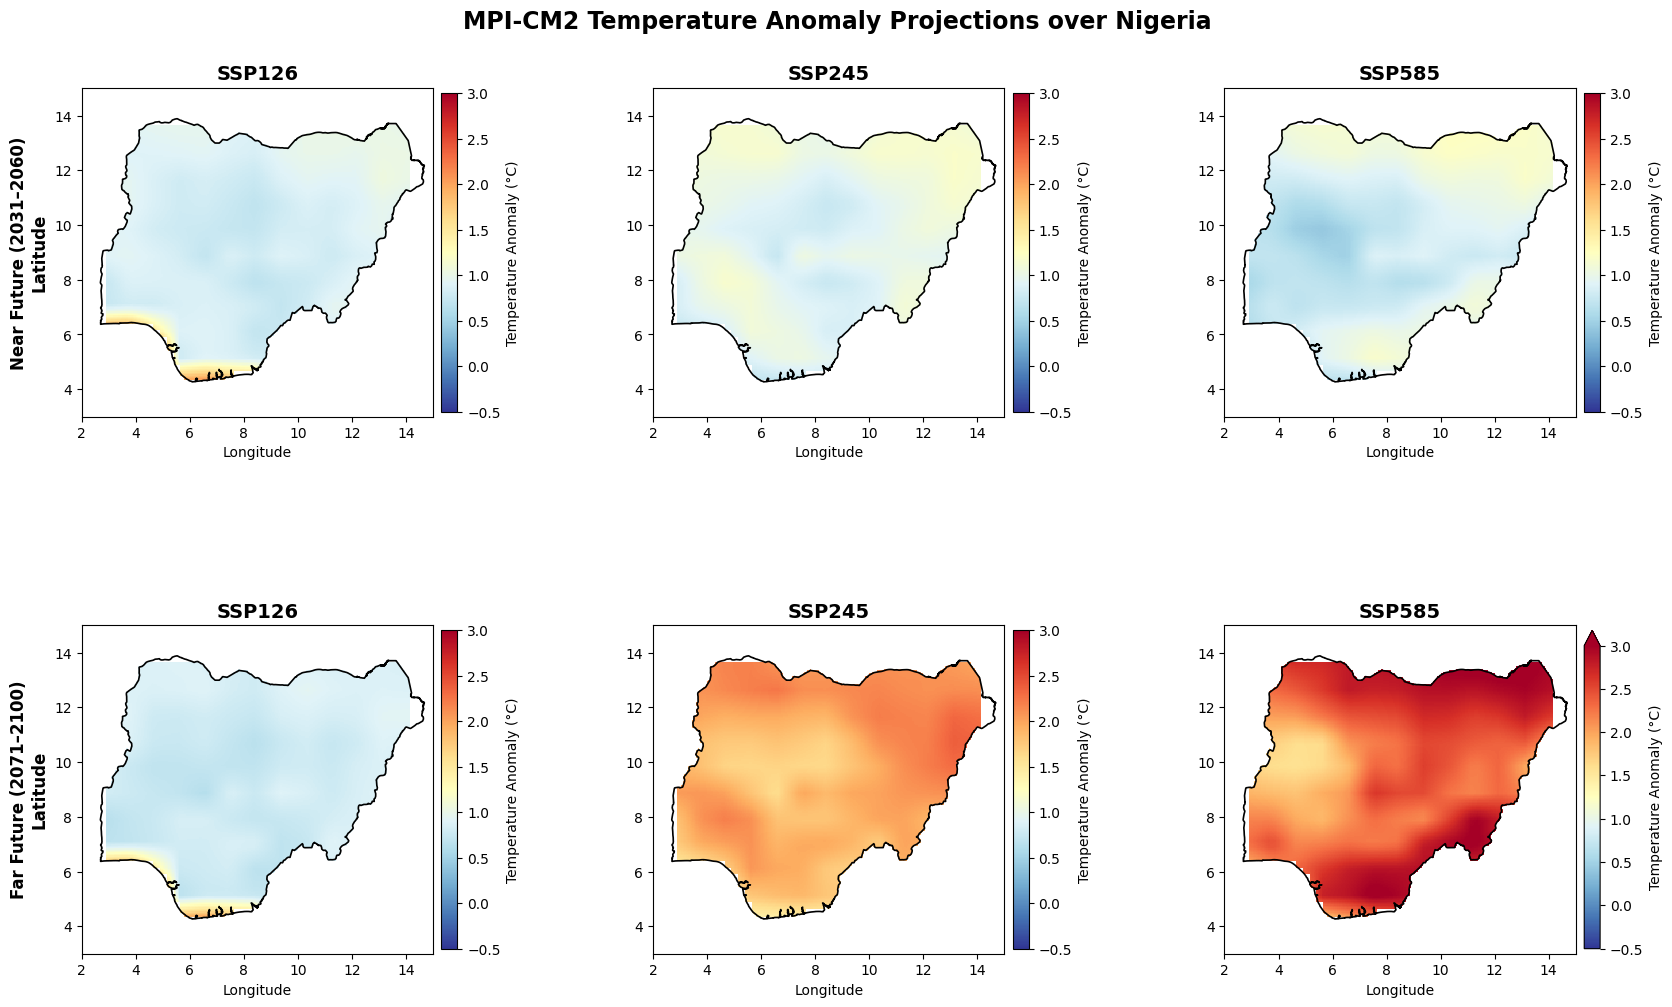

In [182]:
# Plot MPI anomalies over Nigeria
fig, axes = plot_ACCESS_anomalies(
    anomaly_dict=anomaly_dict,
    shapefile_path="/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp",
    model_key='MPI',  # use MPI instead of ACCESS
    vmin=-0.5,        # colorbar min
    vmax=3            # colorbar max
)

# Save the figure
plt.savefig(
    "MPI_CM2_anomalies_nigeria_clipped.png",  # output file path
    dpi=300,                                  # high resolution
    bbox_inches="tight"                       # tight layout
)

# Show the figure
plt.show()


In [200]:
# Create a comprehensive anomaly dictionary with both models
anomaly_dict = {
    'SSP126': {
        'ACCESS': {
            'Near': ssp126_near_future_access,
            'Far': ssp126_far_future_access
        },
        'MPI': {
            'Near': ssp126_near_future_MPI,  # You'll need these variables
            'Far': ssp126_far_future_MPI
        }
    },
    'SSP245': {
        'ACCESS': {
            'Near': ssp245_near_future_access,
            'Far': ssp245_far_future_access
        },
        'MPI': {
            'Near': ssp245_near_future_MPI,  # You'll need these variables
            'Far': ssp245_far_future_MPI
        }
    },
    'SSP585': {
        'ACCESS': {
            'Near': ssp585_near_future_access,
            'Far': ssp585_far_future_access
        },
        'MPI': {
            'Near': ssp585_near_future_MPI,
            'Far': ssp585_far_future_MPI
        }
    }
}

# Verify the structure
print("Checking structure:")
for scenario in ['SSP126', 'SSP245', 'SSP585']:
    print(f"{scenario}: {list(anomaly_dict[scenario].keys())}")

Checking structure:
SSP126: ['ACCESS', 'MPI']
SSP245: ['ACCESS', 'MPI']
SSP585: ['ACCESS', 'MPI']


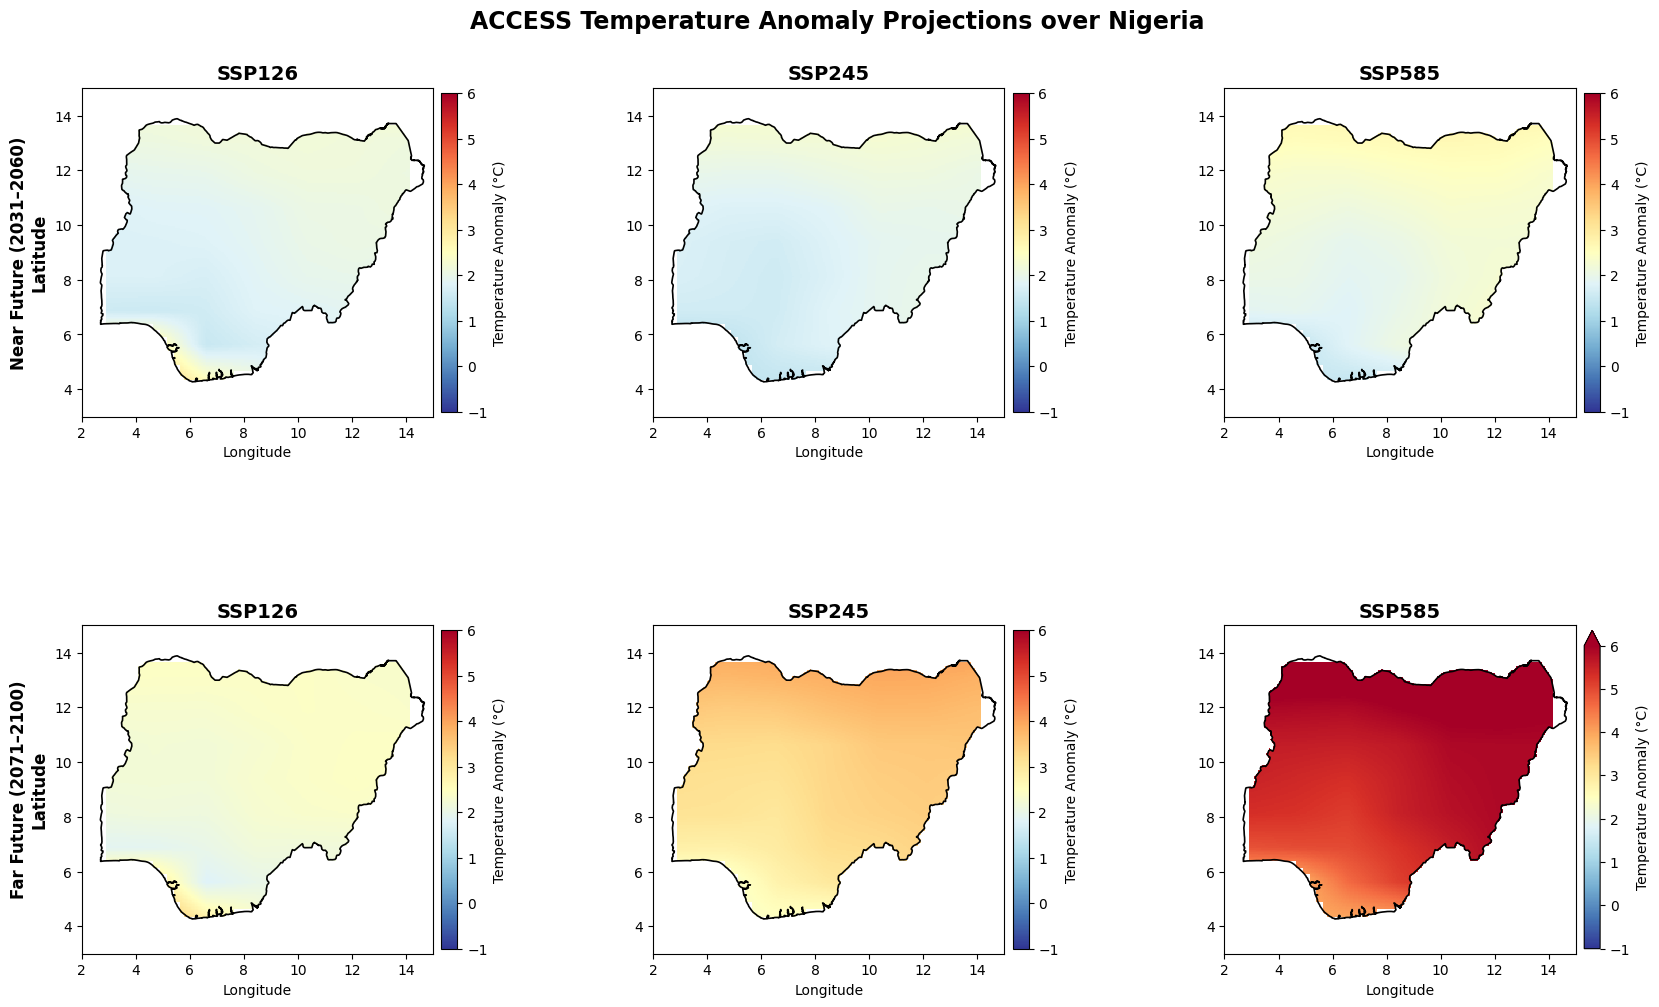

In [202]:
# Plot ACCESS anomalies
fig, axes = plot_ACCESS_anomalies(
    anomaly_dict=anomaly_dict,
    shapefile_path="/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp",
    model_key='ACCESS',
    vmin=-1,
    vmax=6,
    save_path="ACCESS_anomalies_nigeria_clipped.png"
)

In [130]:
# Define historical baseline (1985-2014)
baseline_access = ds_ACCESS_C_annual_celsius.sel(time=slice(1985, 2014)).mean(dim='time')
baseline_mpi    = ds_MPI_C_annual_celsius.sel(time=slice(1985, 2014)).mean(dim='time')

# Define future periods (Near: 2031-2060, Far: 2071-2100)
# Replace these with your loaded datasets for each SSP
future_periods = {
    'SSP126': {'ACCESS_NF': ds_ACCESS_ssp126_nf, 'ACCESS_FF': ds_ACCESS_ssp126_ff,
               'MPI_NF': ds_MPI_ssp126_nf, 'MPI_FF': ds_MPI_ssp126_ff},
    'SSP245': {'ACCESS_NF': ds_ACCESS_ssp245_nf, 'ACCESS_FF': ds_ACCESS_ssp245_ff,
               'MPI_NF': ds_MPI_ssp245_nf, 'MPI_FF': ds_MPI_ssp245_ff},
    'SSP585': {'ACCESS_NF': ds_ACCESS_ssp585_nf, 'ACCESS_FF': ds_ACCESS_ssp585_ff,
               'MPI_NF': ds_MPI_ssp585_nf, 'MPI_FF': ds_MPI_ssp585_ff},
}

# Compute absolute change
abs_change = {}
for ssp, data in future_periods.items():
    abs_change[ssp] = {
        'ACCESS': {
            'Near': data['ACCESS_NF'] - baseline_access,
            'Far': data['ACCESS_FF'] - baseline_access
        },
        'MPI': {
            'Near': data['MPI_NF'] - baseline_mpi,
            'Far': data['MPI_FF'] - baseline_mpi
        }
    }

# Example: Check ACCESS SSP126 Near Future absolute change
print(abs_change['SSP126']['ACCESS']['Near'].mean().values)


1.9306712


In [136]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray

def plot_absolute_change(abs_change_dict, model='ACCESS', shapefile_path=None,
                         vmin=-1, vmax=6, figsize=(18, 11), cmap='RdYlBu_r',
                         title_model=None, save_path=None):
    """
    Plot absolute change of temperature over Nigeria for all SSPs and periods.
    
    Layout:
    Row 1: Near Future (2031-2060)
    Row 2: Far Future (2071-2100)
    Columns: SSP126 | SSP245 | SSP585
    
    Parameters
    ----------
    abs_change_dict : dict
        Dictionary structured like:
        abs_change['SSP126']['ACCESS']['Near']
    model : str
        'ACCESS' or 'MPI'
    shapefile_path : str
        Path to Nigeria shapefile
    vmin, vmax : float
        Colorbar limits
    figsize : tuple
        Figure size
    cmap : str
        Colormap
    title_model : str
        Optional title for model in the main suptitle
    save_path : str
        File path to save figure (optional)
    """
    
    # Load Nigeria shapefile
    shp = gpd.read_file(shapefile_path)
    
    periods = ['Near', 'Far']
    period_labels = ['Near Future (2031-2060)', 'Far Future (2071-2100)']
    scenarios = ['SSP126', 'SSP245', 'SSP585']
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.subplots_adjust(hspace=0.35, wspace=0.35, left=0.08, right=0.95, top=0.93, bottom=0.08)
    
    for i, period in enumerate(periods):
        for j, scenario in enumerate(scenarios):
            ax = axes[i, j]
            data = abs_change_dict[scenario][model][period]
            
            # Temporal mean if 'time' exists
            data_mean = data.mean(dim='time') if 'time' in data.dims else data
            
            # Ensure CRS
            if not hasattr(data_mean.rio, 'crs') or data_mean.rio.crs is None:
                data_mean = data_mean.rio.write_crs("EPSG:4326")
            
            # Clip to Nigeria
            data_clipped = data_mean.rio.clip(shp.geometry, shp.crs, drop=True)
            
           # Plot
            im = data_clipped.plot(
                ax=ax,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                add_colorbar=True,
                cbar_kwargs={'label': '°C', 'shrink': 0.8, 'pad':0.02}
            )
            
            # Fill Nigeria boundaries
            shp.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)
            
            # Set axis limits
            ax.set_xlim(2, 15)
            ax.set_ylim(3, 15)
            

            # Titles and labels
            ax.set_title(scenario, fontsize=14, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f'{period_labels[i]}\nLatitude', fontsize=12, fontweight='bold')
            else:
                ax.set_ylabel('')
            ax.tick_params(labelsize=10)
            ax.grid(False)
    
    # Main title
    if title_model is None:
        title_model = model
    plt.suptitle(f'{title_model} Model Absolute Temperature Change over Nigeria', fontsize=17, fontweight='bold', y=0.97)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, axes


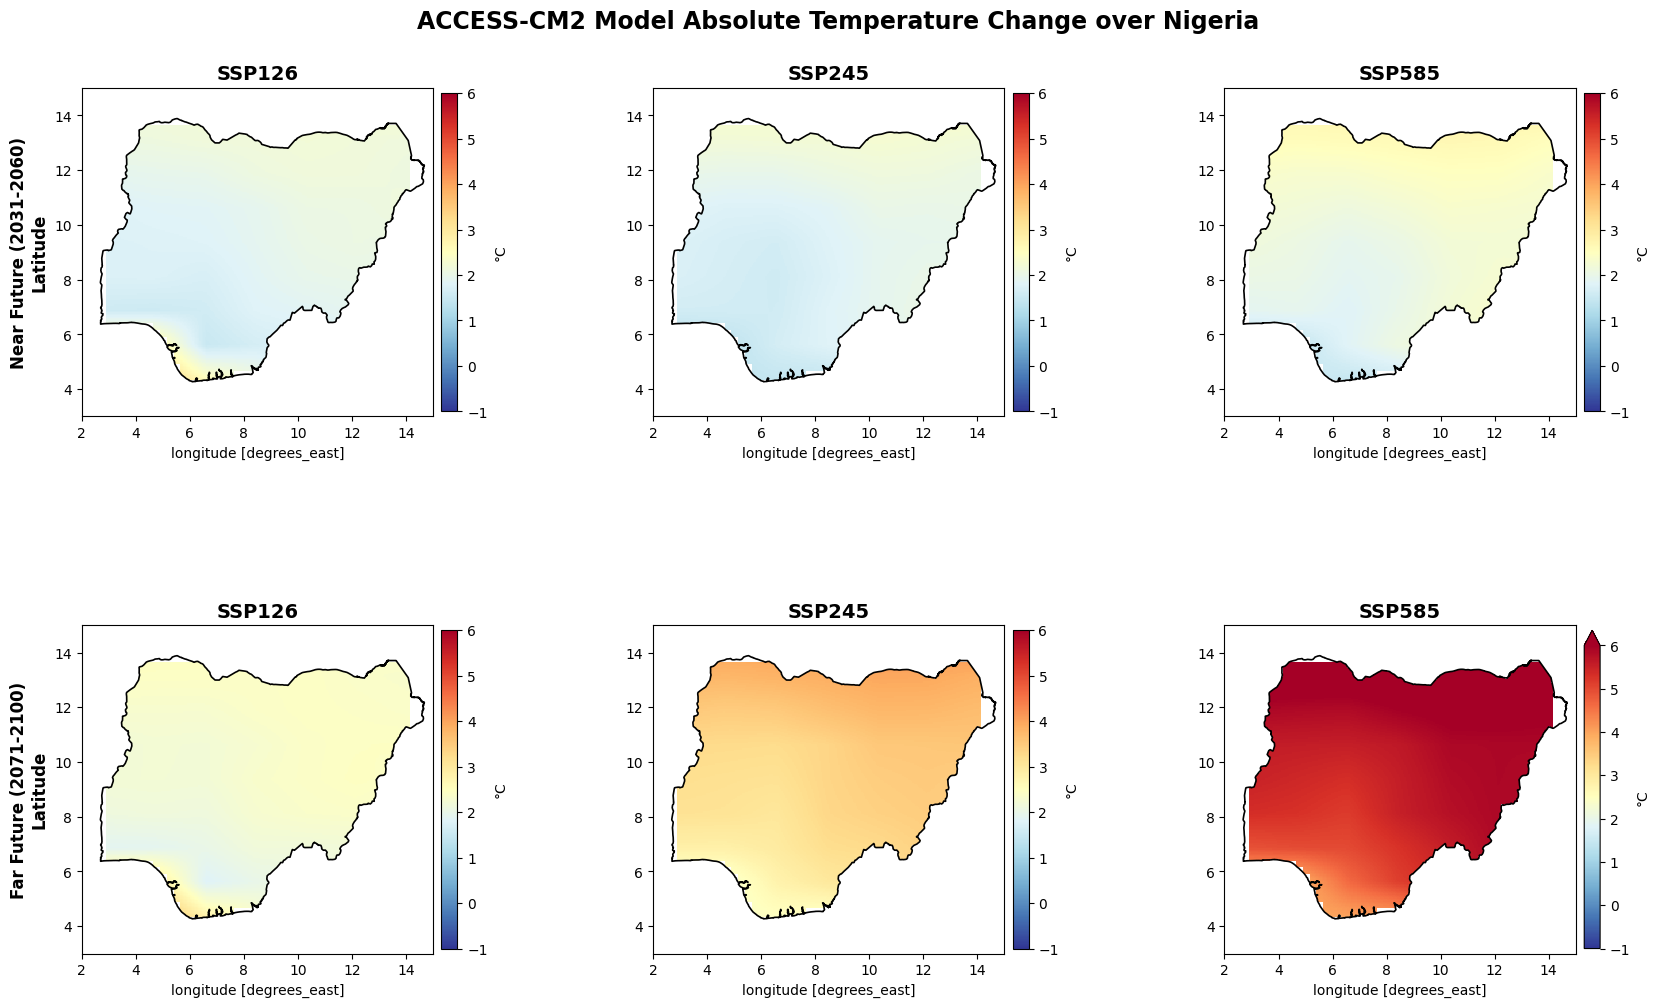

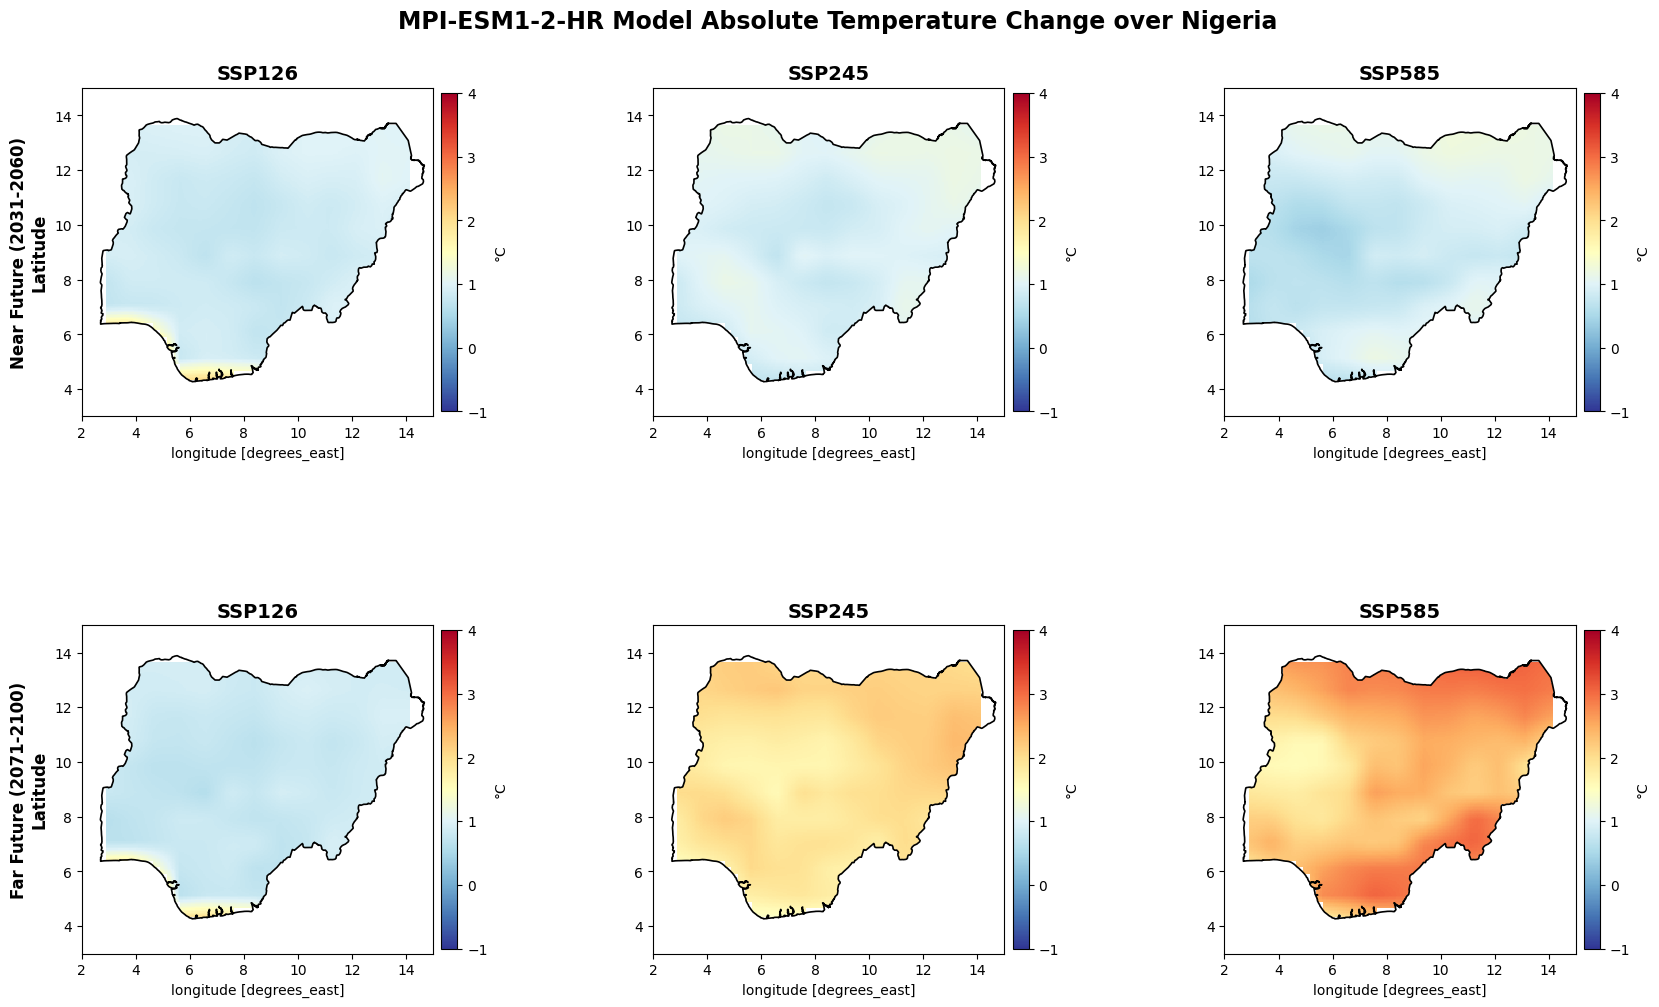

(<Figure size 1800x1100 with 12 Axes>,
 array([[<AxesSubplot: title={'center': 'SSP126'}, xlabel='longitude [degrees_east]', ylabel='Near Future (2031-2060)\nLatitude'>,
         <AxesSubplot: title={'center': 'SSP245'}, xlabel='longitude [degrees_east]'>,
         <AxesSubplot: title={'center': 'SSP585'}, xlabel='longitude [degrees_east]'>],
        [<AxesSubplot: title={'center': 'SSP126'}, xlabel='longitude [degrees_east]', ylabel='Far Future (2071-2100)\nLatitude'>,
         <AxesSubplot: title={'center': 'SSP245'}, xlabel='longitude [degrees_east]'>,
         <AxesSubplot: title={'center': 'SSP585'}, xlabel='longitude [degrees_east]'>]],
       dtype=object))

In [144]:
shapefile_path = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"

# Plot ACCESS absolute change
plot_absolute_change(abs_change, model='ACCESS', shapefile_path=shapefile_path,
                     vmin=-1, vmax=6, title_model='ACCESS-CM2',
                     save_path='ACCESS_absolute_change.png')

# Plot MPI absolute change
plot_absolute_change(abs_change, model='MPI', shapefile_path=shapefile_path,
                     vmin=-1, vmax=4, title_model='MPI-ESM1-2-HR',
                     save_path='MPI_absolute_change.png')


In [158]:
# ===============================
# Historical Mean Temperature
# ===============================

# ACCESS-CM2
access_mean = ds_ACCESS_C_annual_celsius.mean(
    dim=['time', 'latitude', 'longitude'], skipna=True
)
print(f"ACCESS-CM2 Historical Mean (1985-2014): {float(access_mean):.2f} °C")

# MPI-ESM1-2-HR
mpi_mean = ds_MPI_C_annual_celsius.mean(
    dim=['time', 'latitude', 'longitude'], skipna=True
)
print(f"MPI-ESM1-2-HR Historical Mean (1985-2014): {float(mpi_mean):.2f} °C")

# ERA5
era5_mean = ds_era5_celsius['t2m'].mean(
    dim=['time', 'latitude', 'longitude'], skipna=True
)
print(f"ERA5 Historical Mean (1985-2014): {float(era5_mean):.2f} °C")

# ===============================
# Calculate Biases
# ===============================
access_bias = access_mean - era5_mean
mpi_bias    = mpi_mean - era5_mean

print(f"\nACCESS-CM2 Bias: {float(access_bias):+.2f} °C")
print(f"MPI-ESM1-2-HR Bias: {float(mpi_bias):+.2f} °C")


ACCESS-CM2 Historical Mean (1985-2014): 27.21 °C
MPI-ESM1-2-HR Historical Mean (1985-2014): 27.07 °C
ERA5 Historical Mean (1985-2014): 26.96 °C

ACCESS-CM2 Bias: +0.25 °C
MPI-ESM1-2-HR Bias: +0.11 °C


In [159]:
# ============================================
# SSP126 - Spatial Mean (keeping time)
# ============================================

# ACCESS-CM2
ssp126_nf_access_spatial = ssp126_near_future_access.mean(dim=['latitude', 'longitude'])
ssp126_ff_access_spatial = ssp126_far_future_access.mean(dim=['latitude', 'longitude'])

# MPI-ESM1-2-HR
ssp126_nf_mpi_spatial = ssp126_near_future_MPI.mean(dim=['latitude', 'longitude'])
ssp126_ff_mpi_spatial = ssp126_far_future_MPI.mean(dim=['latitude', 'longitude'])

print("SSP126 Near Future ACCESS mean:", ssp126_nf_access_spatial.mean().values, "°C")
print("SSP126 Far Future ACCESS mean:", ssp126_ff_access_spatial.mean().values, "°C")
print("SSP126 Near Future MPI mean:", ssp126_nf_mpi_spatial.mean().values, "°C")
print("SSP126 Far Future MPI mean:", ssp126_ff_mpi_spatial.mean().values, "°C")

# ============================================
# SSP245 - Spatial Mean (keeping time)
# ============================================

# ACCESS-CM2
ssp245_nf_access_spatial = ssp245_near_future_access.mean(dim=['latitude', 'longitude'])
ssp245_ff_access_spatial = ssp245_far_future_access.mean(dim=['latitude', 'longitude'])

# MPI-ESM1-2-HR
ssp245_nf_mpi_spatial = ssp245_near_future_MPI.mean(dim=['latitude', 'longitude'])
ssp245_ff_mpi_spatial = ssp245_far_future_MPI.mean(dim=['latitude', 'longitude'])

print("\nSSP245 Near Future ACCESS mean:", ssp245_nf_access_spatial.mean().values, "°C")
print("SSP245 Far Future ACCESS mean:", ssp245_ff_access_spatial.mean().values, "°C")
print("SSP245 Near Future MPI mean:", ssp245_nf_mpi_spatial.mean().values, "°C")
print("SSP245 Far Future MPI mean:", ssp245_ff_mpi_spatial.mean().values, "°C")

# ============================================
# SSP585 - Spatial Mean (keeping time)
# ============================================

# ACCESS-CM2
ssp585_nf_access_spatial = ssp585_near_future_access.mean(dim=['latitude', 'longitude'])
ssp585_ff_access_spatial = ssp585_far_future_access.mean(dim=['latitude', 'longitude'])

# MPI-ESM1-2-HR
ssp585_nf_mpi_spatial = ssp585_near_future_MPI.mean(dim=['latitude', 'longitude'])
ssp585_ff_mpi_spatial = ssp585_far_future_MPI.mean(dim=['latitude', 'longitude'])

print("\nSSP585 Near Future ACCESS mean:", ssp585_nf_access_spatial.mean().values, "°C")
print("SSP585 Far Future ACCESS mean:", ssp585_ff_access_spatial.mean().values, "°C")
print("SSP585 Near Future MPI mean:", ssp585_nf_mpi_spatial.mean().values, "°C")
print("SSP585 Far Future MPI mean:", ssp585_ff_mpi_spatial.mean().values, "°C")

# ============================================
# Summary Table
# ============================================

print("\n" + "="*70)
print("SSP ANOMALY SPATIAL MEANS (averaged over Nigeria)")
print("="*70)
print(f"{'Scenario':<15} {'Period':<20} {'ACCESS':<15} {'MPI':<15}")
print("-"*70)
print(f"{'SSP126':<15} {'Near (2030-2059)':<20} {ssp126_nf_access_spatial.mean().values:>6.2f}°C     {ssp126_nf_mpi_spatial.mean().values:>6.2f}°C")
print(f"{'SSP126':<15} {'Far (2070-2099)':<20} {ssp126_ff_access_spatial.mean().values:>6.2f}°C     {ssp126_ff_mpi_spatial.mean().values:>6.2f}°C")
print(f"{'SSP245':<15} {'Near (2030-2059)':<20} {ssp245_nf_access_spatial.mean().values:>6.2f}°C     {ssp245_nf_mpi_spatial.mean().values:>6.2f}°C")
print(f"{'SSP245':<15} {'Far (2070-2099)':<20} {ssp245_ff_access_spatial.mean().values:>6.2f}°C     {ssp245_ff_mpi_spatial.mean().values:>6.2f}°C")
print(f"{'SSP585':<15} {'Near (2030-2059)':<20} {ssp585_nf_access_spatial.mean().values:>6.2f}°C     {ssp585_nf_mpi_spatial.mean().values:>6.2f}°C")
print(f"{'SSP585':<15} {'Far (2070-2099)':<20} {ssp585_ff_access_spatial.mean().values:>6.2f}°C     {ssp585_ff_mpi_spatial.mean().values:>6.2f}°C")
print("="*70)

SSP126 Near Future ACCESS mean: 1.9182407 °C
SSP126 Far Future ACCESS mean: 2.2632298 °C
SSP126 Near Future MPI mean: 0.7114052 °C
SSP126 Far Future MPI mean: 0.6527228 °C

SSP245 Near Future ACCESS mean: 1.8884917 °C
SSP245 Far Future ACCESS mean: 3.347051 °C
SSP245 Near Future MPI mean: 0.8171055 °C
SSP245 Far Future MPI mean: 1.7865616 °C

SSP585 Near Future ACCESS mean: 2.2023606 °C
SSP585 Far Future ACCESS mean: 5.630976 °C
SSP585 Near Future MPI mean: 0.71450055 °C
SSP585 Far Future MPI mean: 2.2798321 °C

SSP ANOMALY SPATIAL MEANS (averaged over Nigeria)
Scenario        Period               ACCESS          MPI            
----------------------------------------------------------------------
SSP126          Near (2030-2059)       1.92°C       0.71°C
SSP126          Far (2070-2099)        2.26°C       0.65°C
SSP245          Near (2030-2059)       1.89°C       0.82°C
SSP245          Far (2070-2099)        3.35°C       1.79°C
SSP585          Near (2030-2059)       2.20°C       0.71

In [160]:
import numpy as np

# ============================================
# Calculate Historical Spatial Mean (keep time dimension)
# ============================================

# Historical spatial means (averaged over lat/lon, keeping time)
access_historical_spatial = ds_ACCESS_C_annual_celsius.mean(dim=['latitude', 'longitude'])
mpi_historical_spatial = ds_MPI_C_annual_celsius.mean(dim=['latitude', 'longitude'])

# Historical period mean (single value - averaged over time, lat, lon)
access_historical_mean = ds_ACCESS_C_annual_celsius.mean(dim=['time', 'latitude', 'longitude'])
mpi_historical_mean = ds_MPI_C_annual_celsius.mean(dim=['time', 'latitude', 'longitude'])

print(f"ACCESS Historical Mean: {access_historical_mean.values:.2f}°C")
print(f"MPI Historical Mean: {mpi_historical_mean.values:.2f}°C")

# ============================================
# Calculate SSP Spatial Means (averaged over lat/lon only)
# ============================================

# ACCESS SSP scenarios - spatial mean (keep time dimension)
access_ssp126_nf_spatial = ds_ACCESS_ssp126_nf.mean(dim=['latitude', 'longitude'])
access_ssp126_ff_spatial = ds_ACCESS_ssp126_ff.mean(dim=['latitude', 'longitude'])
access_ssp245_nf_spatial = ds_ACCESS_ssp245_nf.mean(dim=['latitude', 'longitude'])
access_ssp245_ff_spatial = ds_ACCESS_ssp245_ff.mean(dim=['latitude', 'longitude'])
access_ssp585_nf_spatial = ds_ACCESS_ssp585_nf.mean(dim=['latitude', 'longitude'])
access_ssp585_ff_spatial = ds_ACCESS_ssp585_ff.mean(dim=['latitude', 'longitude'])

# MPI SSP scenarios - spatial mean (keep time dimension)
mpi_ssp126_nf_spatial = ds_MPI_ssp126_nf.mean(dim=['latitude', 'longitude'])
mpi_ssp126_ff_spatial = ds_MPI_ssp126_ff.mean(dim=['latitude', 'longitude'])
mpi_ssp245_nf_spatial = ds_MPI_ssp245_nf.mean(dim=['latitude', 'longitude'])
mpi_ssp245_ff_spatial = ds_MPI_ssp245_ff.mean(dim=['latitude', 'longitude'])
mpi_ssp585_nf_spatial = ds_MPI_ssp585_nf.mean(dim=['latitude', 'longitude'])
mpi_ssp585_ff_spatial = ds_MPI_ssp585_ff.mean(dim=['latitude', 'longitude'])

# ============================================
# Calculate Anomalies (SSP mean - Historical mean)
# ============================================

# ACCESS anomalies
access_ssp126_nf_anomaly = access_ssp126_nf_spatial.mean() - access_historical_mean
access_ssp126_ff_anomaly = access_ssp126_ff_spatial.mean() - access_historical_mean
access_ssp245_nf_anomaly = access_ssp245_nf_spatial.mean() - access_historical_mean
access_ssp245_ff_anomaly = access_ssp245_ff_spatial.mean() - access_historical_mean
access_ssp585_nf_anomaly = access_ssp585_nf_spatial.mean() - access_historical_mean
access_ssp585_ff_anomaly = access_ssp585_ff_spatial.mean() - access_historical_mean

# MPI anomalies
mpi_ssp126_nf_anomaly = mpi_ssp126_nf_spatial.mean() - mpi_historical_mean
mpi_ssp126_ff_anomaly = mpi_ssp126_ff_spatial.mean() - mpi_historical_mean
mpi_ssp245_nf_anomaly = mpi_ssp245_nf_spatial.mean() - mpi_historical_mean
mpi_ssp245_ff_anomaly = mpi_ssp245_ff_spatial.mean() - mpi_historical_mean
mpi_ssp585_nf_anomaly = mpi_ssp585_nf_spatial.mean() - mpi_historical_mean
mpi_ssp585_ff_anomaly = mpi_ssp585_ff_spatial.mean() - mpi_historical_mean

# ============================================
# Print Results
# ============================================

print("\n" + "="*70)
print("ACCESS-CM2 TEMPERATURE ANOMALIES (Relative to 1985-2014)")
print("="*70)
print(f"SSP126 Near Future (2030-2059): {access_ssp126_nf_anomaly.values:+.2f}°C")
print(f"SSP126 Far Future (2070-2099):  {access_ssp126_ff_anomaly.values:+.2f}°C")
print(f"SSP245 Near Future (2030-2059): {access_ssp245_nf_anomaly.values:+.2f}°C")
print(f"SSP245 Far Future (2070-2099):  {access_ssp245_ff_anomaly.values:+.2f}°C")
print(f"SSP585 Near Future (2030-2059): {access_ssp585_nf_anomaly.values:+.2f}°C")
print(f"SSP585 Far Future (2070-2099):  {access_ssp585_ff_anomaly.values:+.2f}°C")

print("\n" + "="*70)
print("MPI-ESM1-2-HR TEMPERATURE ANOMALIES (Relative to 1985-2014)")
print("="*70)
print(f"SSP126 Near Future (2030-2059): {mpi_ssp126_nf_anomaly.values:+.2f}°C")
print(f"SSP126 Far Future (2070-2099):  {mpi_ssp126_ff_anomaly.values:+.2f}°C")
print(f"SSP245 Near Future (2030-2059): {mpi_ssp245_nf_anomaly.values:+.2f}°C")
print(f"SSP245 Far Future (2070-2099):  {mpi_ssp245_ff_anomaly.values:+.2f}°C")
print(f"SSP585 Near Future (2030-2059): {mpi_ssp585_nf_anomaly.values:+.2f}°C")
print(f"SSP585 Far Future (2070-2099):  {mpi_ssp585_ff_anomaly.values:+.2f}°C")
print("="*70)

# ============================================
# Create Summary Table
# ============================================

import pandas as pd

summary_data = {
    'Scenario': ['SSP126 NF', 'SSP126 FF', 'SSP245 NF', 'SSP245 FF', 'SSP585 NF', 'SSP585 FF'],
    'ACCESS-CM2 (°C)': [
        access_ssp126_nf_anomaly.values,
        access_ssp126_ff_anomaly.values,
        access_ssp245_nf_anomaly.values,
        access_ssp245_ff_anomaly.values,
        access_ssp585_nf_anomaly.values,
        access_ssp585_ff_anomaly.values
    ],
    'MPI-ESM1-2-HR (°C)': [
        mpi_ssp126_nf_anomaly.values,
        mpi_ssp126_ff_anomaly.values,
        mpi_ssp245_nf_anomaly.values,
        mpi_ssp245_ff_anomaly.values,
        mpi_ssp585_nf_anomaly.values,
        mpi_ssp585_ff_anomaly.values
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("SUMMARY TABLE: Temperature Anomalies (°C)")
print("="*70)
print(df_summary.to_string(index=False))
print("="*70)

ACCESS Historical Mean: 27.21°C
MPI Historical Mean: 27.07°C

ACCESS-CM2 TEMPERATURE ANOMALIES (Relative to 1985-2014)
SSP126 Near Future (2030-2059): +1.93°C
SSP126 Far Future (2070-2099):  +2.28°C
SSP245 Near Future (2030-2059): +1.90°C
SSP245 Far Future (2070-2099):  +3.36°C
SSP585 Near Future (2030-2059): +2.21°C
SSP585 Far Future (2070-2099):  +5.64°C

MPI-ESM1-2-HR TEMPERATURE ANOMALIES (Relative to 1985-2014)
SSP126 Near Future (2030-2059): +0.86°C
SSP126 Far Future (2070-2099):  +0.80°C
SSP245 Near Future (2030-2059): +0.97°C
SSP245 Far Future (2070-2099):  +1.94°C
SSP585 Near Future (2030-2059): +0.87°C
SSP585 Far Future (2070-2099):  +2.43°C

SUMMARY TABLE: Temperature Anomalies (°C)
 Scenario ACCESS-CM2 (°C) MPI-ESM1-2-HR (°C)
SSP126 NF       1.9306698          0.8621712
SSP126 FF       2.2756577          0.8034878
SSP245 NF        1.900919          0.9678707
SSP245 FF        3.359478          1.9373322
SSP585 NF       2.2147923          0.8652668
SSP585 FF        5.643404  

In [161]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ssp_anomalies_comparison(
    access_anomalies,
    mpi_anomalies,
    scenarios=['SSP126', 'SSP245', 'SSP585'],
    periods=['Near Future\n(2030-2059)', 'Far Future\n(2071-2100)']
):
    """
    Plot temperature anomalies for all SSP scenarios for both models.
    
    Parameters:
    -----------
    access_anomalies : dict
        Dictionary with keys like 'ssp126_nf', 'ssp126_ff', etc. containing anomaly values
    mpi_anomalies : dict
        Dictionary with keys like 'ssp126_nf', 'ssp126_ff', etc. containing anomaly values
    scenarios : list
        List of scenario names
    periods : list
        List of period names
    """
    
    # Prepare data
    scenario_keys = ['ssp126', 'ssp245', 'ssp585']
    period_keys = ['nf', 'ff']
    
    # Extract values
    access_data = np.array([
        [access_anomalies[f'{sc}_{p}'] for p in period_keys]
        for sc in scenario_keys
    ])
    
    mpi_data = np.array([
        [mpi_anomalies[f'{sc}_{p}'] for p in period_keys]
        for sc in scenario_keys
    ])
    
    # Create figure with 2 subplots (side by side)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Set up bar positions
    x = np.arange(len(periods))
    width = 0.25
    
    colors = ['#4575b4', '#fdae61', '#d73027']  # Blue, Orange, Red for SSP126, 245, 585
    
    # ===== ACCESS-CM2 Plot =====
    ax = axes[0]
    
    for i, (scenario, color) in enumerate(zip(scenarios, colors)):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, access_data[i], width, 
                     label=scenario, color=color, alpha=0.8, edgecolor='black', linewidth=1.2)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}°C',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Time Period', fontsize=13, fontweight='bold')
    ax.set_ylabel('Temperature Anomaly (°C)', fontsize=13, fontweight='bold')
    ax.set_title('ACCESS-CM2', fontsize=15, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(periods, fontsize=11)
    ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.set_ylim(0, max(access_data.max(), mpi_data.max()) * 1.15)
    ax.tick_params(labelsize=10)
    
    # ===== MPI-ESM1-2-HR Plot =====
    ax = axes[1]
    
    for i, (scenario, color) in enumerate(zip(scenarios, colors)):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, mpi_data[i], width, 
                     label=scenario, color=color, alpha=0.8, edgecolor='black', linewidth=1.2)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}°C',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Time Period', fontsize=13, fontweight='bold')
    ax.set_ylabel('Temperature Anomaly (°C)', fontsize=13, fontweight='bold')
    ax.set_title('MPI-ESM1-2-HR', fontsize=15, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(periods, fontsize=11)
    ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.set_ylim(0, max(access_data.max(), mpi_data.max()) * 1.15)
    ax.tick_params(labelsize=10)
    
    # Overall title
    plt.suptitle('Temperature Anomalies over Nigeria (Relative to 1985-2014 Baseline)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    return fig, axes


def plot_ssp_anomalies_combined(
    access_anomalies,
    mpi_anomalies,
    scenarios=['SSP126', 'SSP245', 'SSP585'],
    periods=['Near Future\n(2030-2059)', 'Far Future\n(2070-2099)']
):
    """
    Plot temperature anomalies showing both models on the same plot for each scenario.
    """
    
    # Prepare data
    scenario_keys = ['ssp126', 'ssp245', 'ssp585']
    period_keys = ['nf', 'ff']
    
    # Create figure with 3 subplots (one for each scenario)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    colors = {'ACCESS-CM2': '#2166ac', 'MPI-ESM1-2-HR': '#b2182b'}
    
    for i, (scenario, sc_key) in enumerate(zip(scenarios, scenario_keys)):
        ax = axes[i]
        
        # Get data for this scenario
        access_vals = [access_anomalies[f'{sc_key}_{p}'] for p in period_keys]
        mpi_vals = [mpi_anomalies[f'{sc_key}_{p}'] for p in period_keys]
        
        x = np.arange(len(periods))
        width = 0.35
        
        # Plot bars
        bars1 = ax.bar(x - width/2, access_vals, width, 
                      label='ACCESS-CM2', color=colors['ACCESS-CM2'], 
                      alpha=0.8, edgecolor='black', linewidth=1.2)
        bars2 = ax.bar(x + width/2, mpi_vals, width, 
                      label='MPI-ESM1-2-HR', color=colors['MPI-ESM1-2-HR'], 
                      alpha=0.8, edgecolor='black', linewidth=1.2)
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
        if i == 0:
            ax.set_ylabel('Temperature Anomaly (°C)', fontsize=12, fontweight='bold')
        ax.set_title(scenario, fontsize=14, fontweight='bold', pad=12)
        ax.set_xticks(x)
        ax.set_xticklabels(periods, fontsize=10)
        ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
        ax.tick_params(labelsize=9)
    
    # Set same y-axis limits for all subplots
    max_val = max(
        max([access_anomalies[f'{sc}_{p}'] for sc in scenario_keys for p in period_keys]),
        max([mpi_anomalies[f'{sc}_{p}'] for sc in scenario_keys for p in period_keys])
    )
    for ax in axes:
        ax.set_ylim(0, max_val * 1.15)
    
    plt.suptitle('Temperature Anomalies over Nigeria by SSP Scenario (Relative to 1985-2014)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    return fig, axes


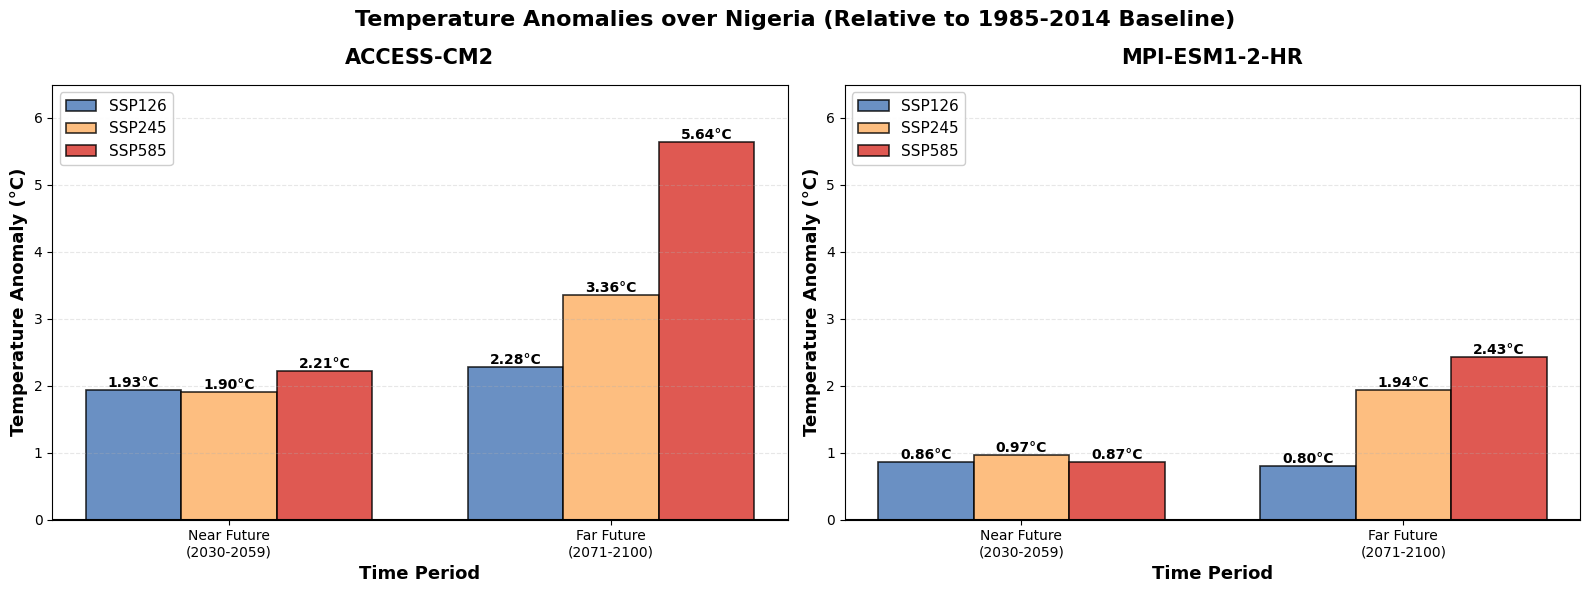

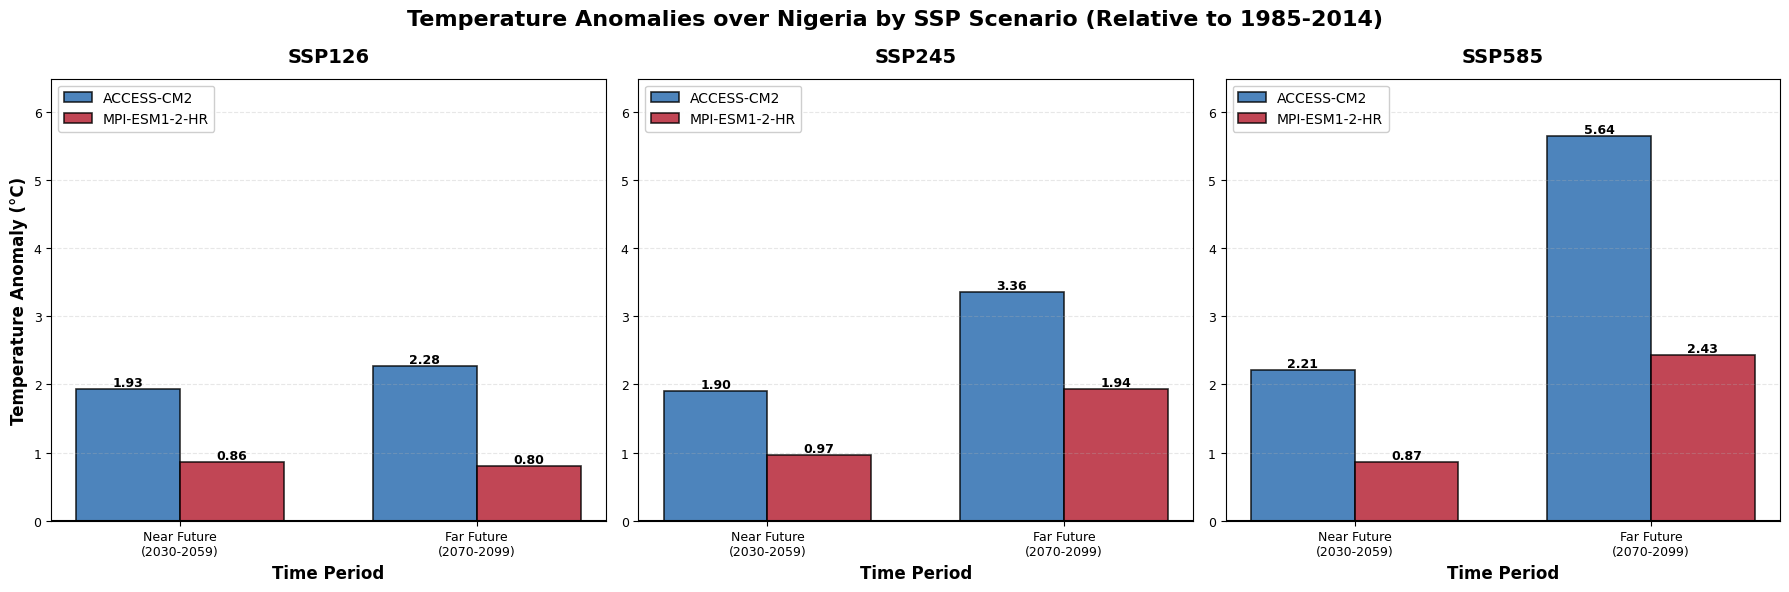

In [162]:
# First, prepare your anomaly dictionaries
access_anomalies = {
    'ssp126_nf': access_ssp126_nf_anomaly.values,
    'ssp126_ff': access_ssp126_ff_anomaly.values,
    'ssp245_nf': access_ssp245_nf_anomaly.values,
    'ssp245_ff': access_ssp245_ff_anomaly.values,
    'ssp585_nf': access_ssp585_nf_anomaly.values,
    'ssp585_ff': access_ssp585_ff_anomaly.values
}

mpi_anomalies = {
    'ssp126_nf': mpi_ssp126_nf_anomaly.values,
    'ssp126_ff': mpi_ssp126_ff_anomaly.values,
    'ssp245_nf': mpi_ssp245_nf_anomaly.values,
    'ssp245_ff': mpi_ssp245_ff_anomaly.values,
    'ssp585_nf': mpi_ssp585_nf_anomaly.values,
    'ssp585_ff': mpi_ssp585_ff_anomaly.values
}

# Option 1: By model (recommended for comparing scenarios within each model)
fig1, axes1 = plot_ssp_anomalies_comparison(access_anomalies, mpi_anomalies)
plt.savefig('SSP_anomalies_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

# Option 2: By scenario (recommended for comparing models within each scenario)
fig2, axes2 = plot_ssp_anomalies_combined(access_anomalies, mpi_anomalies)
plt.savefig('SSP_anomalies_by_scenario.png', dpi=300, bbox_inches='tight')
plt.show()

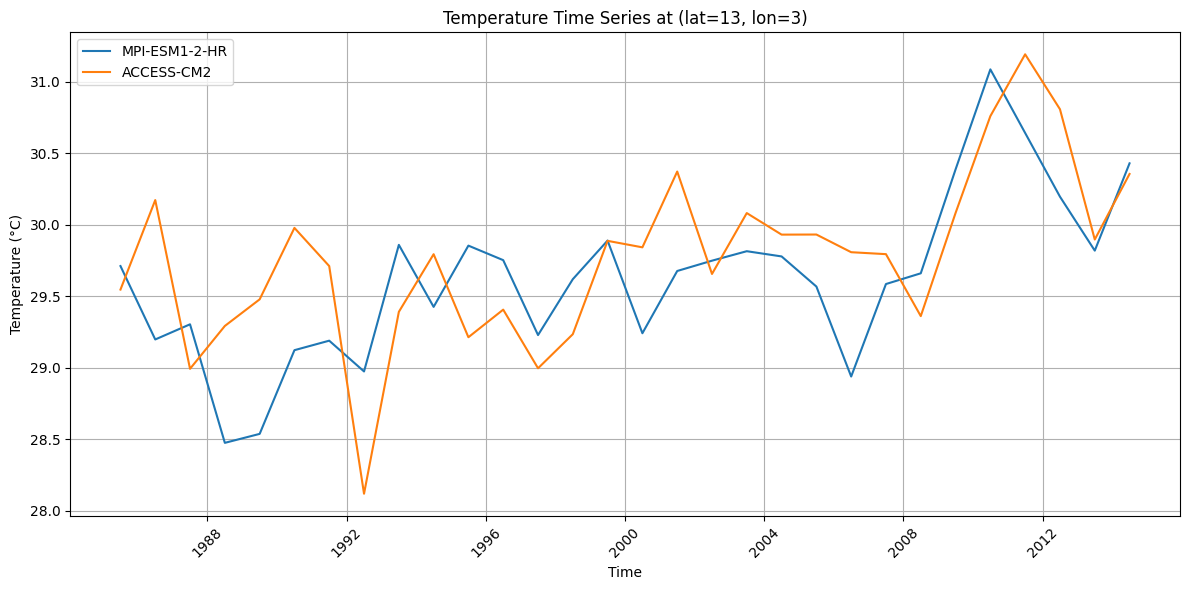

In [163]:
import matplotlib.pyplot as plt
import pandas as pd

# Select the same location and convert to °C
mpi_temp = ds_MPI_ESM1_2_HR_historical['tas'].sel(longitude=3, latitude=13, method='nearest') - 273.15
access_temp = ds_ACCESS_CM2_historical['tas'].sel(longitude=3, latitude=13, method='nearest') - 273.15

# Convert to pandas DataFrame
mpi_df = mpi_temp.to_dataframe(name='MPI-ESM1-2-HR')
access_df = access_temp.to_dataframe(name='ACCESS-CM2')

# Plot both datasets
plt.figure(figsize=(12,6))
plt.plot(mpi_df.index, mpi_df['MPI-ESM1-2-HR'], label='MPI-ESM1-2-HR')
plt.plot(access_df.index, access_df['ACCESS-CM2'], label='ACCESS-CM2')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Time Series at (lat=13, lon=3)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure as JPG
plt.savefig("temperature_timeseries.jpg", format='jpg', dpi=300)

# Show the plot
plt.show()


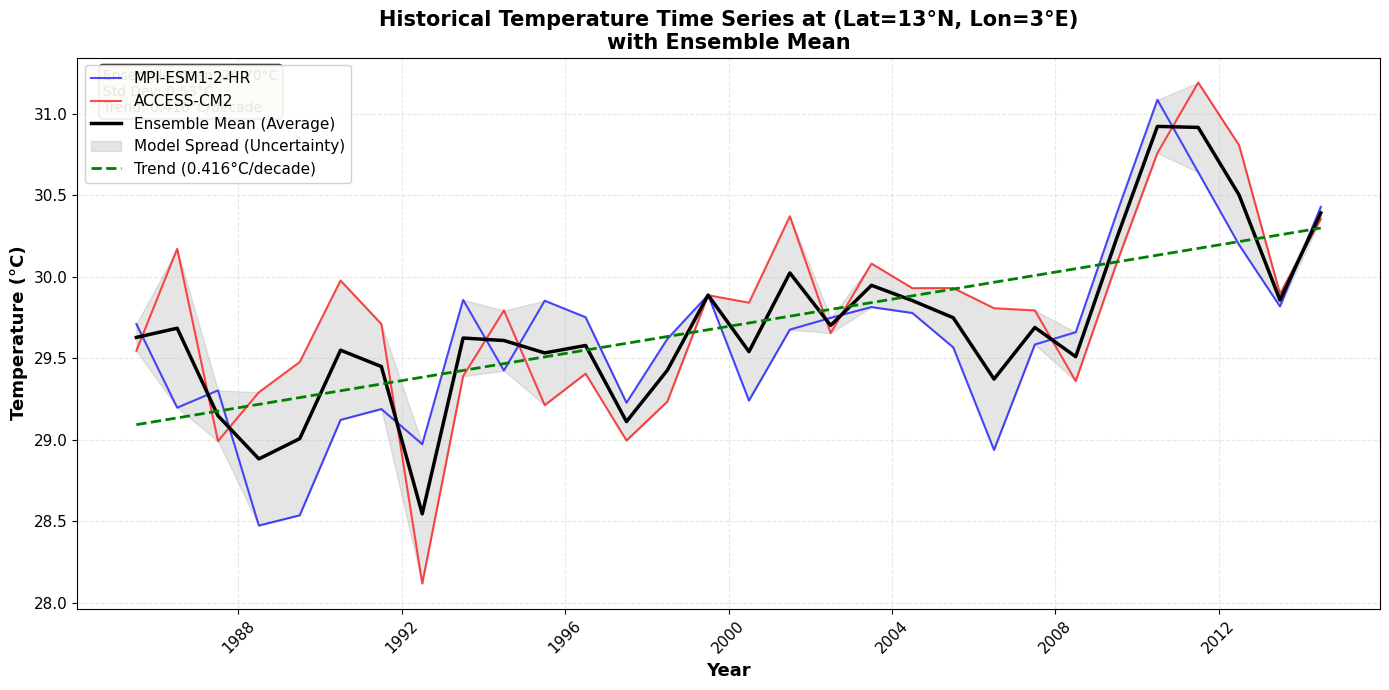

=== Temperature Statistics (Historical Period) ===
Location: Latitude 13°N, Longitude 3°E

MPI-ESM1-2-HR:
  Mean: 29.62°C
  Min: 28.47°C
  Max: 31.09°C
  Std: 0.57°C

ACCESS-CM2:
  Mean: 29.77°C
  Min: 28.12°C
  Max: 31.19°C
  Std: 0.61°C

Ensemble Mean:
  Mean: 29.70°C
  Min: 28.55°C
  Max: 30.92°C
  Std: 0.53°C
  Trend: 0.416°C/decade

Model Agreement:
  Mean difference: 0.45°C
  Correlation: 0.620


In [233]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select the same location and convert to °C
mpi_temp = ds_MPI_ESM1_2_HR_historical['tas'].sel(longitude=3, latitude=13, method='nearest') - 273.15
access_temp = ds_ACCESS_CM2_historical['tas'].sel(longitude=3, latitude=13, method='nearest') - 273.15

# Convert to pandas DataFrame
mpi_df = mpi_temp.to_dataframe(name='MPI-ESM1-2-HR')
access_df = access_temp.to_dataframe(name='ACCESS-CM2')

# Calculate ensemble mean (average of both models)
ensemble_mean = (mpi_df['MPI-ESM1-2-HR'] + access_df['ACCESS-CM2']) / 2

# Calculate model spread (difference between models)
model_spread = np.abs(mpi_df['MPI-ESM1-2-HR'] - access_df['ACCESS-CM2'])

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot individual models with transparency
ax.plot(mpi_df.index, mpi_df['MPI-ESM1-2-HR'], 
        label='MPI-ESM1-2-HR', color='blue', linewidth=1.5, alpha=0.7)
ax.plot(access_df.index, access_df['ACCESS-CM2'], 
        label='ACCESS-CM2', color='red', linewidth=1.5, alpha=0.7)

# Plot ensemble mean with thicker line
ax.plot(ensemble_mean.index, ensemble_mean, 
        label='Ensemble Mean (Average)', color='black', linewidth=2.5, linestyle='-')

# Add shaded area showing model spread (uncertainty)
ax.fill_between(mpi_df.index, 
                ensemble_mean - model_spread/2, 
                ensemble_mean + model_spread/2,
                color='gray', alpha=0.2, label='Model Spread (Uncertainty)')

# Calculate and add trend line for ensemble mean
z = np.polyfit(range(len(ensemble_mean)), ensemble_mean.values, 1)
p = np.poly1d(z)
trend_line = p(range(len(ensemble_mean)))
ax.plot(ensemble_mean.index, trend_line, 
        '--', color='green', linewidth=2, label=f'Trend ({z[0]*10:.3f}°C/decade)')

# Labels and formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold')
ax.set_title('Historical Temperature Time Series at (Lat=13°N, Lon=3°E)\nwith Ensemble Mean', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(labelsize=11)

# Add statistics text box
mean_temp = ensemble_mean.mean()
std_temp = ensemble_mean.std()
trend_per_decade = z[0] * 10
stats_text = f'Ensemble Mean: {mean_temp:.2f}°C\nStd Dev: {std_temp:.2f}°C\nTrend: {trend_per_decade:.3f}°C/decade'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure
plt.savefig("temperature_timeseries_with_ensemble.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.savefig("temperature_timeseries_with_ensemble.png", format='png', dpi=300, bbox_inches='tight')

plt.show()

# Print summary statistics
print("=== Temperature Statistics (Historical Period) ===")
print(f"Location: Latitude 13°N, Longitude 3°E")
print(f"\nMPI-ESM1-2-HR:")
print(f"  Mean: {mpi_df['MPI-ESM1-2-HR'].mean():.2f}°C")
print(f"  Min: {mpi_df['MPI-ESM1-2-HR'].min():.2f}°C")
print(f"  Max: {mpi_df['MPI-ESM1-2-HR'].max():.2f}°C")
print(f"  Std: {mpi_df['MPI-ESM1-2-HR'].std():.2f}°C")

print(f"\nACCESS-CM2:")
print(f"  Mean: {access_df['ACCESS-CM2'].mean():.2f}°C")
print(f"  Min: {access_df['ACCESS-CM2'].min():.2f}°C")
print(f"  Max: {access_df['ACCESS-CM2'].max():.2f}°C")
print(f"  Std: {access_df['ACCESS-CM2'].std():.2f}°C")

print(f"\nEnsemble Mean:")
print(f"  Mean: {ensemble_mean.mean():.2f}°C")
print(f"  Min: {ensemble_mean.min():.2f}°C")
print(f"  Max: {ensemble_mean.max():.2f}°C")
print(f"  Std: {ensemble_mean.std():.2f}°C")
print(f"  Trend: {trend_per_decade:.3f}°C/decade")

print(f"\nModel Agreement:")
print(f"  Mean difference: {np.abs(mpi_df['MPI-ESM1-2-HR'] - access_df['ACCESS-CM2']).mean():.2f}°C")
print(f"  Correlation: {mpi_df['MPI-ESM1-2-HR'].corr(access_df['ACCESS-CM2']):.3f}")

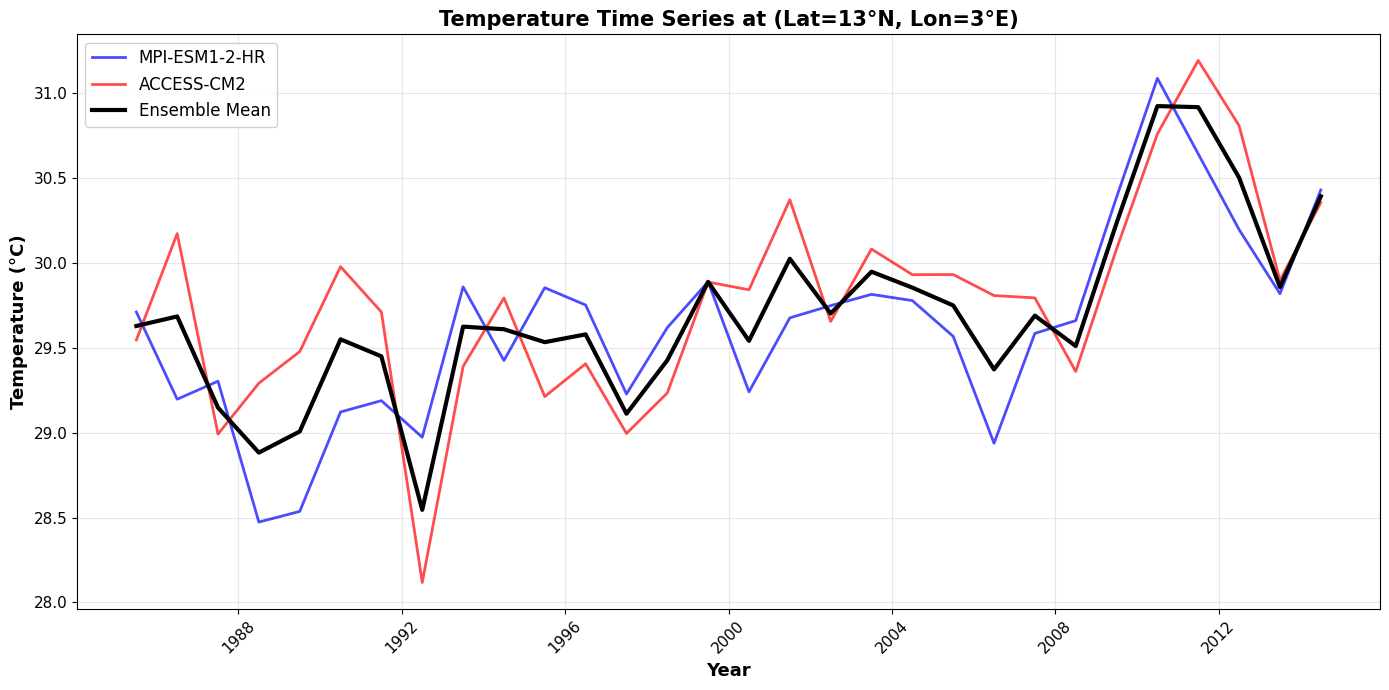

In [237]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select the same location and convert to °C
mpi_temp = ds_MPI_ESM1_2_HR_historical['tas'].sel(longitude=3, latitude=13, method='nearest') - 273.15
access_temp = ds_ACCESS_CM2_historical['tas'].sel(longitude=3, latitude=13, method='nearest') - 273.15

# Convert to pandas DataFrame
mpi_df = mpi_temp.to_dataframe(name='MPI-ESM1-2-HR')
access_df = access_temp.to_dataframe(name='ACCESS-CM2')

# Calculate ensemble mean (average of both models)
ensemble_mean = (mpi_df['MPI-ESM1-2-HR'] + access_df['ACCESS-CM2']) / 2

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot individual models
ax.plot(mpi_df.index, mpi_df['MPI-ESM1-2-HR'], 
        label='MPI-ESM1-2-HR', color='blue', linewidth=2, alpha=0.7)
ax.plot(access_df.index, access_df['ACCESS-CM2'], 
        label='ACCESS-CM2', color='red', linewidth=2, alpha=0.7)

# Plot ensemble mean
ax.plot(ensemble_mean.index, ensemble_mean, 
        label='Ensemble Mean', color='black', linewidth=3)

# Labels and formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold')
ax.set_title('Temperature Time Series at (Lat=13°N, Lon=3°E)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure
plt.savefig("temperature_timeseries_ensemble.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.savefig("temperature_timeseries_ensemble.png", format='png', dpi=300, bbox_inches='tight')

plt.show()

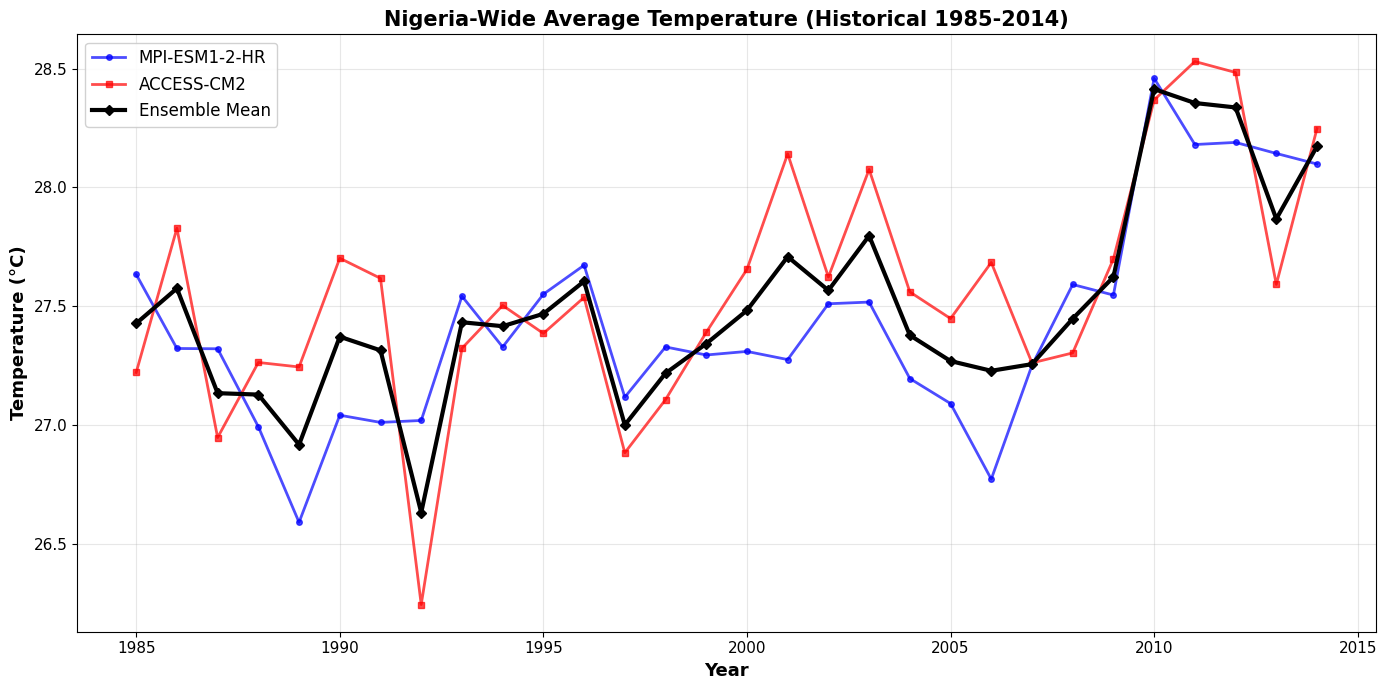

In [236]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

shapefile_path = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"
shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# Ensure CRS
if not hasattr(ds_ACCESS_C_annual_celsius.rio, 'crs') or ds_ACCESS_C_annual_celsius.rio.crs is None:
    ds_ACCESS_C_annual_celsius = ds_ACCESS_C_annual_celsius.rio.write_crs("EPSG:4326")
if not hasattr(ds_MPI_C_annual_celsius.rio, 'crs') or ds_MPI_C_annual_celsius.rio.crs is None:
    ds_MPI_C_annual_celsius = ds_MPI_C_annual_celsius.rio.write_crs("EPSG:4326")

# Clip to Nigeria
access_clipped = ds_ACCESS_C_annual_celsius.rio.clip(shp.geometry, shp.crs, drop=True)
mpi_clipped = ds_MPI_C_annual_celsius.rio.clip(shp.geometry, shp.crs, drop=True)

# Calculate spatial mean
access_nigeria = access_clipped.mean(dim=['latitude', 'longitude'], skipna=True)
mpi_nigeria = mpi_clipped.mean(dim=['latitude', 'longitude'], skipna=True)

# Calculate ensemble mean
ensemble_mean = (access_nigeria + mpi_nigeria) / 2

# Get years
years = ensemble_mean.time.values

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot both models
ax.plot(years, mpi_nigeria, label='MPI-ESM1-2-HR', 
        color='blue', linewidth=2, alpha=0.7, marker='o', markersize=4)
ax.plot(years, access_nigeria, label='ACCESS-CM2', 
        color='red', linewidth=2, alpha=0.7, marker='s', markersize=4)

# Plot ensemble mean
ax.plot(years, ensemble_mean, label='Ensemble Mean', 
        color='black', linewidth=3, marker='D', markersize=5)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold')
ax.set_title('Nigeria-Wide Average Temperature (Historical 1985-2014)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("nigeria_temperature_ensemble.jpg", dpi=300, bbox_inches='tight')
plt.savefig("nigeria_temperature_ensemble.png", dpi=300, bbox_inches='tight')
plt.show()

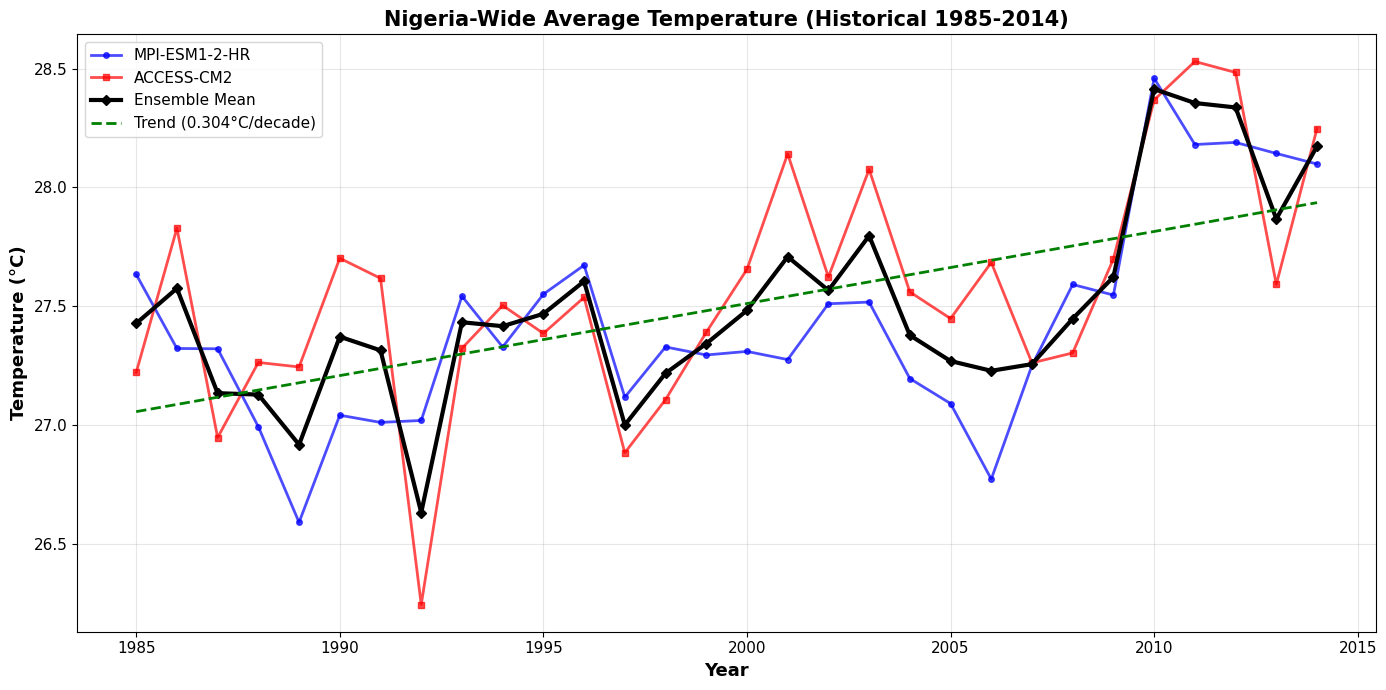

In [234]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd

shapefile_path = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"
shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# Ensure CRS and clip to Nigeria
if not hasattr(ds_ACCESS_C_annual_celsius.rio, 'crs') or ds_ACCESS_C_annual_celsius.rio.crs is None:
    ds_ACCESS_C_annual_celsius = ds_ACCESS_C_annual_celsius.rio.write_crs("EPSG:4326")
if not hasattr(ds_MPI_C_annual_celsius.rio, 'crs') or ds_MPI_C_annual_celsius.rio.crs is None:
    ds_MPI_C_annual_celsius = ds_MPI_C_annual_celsius.rio.write_crs("EPSG:4326")

# Clip to Nigeria
access_clipped = ds_ACCESS_C_annual_celsius.rio.clip(shp.geometry, shp.crs, drop=True)
mpi_clipped = ds_MPI_C_annual_celsius.rio.clip(shp.geometry, shp.crs, drop=True)

# Calculate spatial mean (average over all Nigeria)
access_nigeria_mean = access_clipped.mean(dim=['latitude', 'longitude'], skipna=True)
mpi_nigeria_mean = mpi_clipped.mean(dim=['latitude', 'longitude'], skipna=True)

# Calculate ensemble mean
ensemble_mean = (access_nigeria_mean + mpi_nigeria_mean) / 2

# Get years
years = access_nigeria_mean.time.values

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(years, mpi_nigeria_mean, label='MPI-ESM1-2-HR', 
        color='blue', linewidth=2, alpha=0.7, marker='o', markersize=4)
ax.plot(years, access_nigeria_mean, label='ACCESS-CM2', 
        color='red', linewidth=2, alpha=0.7, marker='s', markersize=4)
ax.plot(years, ensemble_mean, label='Ensemble Mean', 
        color='black', linewidth=3, marker='D', markersize=5)

# Add trend
z = np.polyfit(range(len(ensemble_mean)), ensemble_mean.values, 1)
p = np.poly1d(z)
ax.plot(years, p(range(len(ensemble_mean))), 
        '--', color='green', linewidth=2, label=f'Trend ({z[0]*10:.3f}°C/decade)')

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold')
ax.set_title('Nigeria-Wide Average Temperature (Historical 1985-2014)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("nigeria_temperature_timeseries_ensemble.png", dpi=300, bbox_inches='tight')
plt.show()

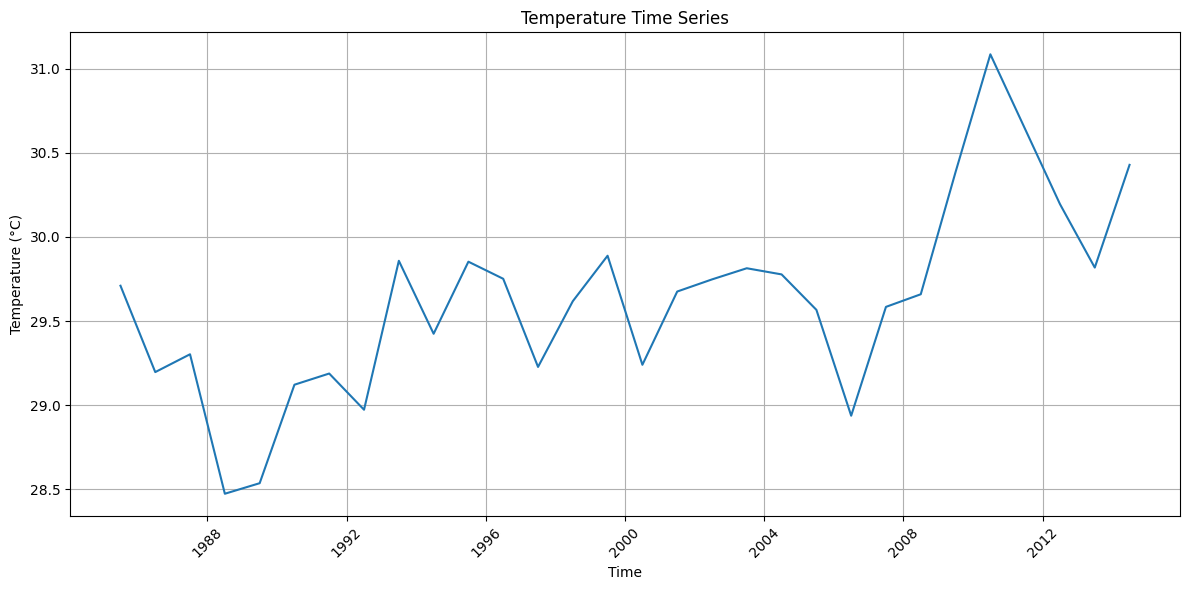

In [164]:
time_0 = ds_MPI_ESM1_2_HR_historical['tas'].sel(longitude = 3, latitude =13, method ='nearest') -273.15
time_0  = time_0.to_dataframe()

# Convert cftime index to pandas datetime
#time_0.index = time_0.index.to_datetimeindex()

plt.figure(figsize=(12, 6))
plt.plot(time_0.index, time_0['tas'])
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Time Series')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [167]:
import xarray as xr
import numpy as np
from scipy.stats import linregress

def compute_trend(ds, time_dim='time', trend_per='decade'):
    """
    Compute linear temperature trend per grid cell.
    
    ds : xarray.DataArray (time, lat, lon)
    time_dim : name of time dimension
    trend_per : 'year' or 'decade'
    """
    # If time is datetime, convert to numeric years
    if np.issubdtype(ds[time_dim].dtype, np.datetime64):
        time_num = (ds[time_dim].values - np.datetime64(ds[time_dim].values[0])) / np.timedelta64(1, 'Y')
    else:
        # Assume time is numeric already (like integers for years)
        time_num = ds[time_dim].values.astype(float)  # e.g., [1985, 1986, ...]
        time_num = time_num - time_num[0]  # make start at 0

    # Function to apply per grid cell
    def linregress_func(y):
        if np.all(np.isnan(y)):
            return np.nan, np.nan
        slope, _, _, _, p = linregress(time_num, y)
        if trend_per == 'decade':
            slope *= 10
        return slope, p

    # Apply along lat/lon
    slope_data, p_data = xr.apply_ufunc(
        linregress_func,
        ds,
        input_core_dims=[[time_dim]],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float]
    )

    trend = xr.DataArray(slope_data, coords=[ds.latitude, ds.longitude], dims=['latitude', 'longitude'])
    p_value = xr.DataArray(p_data, coords=[ds.latitude, ds.longitude], dims=['latitude', 'longitude'])
    
    return trend, p_value


In [168]:
# ACCESS-CM2
access_trend, access_p = compute_trend(ds_ACCESS_C_annual_celsius, trend_per='decade')

# MPI
mpi_trend, mpi_p = compute_trend(ds_MPI_C_annual_celsius, trend_per='decade')


In [209]:
# Check if any trends are non-significant
print("Number of significant pixels:", (access_p <= 0.05).sum().values)
print("Number of non-significant pixels:", (access_p > 0.05).sum().values)
print("P-value range:", float(access_p.min()), "to", float(access_p.max()))

Number of significant pixels: 39800
Number of non-significant pixels: 0
P-value range: 0.007508904768078386 to 0.012029485360206846


In [210]:
def plot_temperature_trend_with_stippling(trend_da, p_da, shapefile_path, 
                                          vmin=-0.5, vmax=0.5,
                                          significance_level=0.05, 
                                          figsize=(14, 10), 
                                          cmap='RdBu_r',
                                          title='Temperature Trend (°C/decade)', 
                                          save_path=None):
    """
    Plot temperature trend with stippling for significant areas.
    """
    import matplotlib.pyplot as plt
    import geopandas as gpd
    import numpy as np
    
    # Load Nigeria shapefile
    shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Plot ALL trends (don't mask)
    im = trend_da.plot(
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={'label': '°C/decade', 'shrink': 0.8, 'pad': 0.02}
    )
    
    # Add stippling for SIGNIFICANT areas (p <= 0.05)
    significant = p_da <= significance_level
    if significant.any():
        # Get coordinates
        lons, lats = np.meshgrid(trend_da.longitude, trend_da.latitude)
        
        # Plot dots where significant
        ax.scatter(
            lons[significant.values], 
            lats[significant.values],
            s=0.3,           # Small dots
            c='black',       # Black color
            alpha=0.4,       # Semi-transparent
            marker='.',
            rasterized=True  # For better PDF export
        )
    
    # Overlay Nigeria boundaries
    shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
    
    # Fix axes
    ax.set_xlim(2, 15)
    ax.set_ylim(3, 15)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=13)
    ax.set_ylabel('Latitude', fontsize=13)
    ax.tick_params(labelsize=11)
    ax.grid(False)
    
    # Add text note about significance
    ax.text(0.02, 0.02, f'Stippling shows p < {significance_level}', 
            transform=ax.transAxes, fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Save BEFORE show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, ax

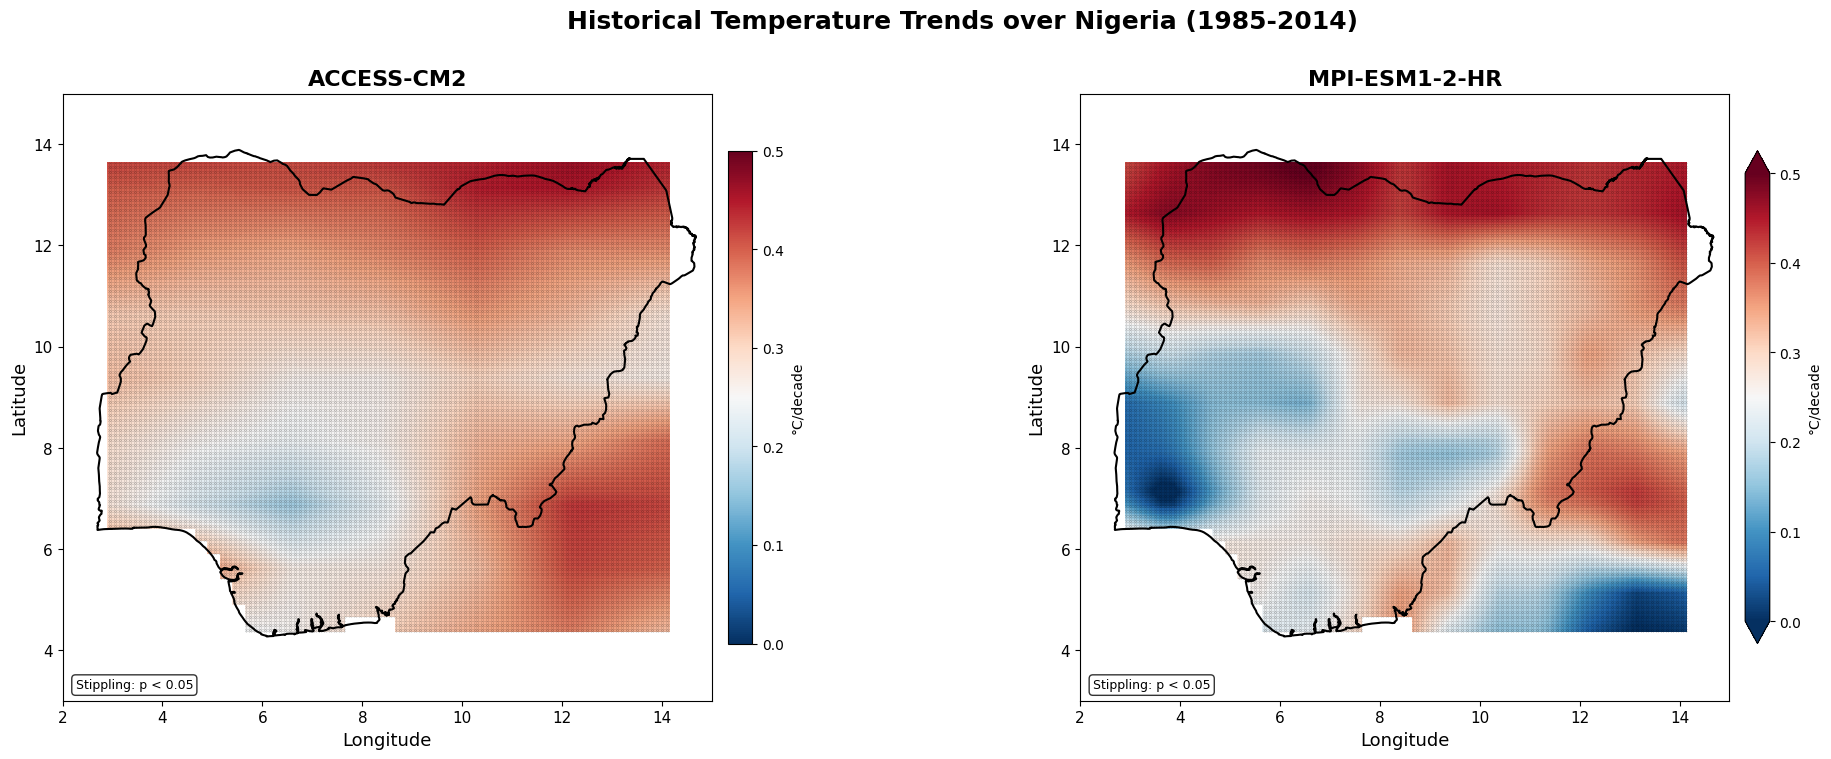

In [215]:
def plot_both_models_trend(access_trend, access_p, mpi_trend, mpi_p, 
                           shapefile_path, vmin=0, vmax=0.5,
                           significance_level=0.05, figsize=(20, 8),
                           cmap='RdBu_r', save_path=None):
    """
    Plot ACCESS and MPI trends side by side for comparison.
    """
    import matplotlib.pyplot as plt
    import geopandas as gpd
    import numpy as np
    
    shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.subplots_adjust(wspace=0.3, left=0.05, right=0.95)
    
    trends = [access_trend, mpi_trend]
    pvals = [access_p, mpi_p]
    titles = ['ACCESS-CM2', 'MPI-ESM1-2-HR']
    
    for i, (ax, trend_da, p_da, model_name) in enumerate(zip(axes, trends, pvals, titles)):
        # Plot trend
        im = trend_da.plot(
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=True,
            cbar_kwargs={'label': '°C/decade', 'shrink': 0.8, 'pad': 0.02}
        )
        
        # Add stippling for significant areas
        significant = p_da <= significance_level
        if significant.any():
            lons, lats = np.meshgrid(trend_da.longitude, trend_da.latitude)
            ax.scatter(
                lons[significant.values], 
                lats[significant.values],
                s=0.3, c='black', alpha=0.4, marker='.', rasterized=True
            )
        
        # Nigeria boundaries
        shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
        
        # Formatting
        ax.set_xlim(2, 15)
        ax.set_ylim(3, 15)
        ax.set_title(model_name, fontsize=16, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=13)
        ax.set_ylabel('Latitude', fontsize=13)
        ax.tick_params(labelsize=11)
        ax.grid(False)
        
        # Significance note
        ax.text(0.02, 0.02, f'Stippling: p < {significance_level}', 
                transform=ax.transAxes, fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle('Historical Temperature Trends over Nigeria (1985-2014)', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, axes

# Plot both models together
fig, axes = plot_both_models_trend(
    access_trend=access_trend,
    access_p=access_p,
    mpi_trend=mpi_trend,
    mpi_p=mpi_p,
    shapefile_path=shapefile_path,
    vmin=0,
    vmax=0.5,
    save_path='Both_models_historical_trends.png'
)

In [216]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy import stats
import pandas as pd

# ==========================================
# 1. CORRELATION ANALYSIS
# ==========================================

def calculate_spatial_correlation(data1, data2):
    """
    Calculate spatial correlation between two models.
    
    Parameters
    ----------
    data1, data2 : xarray.DataArray
        Temperature data from two models (with time dimension)
    
    Returns
    -------
    correlation : xarray.DataArray
        Spatial correlation at each grid point
    """
    # Stack lat/lon into single spatial dimension
    data1_stacked = data1.stack(space=('latitude', 'longitude'))
    data2_stacked = data2.stack(space=('latitude', 'longitude'))
    
    # Calculate correlation along time dimension for each grid point
    def pearson_r(x, y):
        valid = ~(np.isnan(x) | np.isnan(y))
        if valid.sum() < 3:
            return np.nan
        return np.corrcoef(x[valid], y[valid])[0, 1]
    
    corr = xr.apply_ufunc(
        pearson_r,
        data1_stacked,
        data2_stacked,
        input_core_dims=[['time'], ['time']],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float]
    )
    
    # Unstack back to lat/lon
    corr = corr.unstack('space')
    
    return corr


def calculate_temporal_correlation(data1, data2):
    """
    Calculate temporal correlation (time series agreement).
    
    Returns
    -------
    float : Overall correlation coefficient
    """
    # Spatial mean for both models
    ts1 = data1.mean(dim=['latitude', 'longitude'], skipna=True)
    ts2 = data2.mean(dim=['latitude', 'longitude'], skipna=True)
    
    # Correlation
    r, p_value = stats.pearsonr(ts1.values, ts2.values)
    
    return r, p_value


def plot_correlation_map(corr_data, shapefile_path, vmin=0.5, vmax=1.0,
                         title='Spatial Correlation: ACCESS vs MPI',
                         save_path=None):
    """
    Plot spatial correlation map.
    """
    shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Ensure CRS
    if not hasattr(corr_data.rio, 'crs') or corr_data.rio.crs is None:
        corr_data = corr_data.rio.write_crs("EPSG:4326")
    
    # Clip to Nigeria
    corr_clipped = corr_data.rio.clip(shp.geometry, shp.crs, drop=True)
    
    # Plot
    im = corr_clipped.plot(
        ax=ax,
        cmap='RdYlGn',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={'label': 'Correlation (r)', 'shrink': 0.8}
    )
    
    shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
    ax.set_xlim(2, 15)
    ax.set_ylim(3, 15)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=13)
    ax.set_ylabel('Latitude', fontsize=13)
    ax.grid(False)
    
    # Add mean correlation text
    mean_r = float(corr_clipped.mean(skipna=True))
    ax.text(0.02, 0.98, f'Mean r = {mean_r:.3f}', 
            transform=ax.transAxes, fontsize=12, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, ax


# ==========================================
# 2. RMSD ANALYSIS
# ==========================================

def calculate_rmsd(data1, data2):
    """
    Calculate Root Mean Square Difference between two models.
    
    Returns
    -------
    rmsd : xarray.DataArray
        RMSD at each grid point
    """
    # Calculate squared differences
    sq_diff = (data1 - data2) ** 2
    
    # Mean over time, then sqrt
    rmsd = np.sqrt(sq_diff.mean(dim='time', skipna=True))
    
    return rmsd


def plot_rmsd_map(rmsd_data, shapefile_path, vmin=0, vmax=2.0,
                  title='RMSD: ACCESS vs MPI',
                  save_path=None):
    """
    Plot RMSD map.
    """
    shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Ensure CRS
    if not hasattr(rmsd_data.rio, 'crs') or rmsd_data.rio.crs is None:
        rmsd_data = rmsd_data.rio.write_crs("EPSG:4326")
    
    # Clip to Nigeria
    rmsd_clipped = rmsd_data.rio.clip(shp.geometry, shp.crs, drop=True)
    
    # Plot
    im = rmsd_clipped.plot(
        ax=ax,
        cmap='YlOrRd',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={'label': 'RMSD (°C)', 'shrink': 0.8}
    )
    
    shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
    ax.set_xlim(2, 15)
    ax.set_ylim(3, 15)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=13)
    ax.set_ylabel('Latitude', fontsize=13)
    ax.grid(False)
    
    # Add mean RMSD text
    mean_rmsd = float(rmsd_clipped.mean(skipna=True))
    ax.text(0.02, 0.98, f'Mean RMSD = {mean_rmsd:.3f}°C', 
            transform=ax.transAxes, fontsize=12, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, ax


# ==========================================
# 3. TAYLOR DIAGRAM
# ==========================================

def calculate_taylor_stats(reference, model, normalize=False):
    """
    Calculate statistics for Taylor diagram.
    
    Parameters
    ----------
    reference : xarray.DataArray
        Reference dataset (e.g., observations or one model)
    model : xarray.DataArray
        Model data to evaluate
    normalize : bool
        Normalize by reference std
    
    Returns
    -------
    dict with 'std', 'correlation', 'rmsd'
    """
    # Flatten and remove NaNs
    ref_flat = reference.values.flatten()
    mod_flat = model.values.flatten()
    
    valid = ~(np.isnan(ref_flat) | np.isnan(mod_flat))
    ref_flat = ref_flat[valid]
    mod_flat = mod_flat[valid]
    
    # Calculate statistics
    ref_std = np.std(ref_flat, ddof=1)
    mod_std = np.std(mod_flat, ddof=1)
    
    correlation = np.corrcoef(ref_flat, mod_flat)[0, 1]
    
    # Centered RMSD
    ref_centered = ref_flat - np.mean(ref_flat)
    mod_centered = mod_flat - np.mean(mod_flat)
    crmsd = np.sqrt(np.mean((mod_centered - ref_centered) ** 2))
    
    if normalize:
        mod_std = mod_std / ref_std
        crmsd = crmsd / ref_std
        ref_std = 1.0
    
    return {
        'std': mod_std,
        'correlation': correlation,
        'crmsd': crmsd,
        'ref_std': ref_std
    }


def plot_taylor_diagram(stats_dict, normalize=False, figsize=(10, 10), 
                        save_path=None):
    """
    Create Taylor Diagram.
    
    Parameters
    ----------
    stats_dict : dict
        Dictionary with model names as keys and stats as values
        e.g., {'ACCESS': stats1, 'MPI': stats2}
    normalize : bool
        Whether stats are normalized
    """
    fig = plt.figure(figsize=figsize)
    
    # Get reference std (should be same for all or 1.0 if normalized)
    ref_std = list(stats_dict.values())[0]['ref_std']
    
    # Create polar plot
    ax = fig.add_subplot(111, projection='polar')
    
    # Set up axis
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_rlabel_position(135)
    
    # Plot reference point
    ax.plot(0, ref_std, 'ko', markersize=12, label='Reference', zorder=10)
    
    # Radial gridlines for std
    max_std = max([s['std'] for s in stats_dict.values()] + [ref_std]) * 1.2
    ax.set_ylim(0, max_std)
    
    # Correlation gridlines
    corr_ticks = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0]
    corr_angles = [np.arccos(c) for c in corr_ticks]
    
    # Draw correlation lines
    for corr, angle in zip(corr_ticks, corr_angles):
        ax.plot([angle, angle], [0, max_std], 'k:', linewidth=0.5, alpha=0.3)
        
    # Add correlation labels
    for corr, angle in zip(corr_ticks[1:], corr_angles[1:]):
        ax.text(angle, max_std * 1.05, f'{corr:.2f}', 
                ha='center', va='bottom', fontsize=9)
    
    # Plot RMSD circles
    rmsd_levels = np.linspace(0, max_std, 6)[1:]
    for rmsd in rmsd_levels:
        circle_angles = np.linspace(0, np.pi, 100)
        circle_stds = np.sqrt(ref_std**2 + rmsd**2 - 2*ref_std*rmsd*np.cos(circle_angles))
        circle_stds = np.clip(circle_stds, 0, max_std)
        ax.plot(circle_angles, circle_stds, 'k--', linewidth=0.5, alpha=0.3)
        
        # Label RMSD circles
        angle_label = np.pi / 4
        std_label = np.sqrt(ref_std**2 + rmsd**2 - 2*ref_std*rmsd*np.cos(angle_label))
        if std_label < max_std:
            ax.text(angle_label, std_label, f'{rmsd:.1f}', 
                   fontsize=8, color='gray', rotation=-45)
    
    # Plot models
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    markers = ['o', 's', '^', 'D', 'v']
    
    for i, (model_name, stats) in enumerate(stats_dict.items()):
        angle = np.arccos(stats['correlation'])
        ax.plot(angle, stats['std'], 
               marker=markers[i % len(markers)],
               color=colors[i % len(colors)],
               markersize=12,
               label=model_name,
               zorder=10)
    
    # Labels
    ax.set_xlabel('Standard Deviation' + (' (normalized)' if normalize else ' (°C)'),
                 fontsize=12, labelpad=20)
    ax.text(0, max_std * 1.15, 'Correlation', ha='center', fontsize=12, fontweight='bold')
    
    # Legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    
    # Title
    plt.title('Taylor Diagram: Model Comparison', fontsize=16, 
             fontweight='bold', pad=20)
    
    # Add RMSD label
    ax.text(np.pi/4, max_std * 0.7, 'RMSD', fontsize=10, 
           color='gray', rotation=-45, alpha=0.7)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, ax


# ==========================================
# 4. COMPREHENSIVE MODEL RANKING
# ==========================================

def calculate_model_scores(data_dict, reference_data=None, shapefile_path=None):
    """
    Calculate comprehensive model performance scores.
    
    Parameters
    ----------
    data_dict : dict
        {'model_name': data} for each model
    reference_data : xarray.DataArray
        Reference/observed data (optional)
    shapefile_path : str
        Path to shapefile for Nigeria clipping
    
    Returns
    -------
    DataFrame with scores for each model
    """
    results = []
    model_names = list(data_dict.keys())
    
    # Clip all data to Nigeria if shapefile provided
    if shapefile_path:
        shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
        clipped_dict = {}
        for name, data in data_dict.items():
            if not hasattr(data.rio, 'crs') or data.rio.crs is None:
                data = data.rio.write_crs("EPSG:4326")
            clipped_dict[name] = data.rio.clip(shp.geometry, shp.crs, drop=True)
        data_dict = clipped_dict
        
        if reference_data is not None:
            if not hasattr(reference_data.rio, 'crs') or reference_data.rio.crs is None:
                reference_data = reference_data.rio.write_crs("EPSG:4326")
            reference_data = reference_data.rio.clip(shp.geometry, shp.crs, drop=True)
    
    # Inter-model comparison
    for i, name1 in enumerate(model_names):
        data1 = data_dict[name1]
        
        row = {'Model': name1}
        
        # Mean and std
        row['Mean (°C)'] = float(data1.mean(skipna=True))
        row['Std (°C)'] = float(data1.std(skipna=True))
        
        # Compare with reference if available
        if reference_data is not None:
            # Bias
            bias = (data1 - reference_data).mean(skipna=True)
            row['Bias vs Ref (°C)'] = float(bias)
            
            # RMSD vs reference
            rmsd = np.sqrt(((data1 - reference_data) ** 2).mean(skipna=True))
            row['RMSD vs Ref (°C)'] = float(rmsd)
            
            # Correlation vs reference
            taylor = calculate_taylor_stats(reference_data, data1)
            row['Corr vs Ref'] = taylor['correlation']
        
        # Compare with other models
        for j, name2 in enumerate(model_names):
            if i < j:  # Only compare each pair once
                data2 = data_dict[name2]
                
                # Inter-model RMSD
                rmsd = calculate_rmsd(data1, data2)
                row[f'RMSD vs {name2} (°C)'] = float(rmsd.mean(skipna=True))
                
                # Inter-model correlation
                corr = calculate_spatial_correlation(data1, data2)
                row[f'Corr vs {name2}'] = float(corr.mean(skipna=True))
        
        results.append(row)
    
    df = pd.DataFrame(results)
    return df


def plot_model_comparison_summary(stats_df, save_path=None):
    """
    Create summary visualization of model comparison.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Comparison Summary', fontsize=18, fontweight='bold')
    
    models = stats_df['Model'].values
    
    # 1. Mean and Std
    ax = axes[0, 0]
    x = np.arange(len(models))
    width = 0.35
    ax.bar(x - width/2, stats_df['Mean (°C)'], width, label='Mean', alpha=0.8)
    ax.bar(x + width/2, stats_df['Std (°C)'], width, label='Std', alpha=0.8)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.set_title('Mean and Standard Deviation', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 2. RMSD comparison
    ax = axes[0, 1]
    rmsd_cols = [col for col in stats_df.columns if 'RMSD vs' in col and 'Ref' not in col]
    if rmsd_cols:
        rmsd_values = stats_df[rmsd_cols].values[0]
        ax.bar(range(len(rmsd_cols)), rmsd_values, color='coral', alpha=0.8)
        ax.set_xlabel('Comparison', fontsize=12)
        ax.set_ylabel('RMSD (°C)', fontsize=12)
        ax.set_title('Inter-Model RMSD', fontsize=14, fontweight='bold')
        ax.set_xticks(range(len(rmsd_cols)))
        ax.set_xticklabels([col.replace('RMSD vs ', '').replace(' (°C)', '') 
                           for col in rmsd_cols], rotation=45)
        ax.grid(axis='y', alpha=0.3)
    
    # 3. Correlation comparison
    ax = axes[1, 0]
    corr_cols = [col for col in stats_df.columns if 'Corr vs' in col and 'Ref' not in col]
    if corr_cols:
        corr_values = stats_df[corr_cols].values[0]
        ax.bar(range(len(corr_cols)), corr_values, color='skyblue', alpha=0.8)
        ax.set_xlabel('Comparison', fontsize=12)
        ax.set_ylabel('Correlation', fontsize=12)
        ax.set_title('Inter-Model Correlation', fontsize=14, fontweight='bold')
        ax.set_xticks(range(len(corr_cols)))
        ax.set_xticklabels([col.replace('Corr vs ', '') 
                           for col in corr_cols], rotation=45)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)
    
    # 4. Summary statistics table
    ax = axes[1, 1]
    ax.axis('tight')
    ax.axis('off')
    
    # Select key columns for table
    table_cols = ['Model', 'Mean (°C)', 'Std (°C)']
    if 'RMSD vs Ref (°C)' in stats_df.columns:
        table_cols.extend(['Bias vs Ref (°C)', 'RMSD vs Ref (°C)', 'Corr vs Ref'])
    
    table_data = stats_df[table_cols].round(3)
    
    table = ax.table(cellText=table_data.values,
                    colLabels=table_data.columns,
                    cellLoc='center',
                    loc='center',
                    bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style header
    for i in range(len(table_data.columns)):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, axes


# ==========================================
# EXAMPLE USAGE
# ==========================================
"""
# Assuming you have:
# - ds_ACCESS: ACCESS model data
# - ds_MPI: MPI model data
# - shapefile_path: path to Nigeria shapefile

# 1. Spatial Correlation
corr_map = calculate_spatial_correlation(ds_ACCESS, ds_MPI)
plot_correlation_map(corr_map, shapefile_path, 
                     save_path='spatial_correlation_map.png')

# 2. Temporal Correlation
r, p = calculate_temporal_correlation(ds_ACCESS, ds_MPI)
print(f"Temporal correlation: r = {r:.3f}, p = {p:.4f}")

# 3. RMSD
rmsd_map = calculate_rmsd(ds_ACCESS, ds_MPI)
plot_rmsd_map(rmsd_map, shapefile_path, 
              save_path='rmsd_map.png')

# 4. Taylor Diagram
stats_access = calculate_taylor_stats(ds_MPI, ds_ACCESS)  # MPI as reference
stats_mpi = calculate_taylor_stats(ds_ACCESS, ds_MPI)     # ACCESS as reference

taylor_stats = {
    'ACCESS (vs MPI ref)': stats_access,
    'MPI (vs ACCESS ref)': stats_mpi
}
plot_taylor_diagram(taylor_stats, save_path='taylor_diagram.png')

# 5. Comprehensive Scoring
data_dict = {'ACCESS': ds_ACCESS, 'MPI': ds_MPI}
scores = calculate_model_scores(data_dict, shapefile_path=shapefile_path)
print(scores)

plot_model_comparison_summary(scores, save_path='model_comparison_summary.png')
"""

'\n# Assuming you have:\n# - ds_ACCESS: ACCESS model data\n# - ds_MPI: MPI model data\n# - shapefile_path: path to Nigeria shapefile\n\n# 1. Spatial Correlation\ncorr_map = calculate_spatial_correlation(ds_ACCESS, ds_MPI)\nplot_correlation_map(corr_map, shapefile_path, \n                     save_path=\'spatial_correlation_map.png\')\n\n# 2. Temporal Correlation\nr, p = calculate_temporal_correlation(ds_ACCESS, ds_MPI)\nprint(f"Temporal correlation: r = {r:.3f}, p = {p:.4f}")\n\n# 3. RMSD\nrmsd_map = calculate_rmsd(ds_ACCESS, ds_MPI)\nplot_rmsd_map(rmsd_map, shapefile_path, \n              save_path=\'rmsd_map.png\')\n\n# 4. Taylor Diagram\nstats_access = calculate_taylor_stats(ds_MPI, ds_ACCESS)  # MPI as reference\nstats_mpi = calculate_taylor_stats(ds_ACCESS, ds_MPI)     # ACCESS as reference\n\ntaylor_stats = {\n    \'ACCESS (vs MPI ref)\': stats_access,\n    \'MPI (vs ACCESS ref)\': stats_mpi\n}\nplot_taylor_diagram(taylor_stats, save_path=\'taylor_diagram.png\')\n\n# 5. Comprehen

=== SSP585 Near Future Comparison ===


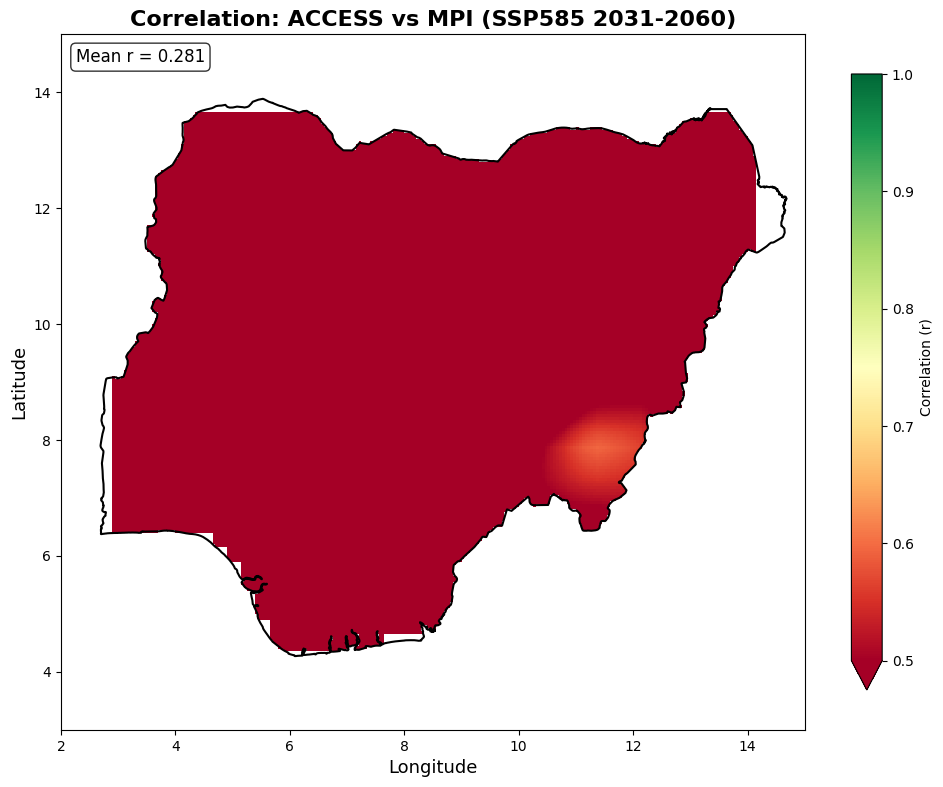

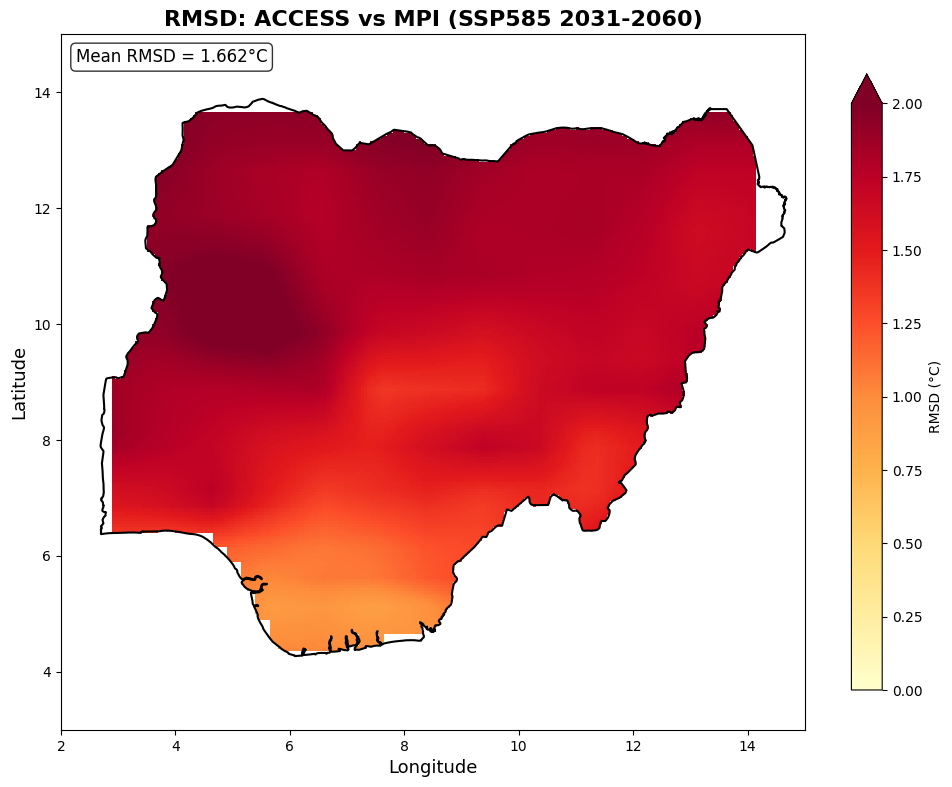

    Model  Mean (°C)  Std (°C)  RMSD vs MPI (°C)  Corr vs MPI
0  ACCESS   2.167212  0.844212          1.661983     0.280924
1     MPI   0.714446  0.528395               NaN          NaN


In [218]:
# For SSP585 Near Future example
print("=== SSP585 Near Future Comparison ===")

# Correlation
corr_ssp585_near = calculate_spatial_correlation(
    ssp585_near_future_access, 
    ssp585_near_future_MPI
)
plot_correlation_map(
    corr_ssp585_near,
    shapefile_path,
    title='Correlation: ACCESS vs MPI (SSP585 2031-2060)',
    save_path='correlation_ssp585_near.png'
)

# RMSD
rmsd_ssp585_near = calculate_rmsd(
    ssp585_near_future_access,
    ssp585_near_future_MPI
)
plot_rmsd_map(
    rmsd_ssp585_near,
    shapefile_path,
    title='RMSD: ACCESS vs MPI (SSP585 2031-2060)',
    save_path='rmsd_ssp585_near.png'
)

# Model scores
data_dict_ssp585 = {
    'ACCESS': ssp585_near_future_access,
    'MPI': ssp585_near_future_MPI
}
scores_ssp585 = calculate_model_scores(data_dict_ssp585, shapefile_path=shapefile_path)
print(scores_ssp585)

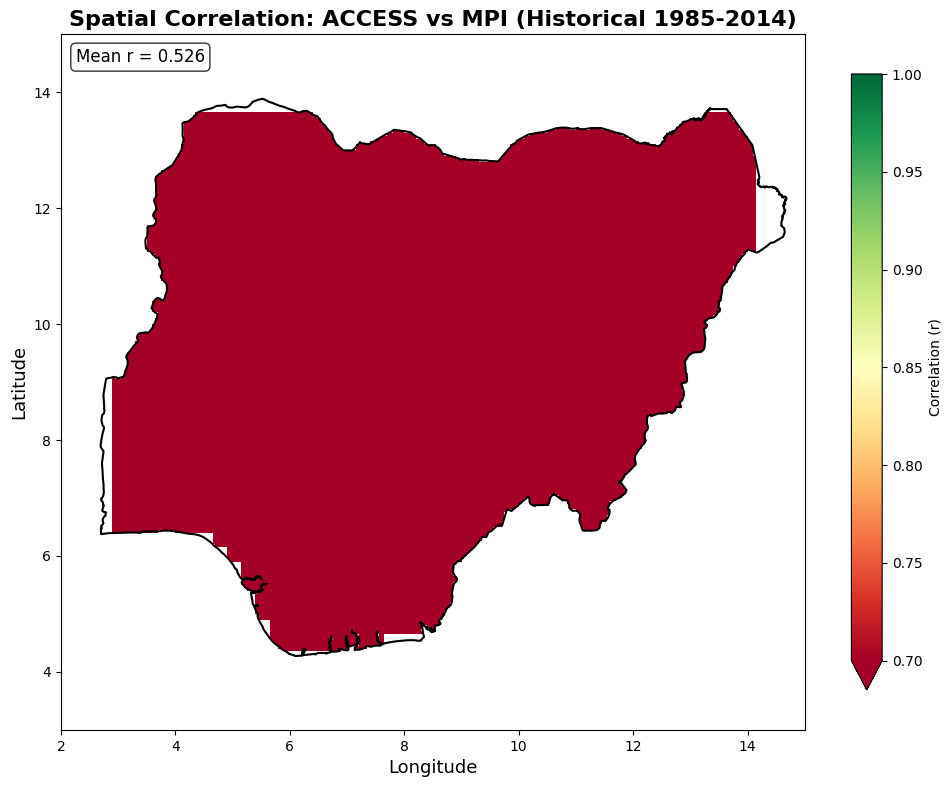

Temporal correlation: r = 0.618, p-value = 0.0003


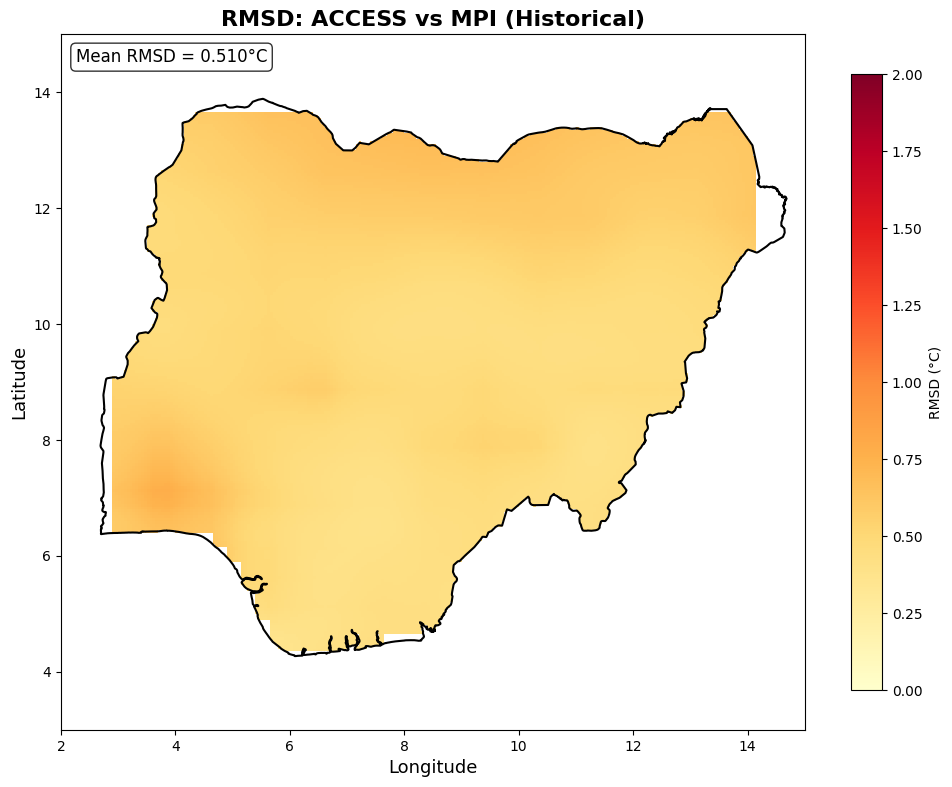

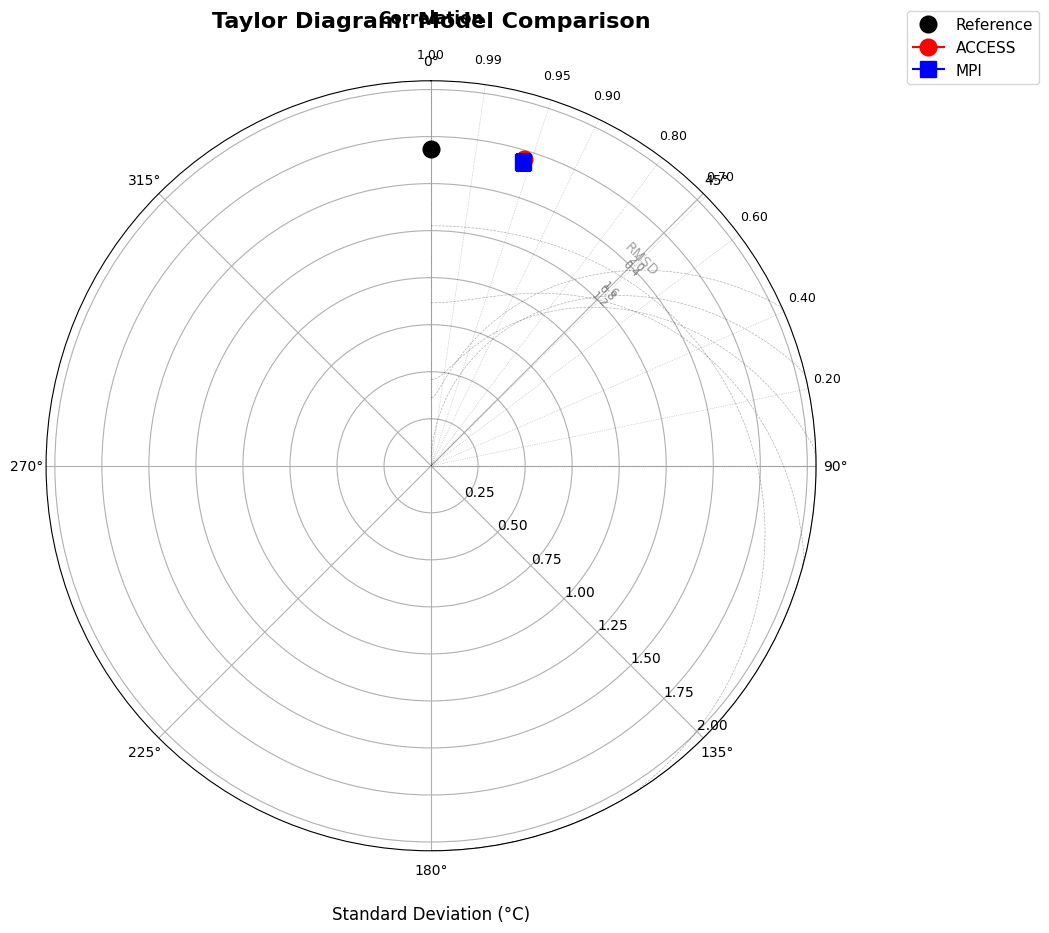


=== Model Comparison Scores ===
 Model  Mean (°C)  Std (°C)  RMSD vs MPI (°C)  Corr vs MPI
ACCESS  27.562157  1.244737          0.510045     0.526044
   MPI  27.429665  1.222403               NaN          NaN


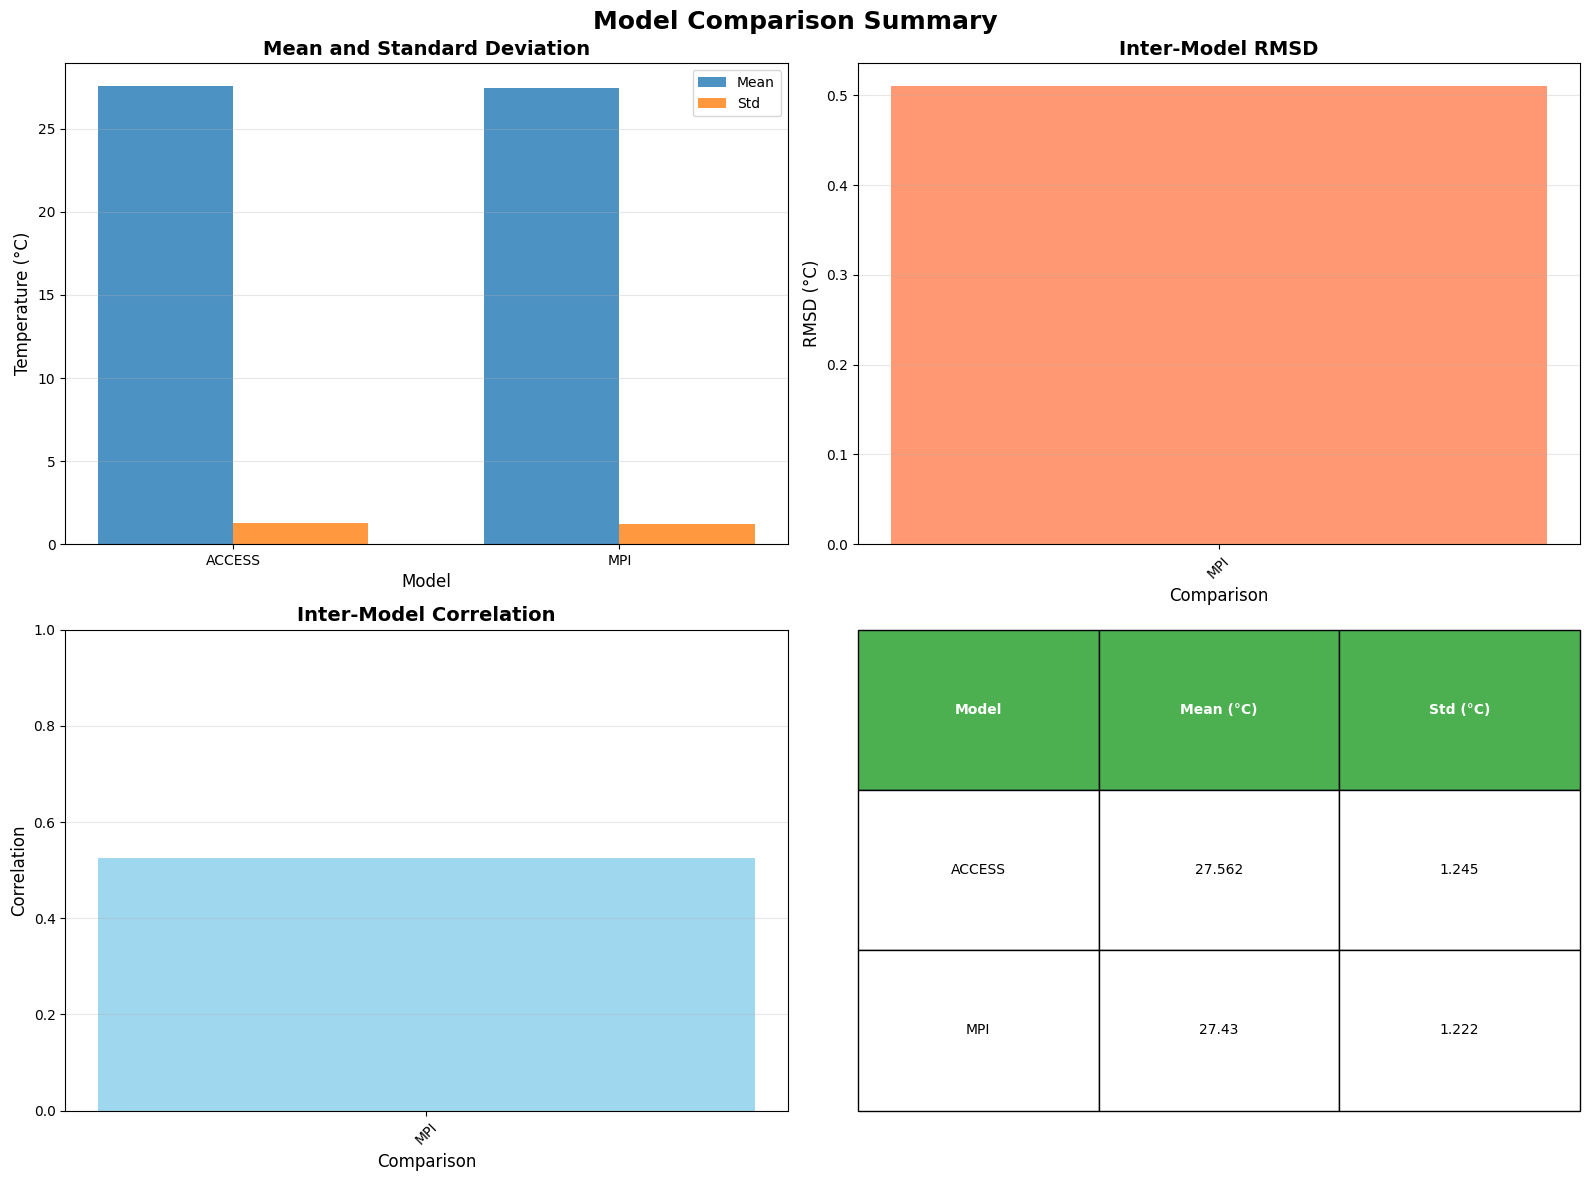

(<Figure size 1600x1200 with 4 Axes>,
 array([[<AxesSubplot: title={'center': 'Mean and Standard Deviation'}, xlabel='Model', ylabel='Temperature (°C)'>,
         <AxesSubplot: title={'center': 'Inter-Model RMSD'}, xlabel='Comparison', ylabel='RMSD (°C)'>],
        [<AxesSubplot: title={'center': 'Inter-Model Correlation'}, xlabel='Comparison', ylabel='Correlation'>,
         <AxesSubplot: >]], dtype=object))

In [219]:
# 1. Spatial Correlation Map
corr_map = calculate_spatial_correlation(ds_ACCESS_C_annual_celsius, ds_MPI_C_annual_celsius)
plot_correlation_map(
    corr_map, 
    shapefile_path,
    vmin=0.7,
    vmax=1.0,
    title='Spatial Correlation: ACCESS vs MPI (Historical 1985-2014)',
    save_path='correlation_map_historical.png'
)

# 2. Temporal Correlation
r, p = calculate_temporal_correlation(ds_ACCESS_C_annual_celsius, ds_MPI_C_annual_celsius)
print(f"Temporal correlation: r = {r:.3f}, p-value = {p:.4f}")

# 3. RMSD Map
rmsd_map = calculate_rmsd(ds_ACCESS_C_annual_celsius, ds_MPI_C_annual_celsius)
plot_rmsd_map(
    rmsd_map,
    shapefile_path,
    vmin=0,
    vmax=2.0,
    title='RMSD: ACCESS vs MPI (Historical)',
    save_path='rmsd_map_historical.png'
)

# 4. Taylor Diagram (use one model as reference)
stats_access = calculate_taylor_stats(ds_MPI_C_annual_celsius, ds_ACCESS_C_annual_celsius)
stats_mpi = calculate_taylor_stats(ds_ACCESS_C_annual_celsius, ds_MPI_C_annual_celsius)

taylor_stats = {
    'ACCESS': stats_access,
    'MPI': stats_mpi
}
plot_taylor_diagram(taylor_stats, save_path='taylor_diagram_historical.png')

# 5. Comprehensive Model Scores
data_dict = {
    'ACCESS': ds_ACCESS_C_annual_celsius,
    'MPI': ds_MPI_C_annual_celsius
}
scores = calculate_model_scores(data_dict, shapefile_path=shapefile_path)
print("\n=== Model Comparison Scores ===")
print(scores.to_string(index=False))

plot_model_comparison_summary(scores, save_path='model_comparison_summary.png')

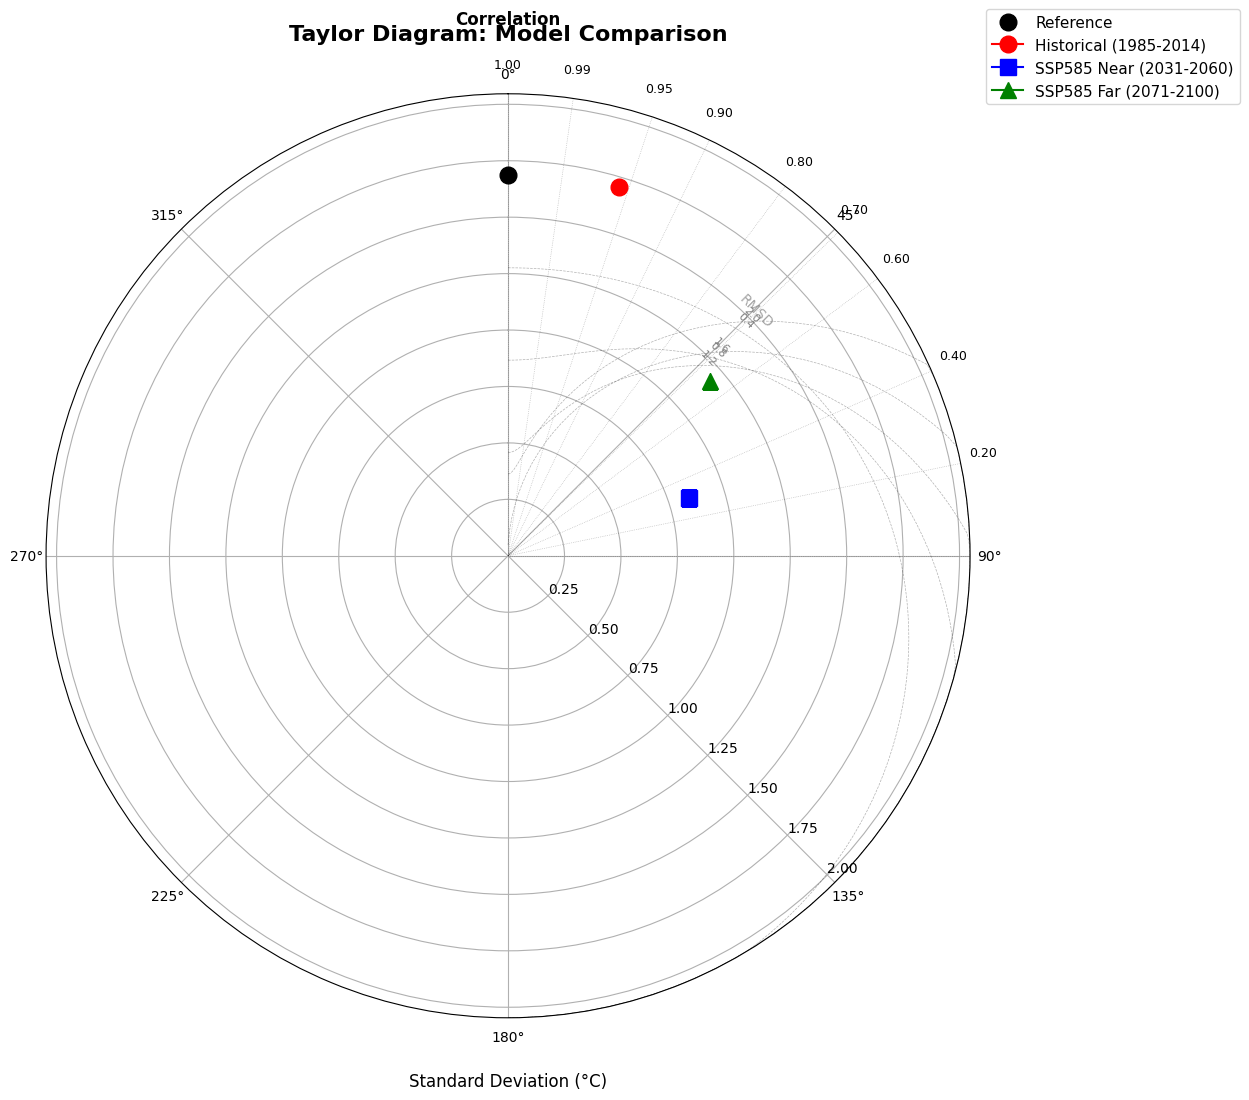


=== Taylor Statistics Summary ===
Scenario                       Correlation  Std Ratio    CRMSD (°C)  
----------------------------------------------------------------------
Historical (1985-2014)         0.957        1.012        0.495       
SSP585 Near (2031-2060)        0.307        1.605        0.844       
SSP585 Far (2071-2100)         0.655        1.323        0.901       


In [222]:
# ==========================================
# SINGLE TAYLOR DIAGRAM WITH ALL SCENARIOS
# ==========================================

# Calculate stats for all scenarios (using MPI as reference)
all_stats = {}

# Historical
stats_hist = calculate_taylor_stats(
    reference=ds_MPI_C_annual_celsius,
    model=ds_ACCESS_C_annual_celsius,
    normalize=False
)
all_stats['Historical (1985-2014)'] = stats_hist

# SSP585 scenarios (you can add more)
stats_ssp585_near = calculate_taylor_stats(
    reference=ssp585_near_future_MPI,
    model=ssp585_near_future_access,
    normalize=False
)
all_stats['SSP585 Near (2031-2060)'] = stats_ssp585_near

stats_ssp585_far = calculate_taylor_stats(
    reference=ssp585_far_future_MPI,
    model=ssp585_far_future_access,
    normalize=False
)
all_stats['SSP585 Far (2071-2100)'] = stats_ssp585_far

# Plot all on one Taylor diagram
plot_taylor_diagram(
    all_stats,
    normalize=False,
    figsize=(12, 12),
    save_path='taylor_diagram_comprehensive.png'
)

# Print summary table
print("\n=== Taylor Statistics Summary ===")
print(f"{'Scenario':<30} {'Correlation':<12} {'Std Ratio':<12} {'CRMSD (°C)':<12}")
print("-" * 70)
for name, stats in all_stats.items():
    std_ratio = stats['std'] / stats['ref_std']
    print(f"{name:<30} {stats['correlation']:<12.3f} {std_ratio:<12.3f} {stats['crmsd']:<12.3f}")

In [229]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import box

# ==========================================
# 1. DEFINE NIGERIA'S CLIMATE ZONES
# ==========================================

def create_climate_zones():
    """
    Define Nigeria's major climate zones based on latitude.
    
    Climate Zones (approximate):
    - Sahel Zone: lat > 12°N (Far North - driest)
    - Sudan Savanna: 10°N - 12°N (North)
    - Guinea Savanna: 8°N - 10°N (Middle Belt)
    - Tropical Rainforest: lat < 8°N (South - wettest)
    
    Returns
    -------
    dict : Zone definitions with lat/lon boundaries
    """
    zones = {
        'Sahel': {
            'name': 'Sahel Zone',
            'lat_min': 12.0,
            'lat_max': 14.0,
            'lon_min': 2.5,
            'lon_max': 15.0,
            'description': 'Far North (Driest)'
        },
        'Sudan': {
            'name': 'Sudan Savanna',
            'lat_min': 10.0,
            'lat_max': 12.0,
            'lon_min': 2.5,
            'lon_max': 15.0,
            'description': 'North'
        },
        'Guinea': {
            'name': 'Guinea Savanna',
            'lat_min': 8.0,
            'lat_max': 10.0,
            'lon_min': 2.5,
            'lon_max': 15.0,
            'description': 'Middle Belt'
        },
        'Tropical': {
            'name': 'Tropical Rainforest',
            'lat_min': 4.0,
            'lat_max': 8.0,
            'lon_min': 2.5,
            'lon_max': 15.0,
            'description': 'South (Wettest)'
        }
    }
    
    return zones


def extract_regional_data(data, zone_definition):
    """
    Extract data for a specific climate zone.
    
    Parameters
    ----------
    data : xarray.DataArray
        Temperature data
    zone_definition : dict
        Zone boundaries from create_climate_zones()
    
    Returns
    -------
    xarray.DataArray : Data clipped to zone
    """
    lat_mask = (data.latitude >= zone_definition['lat_min']) & \
               (data.latitude <= zone_definition['lat_max'])
    lon_mask = (data.longitude >= zone_definition['lon_min']) & \
               (data.longitude <= zone_definition['lon_max'])
    
    regional_data = data.where(lat_mask & lon_mask, drop=True)
    
    return regional_data


def calculate_zonal_means(data, zones=None):
    """
    Calculate area-averaged temperature for each climate zone.
    
    Parameters
    ----------
    data : xarray.DataArray
        Temperature data with time dimension
    zones : dict
        Climate zone definitions (if None, uses default)
    
    Returns
    -------
    dict : {zone_name: mean_temperature_timeseries}
    """
    if zones is None:
        zones = create_climate_zones()
    
    zonal_means = {}
    
    for zone_key, zone_def in zones.items():
        # Extract regional data
        regional_data = extract_regional_data(data, zone_def)
        
        # Calculate spatial mean (average over lat/lon)
        if len(regional_data) > 0:
            mean_temp = regional_data.mean(dim=['latitude', 'longitude'], skipna=True)
            zonal_means[zone_key] = mean_temp
        else:
            zonal_means[zone_key] = None
    
    return zonal_means


# ==========================================
# 2. REGIONAL TIME SERIES PLOTS
# ==========================================

def plot_regional_timeseries(data_dict, zones=None, figsize=(16, 10),
                             title='Regional Temperature Time Series',
                             save_path=None):
    """
    Plot temperature time series for each climate zone.
    
    Parameters
    ----------
    data_dict : dict
        {'Label': data} for different scenarios/models
        e.g., {'Historical': hist_data, 'SSP585': future_data}
    zones : dict
        Climate zone definitions
    """
    if zones is None:
        zones = create_climate_zones()
    
    zone_keys = list(zones.keys())
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    axes = axes.flatten()
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(data_dict)))
    
    for i, zone_key in enumerate(zone_keys):
        ax = axes[i]
        zone_def = zones[zone_key]
        
        for j, (label, data) in enumerate(data_dict.items()):
            # Calculate zonal mean
            zonal_means = calculate_zonal_means(data, zones)
            
            if zonal_means[zone_key] is not None:
                ts = zonal_means[zone_key]
                
                # Get years
                if 'time' in ts.dims:
                    years = ts.time.values if hasattr(ts.time, 'values') else ts.time
                    temps = ts.values
                else:
                    continue
                
                ax.plot(years, temps, marker='o', markersize=4,
                       label=label, color=colors[j], linewidth=2, alpha=0.8)
        
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
        ax.set_title(f"{zone_def['name']}\n{zone_def['description']}", 
                    fontsize=13, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=10)
    
    plt.suptitle(title, fontsize=17, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, axes


# ==========================================
# 3. REGIONAL COMPARISON BAR CHARTS
# ==========================================

def plot_regional_comparison(data_dict, zones=None, figsize=(14, 8),
                             title='Regional Temperature Comparison',
                             save_path=None):
    """
    Bar chart comparing temperatures across regions for different scenarios.
    
    Parameters
    ----------
    data_dict : dict
        {'Scenario': data} for each scenario
    """
    if zones is None:
        zones = create_climate_zones()
    
    # Calculate means for each zone and scenario
    results = {}
    for label, data in data_dict.items():
        zonal_means = calculate_zonal_means(data, zones)
        results[label] = {}
        for zone_key, ts in zonal_means.items():
            if ts is not None:
                # Overall mean (across time)
                results[label][zone_key] = float(ts.mean(skipna=True))
    
    # Prepare for plotting
    zone_keys = list(zones.keys())
    zone_names = [zones[k]['name'] for k in zone_keys]
    labels = list(results.keys())
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    x = np.arange(len(zone_keys))
    width = 0.8 / len(labels)
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))
    
    for i, label in enumerate(labels):
        temps = [results[label].get(zk, np.nan) for zk in zone_keys]
        offset = (i - len(labels)/2 + 0.5) * width
        bars = ax.bar(x + offset, temps, width, label=label,
                     color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}',
                       ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Climate Zone', fontsize=13, fontweight='bold')
    ax.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{zones[k]['name']}\n({zones[k]['description']})" 
                        for k in zone_keys], fontsize=10)
    ax.legend(fontsize=11, loc='best')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, ax, results


def plot_regional_anomalies(baseline_data, future_data_dict, zones=None,
                            figsize=(14, 8),
                            title='Regional Temperature Anomalies',
                            save_path=None):
    """
    Bar chart showing regional anomalies for different scenarios.
    
    Parameters
    ----------
    baseline_data : xarray.DataArray
        Historical baseline
    future_data_dict : dict
        {'Scenario': data} for future scenarios
    """
    if zones is None:
        zones = create_climate_zones()
    
    # Calculate baseline means
    baseline_means = calculate_zonal_means(baseline_data, zones)
    baseline_vals = {}
    for zone_key, ts in baseline_means.items():
        if ts is not None:
            baseline_vals[zone_key] = float(ts.mean(skipna=True))
    
    # Calculate anomalies
    anomalies = {}
    for label, future_data in future_data_dict.items():
        future_means = calculate_zonal_means(future_data, zones)
        anomalies[label] = {}
        for zone_key, ts in future_means.items():
            if ts is not None and zone_key in baseline_vals:
                future_val = float(ts.mean(skipna=True))
                anomalies[label][zone_key] = future_val - baseline_vals[zone_key]
    
    # Plot
    zone_keys = list(zones.keys())
    labels = list(anomalies.keys())
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    x = np.arange(len(zone_keys))
    width = 0.8 / len(labels)
    
    colors = plt.cm.RdYlBu_r(np.linspace(0.3, 0.9, len(labels)))
    
    for i, label in enumerate(labels):
        anoms = [anomalies[label].get(zk, np.nan) for zk in zone_keys]
        offset = (i - len(labels)/2 + 0.5) * width
        bars = ax.bar(x + offset, anoms, width, label=label,
                     color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'+{height:.2f}',
                       ha='center', va='bottom' if height > 0 else 'top',
                       fontsize=9)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Climate Zone', fontsize=13, fontweight='bold')
    ax.set_ylabel('Temperature Anomaly (°C)', fontsize=13, fontweight='bold')
    ax.set_title(f'{title}\n(Relative to Historical Period)', 
                fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{zones[k]['name']}\n({zones[k]['description']})" 
                        for k in zone_keys], fontsize=10)
    ax.legend(fontsize=11, loc='best')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, ax, anomalies


# ==========================================
# 4. SPATIAL MAPS WITH ZONE BOUNDARIES
# ==========================================

def plot_temperature_with_zones(data, shapefile_path, zones=None,
                                vmin=20, vmax=35, figsize=(14, 10),
                                cmap='RdYlBu_r', title='Temperature with Climate Zones',
                                save_path=None):
    """
    Plot temperature map with climate zone boundaries overlaid.
    
    Parameters
    ----------
    data : xarray.DataArray
        Temperature data (single time step or time-averaged)
    shapefile_path : str
        Path to Nigeria shapefile
    zones : dict
        Climate zone definitions
    """
    if zones is None:
        zones = create_climate_zones()
    
    shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    
    # If data has time dimension, take mean
    if 'time' in data.dims:
        data = data.mean(dim='time', skipna=True)
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Ensure CRS
    if not hasattr(data.rio, 'crs') or data.rio.crs is None:
        data = data.rio.write_crs("EPSG:4326")
    
    # Clip to Nigeria
    data_clipped = data.rio.clip(shp.geometry, shp.crs, drop=True)
    
    # Plot temperature
    im = data_clipped.plot(
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={'label': '°C', 'shrink': 0.8, 'pad': 0.02}
    )
    
    # Nigeria boundary
    shp.boundary.plot(ax=ax, edgecolor='black', linewidth=2)
    
    # Draw zone boundaries
    colors_zones = ['blue', 'green', 'orange', 'red']
    for i, (zone_key, zone_def) in enumerate(zones.items()):
        # Draw horizontal lines for latitude boundaries
        lat_min = zone_def['lat_min']
        lat_max = zone_def['lat_max']
        lon_min = zone_def['lon_min']
        lon_max = zone_def['lon_max']
        
        # Draw rectangle for zone
        ax.plot([lon_min, lon_max], [lat_min, lat_min], 
               color=colors_zones[i], linestyle='--', linewidth=2, alpha=0.7)
        ax.plot([lon_min, lon_max], [lat_max, lat_max], 
               color=colors_zones[i], linestyle='--', linewidth=2, alpha=0.7)
        
        # Add zone label
        mid_lon = (lon_min + lon_max) / 2
        mid_lat = (lat_min + lat_max) / 2
        ax.text(mid_lon, mid_lat, zone_def['name'],
               fontsize=11, fontweight='bold', color=colors_zones[i],
               ha='center', va='center',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor=colors_zones[i]))
    
    ax.set_xlim(2, 15)
    ax.set_ylim(3, 15)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=13)
    ax.set_ylabel('Latitude', fontsize=13)
    ax.tick_params(labelsize=11)
    ax.grid(False)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig, ax


# ==========================================
# 5. SUMMARY STATISTICS TABLE
# ==========================================

def create_regional_summary_table(data_dict, zones=None):
    """
    Create comprehensive summary table of regional statistics.
    
    Parameters
    ----------
    data_dict : dict
        {'Scenario': data}
    
    Returns
    -------
    pandas.DataFrame : Summary statistics
    """
    if zones is None:
        zones = create_climate_zones()
    
    results = []
    
    for scenario, data in data_dict.items():
        zonal_means = calculate_zonal_means(data, zones)
        
        for zone_key, ts in zonal_means.items():
            if ts is not None:
                row = {
                    'Scenario': scenario,
                    'Zone': zones[zone_key]['name'],
                    'Mean (°C)': float(ts.mean(skipna=True)),
                    'Std (°C)': float(ts.std(skipna=True)),
                    'Min (°C)': float(ts.min(skipna=True)),
                    'Max (°C)': float(ts.max(skipna=True))
                }
                results.append(row)
    
    df = pd.DataFrame(results)
    return df


# ==========================================
# EXAMPLE USAGE
# ==========================================
"""
shapefile_path = "path/to/nigeria.shp"

# 1. Time series for each region
data_dict = {
    'Historical': ds_ACCESS_C_annual_celsius,
    'SSP585 Near': ssp585_near_future_access,
    'SSP585 Far': ssp585_far_future_access
}

plot_regional_timeseries(
    data_dict,
    title='ACCESS Regional Temperature Projections',
    save_path='regional_timeseries.png'
)

# 2. Regional comparison bars
plot_regional_comparison(
    data_dict,
    title='ACCESS Regional Temperature Comparison',
    save_path='regional_comparison.png'
)

# 3. Regional anomalies
future_dict = {
    'SSP585 Near (2031-2060)': ssp585_near_future_access,
    'SSP585 Far (2071-2100)': ssp585_far_future_access
}

plot_regional_anomalies(
    baseline_data=ds_ACCESS_C_annual_celsius,
    future_data_dict=future_dict,
    title='ACCESS Regional Temperature Anomalies',
    save_path='regional_anomalies.png'
)

# 4. Map with zone boundaries
plot_temperature_with_zones(
    data=ds_ACCESS_C_annual_celsius,
    shapefile_path=shapefile_path,
    title='Historical Temperature with Climate Zones',
    save_path='temperature_zones_map.png'
)

# 5. Summary table
summary_df = create_regional_summary_table(data_dict)
print(summary_df)
summary_df.to_csv('regional_summary.csv', index=False)
"""

'\nshapefile_path = "path/to/nigeria.shp"\n\n# 1. Time series for each region\ndata_dict = {\n    \'Historical\': ds_ACCESS_C_annual_celsius,\n    \'SSP585 Near\': ssp585_near_future_access,\n    \'SSP585 Far\': ssp585_far_future_access\n}\n\nplot_regional_timeseries(\n    data_dict,\n    title=\'ACCESS Regional Temperature Projections\',\n    save_path=\'regional_timeseries.png\'\n)\n\n# 2. Regional comparison bars\nplot_regional_comparison(\n    data_dict,\n    title=\'ACCESS Regional Temperature Comparison\',\n    save_path=\'regional_comparison.png\'\n)\n\n# 3. Regional anomalies\nfuture_dict = {\n    \'SSP585 Near (2031-2060)\': ssp585_near_future_access,\n    \'SSP585 Far (2071-2100)\': ssp585_far_future_access\n}\n\nplot_regional_anomalies(\n    baseline_data=ds_ACCESS_C_annual_celsius,\n    future_data_dict=future_dict,\n    title=\'ACCESS Regional Temperature Anomalies\',\n    save_path=\'regional_anomalies.png\'\n)\n\n# 4. Map with zone boundaries\nplot_temperature_with_zones

Creating regional time series...


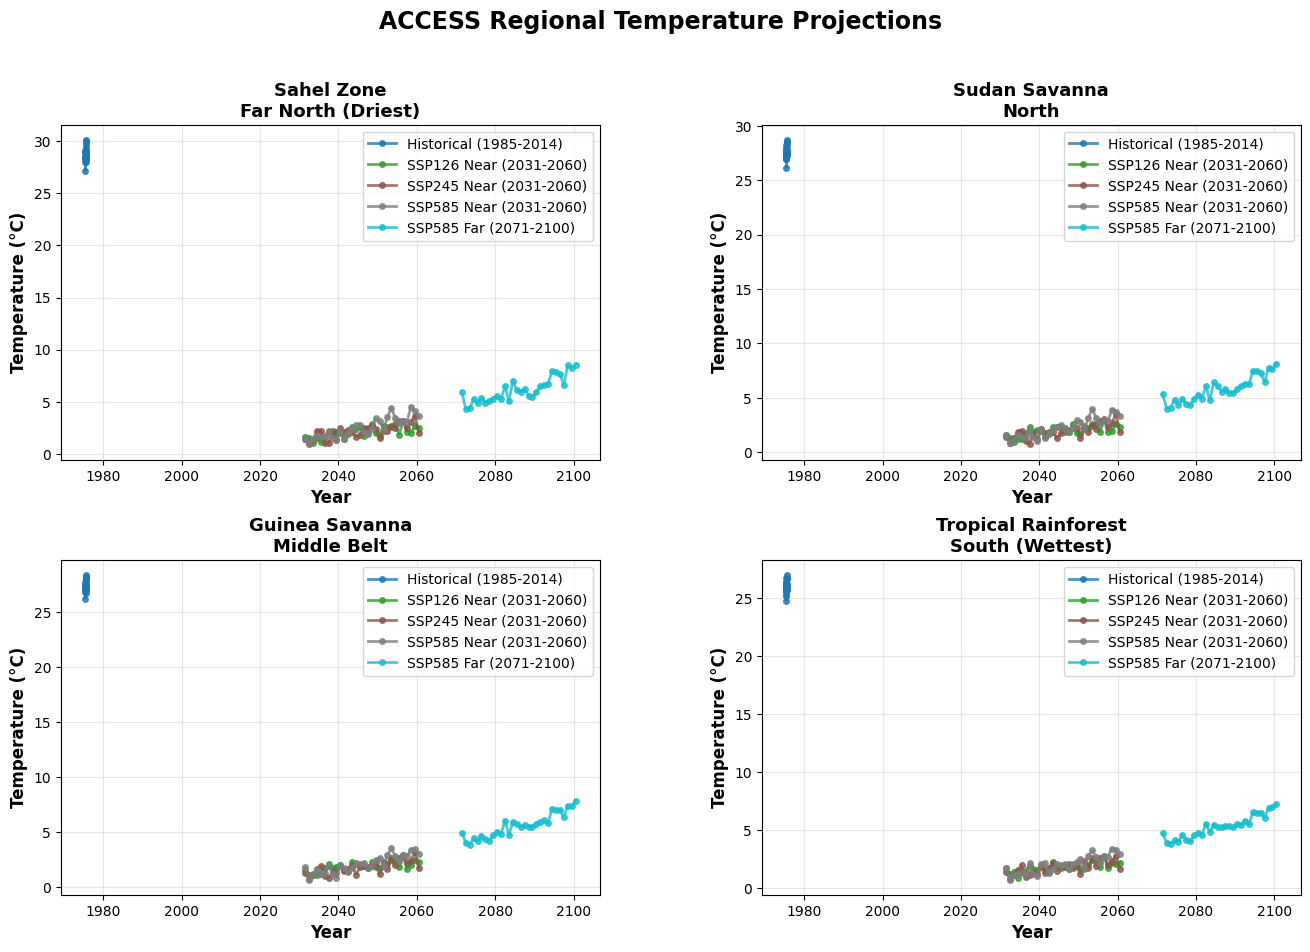

Creating regional comparison...


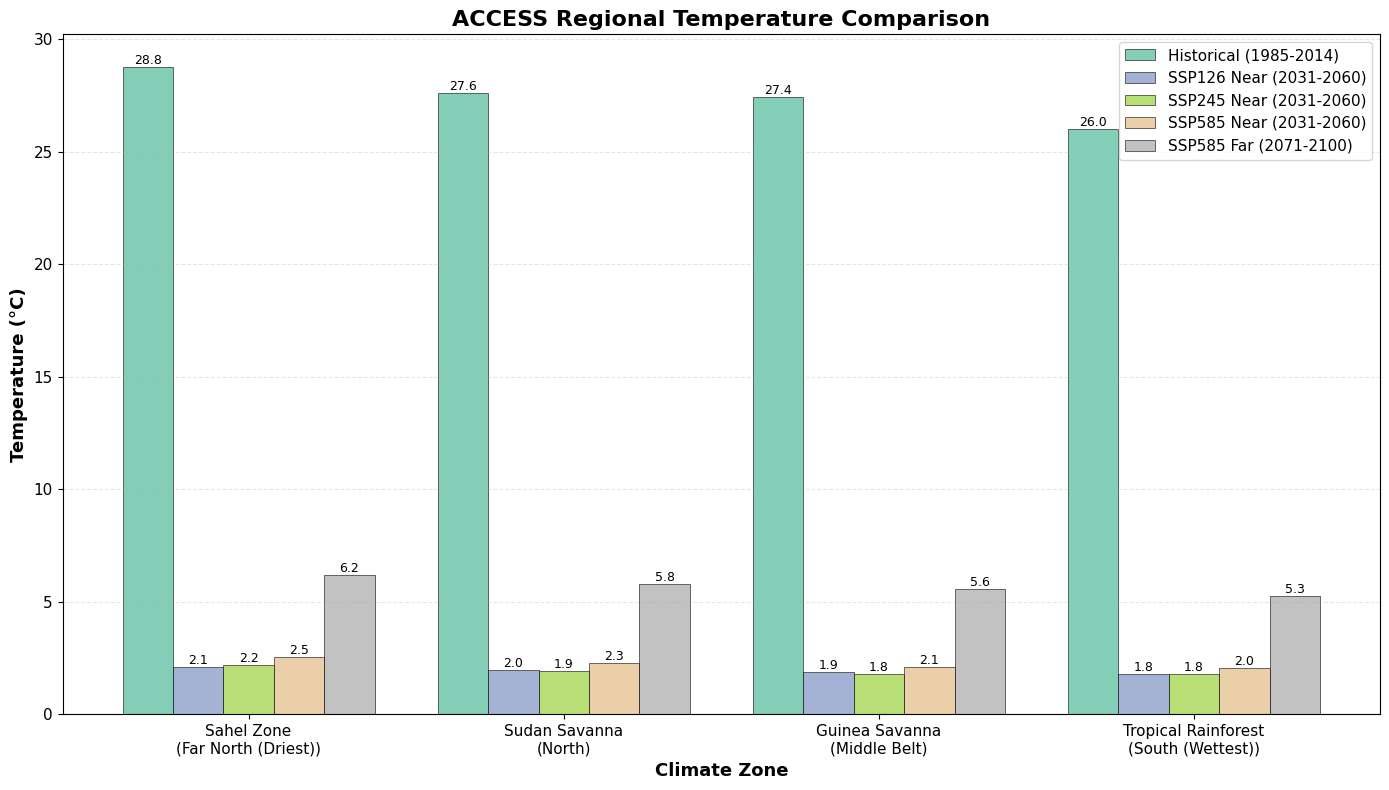

Creating regional anomalies...


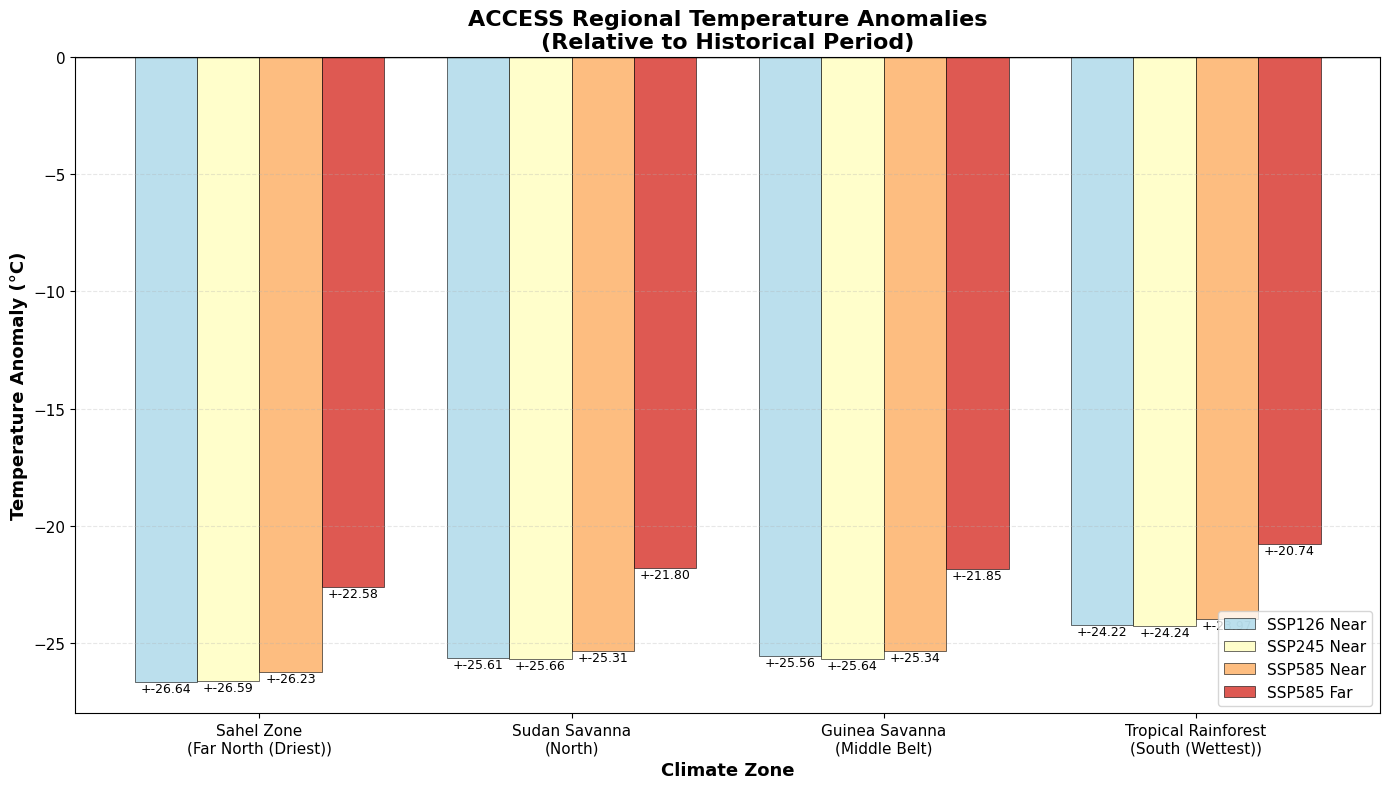


=== Regional Temperature Anomalies (°C) ===

SSP126 Near:
  Sahel Zone: +-26.64°C
  Sudan Savanna: +-25.61°C
  Guinea Savanna: +-25.56°C
  Tropical Rainforest: +-24.22°C

SSP245 Near:
  Sahel Zone: +-26.59°C
  Sudan Savanna: +-25.66°C
  Guinea Savanna: +-25.64°C
  Tropical Rainforest: +-24.24°C

SSP585 Near:
  Sahel Zone: +-26.23°C
  Sudan Savanna: +-25.31°C
  Guinea Savanna: +-25.34°C
  Tropical Rainforest: +-23.97°C

SSP585 Far:
  Sahel Zone: +-22.58°C
  Sudan Savanna: +-21.80°C
  Guinea Savanna: +-21.85°C
  Tropical Rainforest: +-20.74°C
Creating zone map...


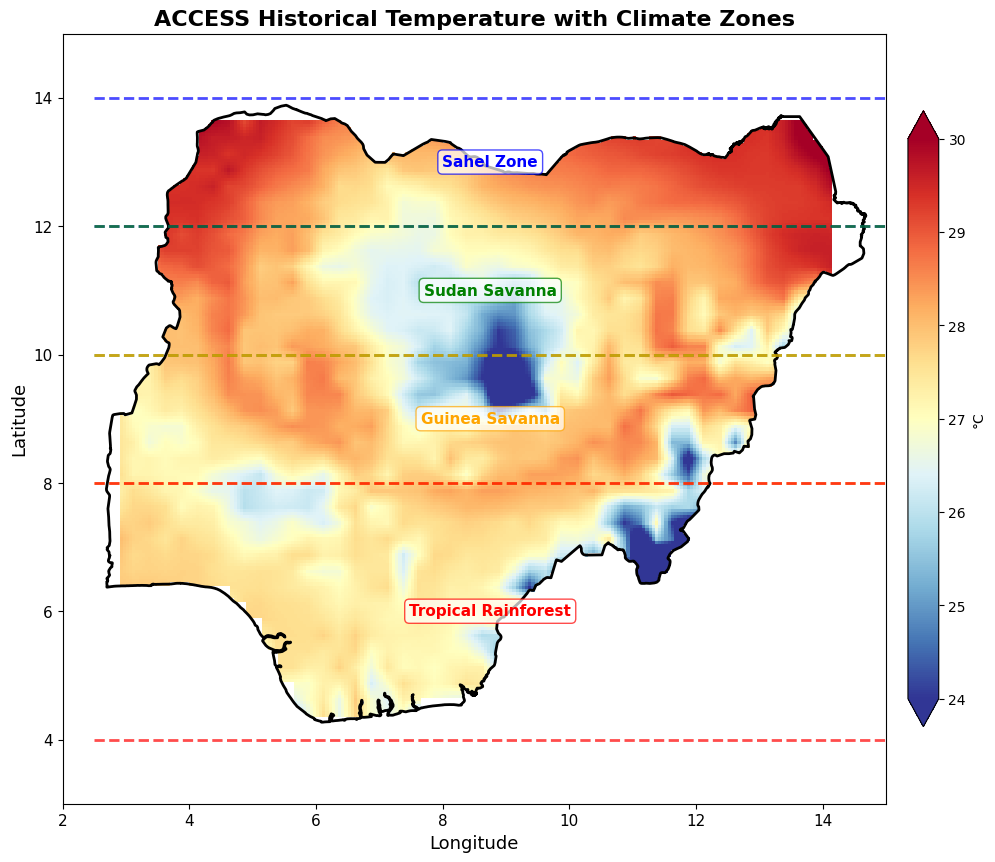


Creating summary table...

=== Regional Summary Statistics ===
               Scenario                Zone  Mean (°C)  Std (°C)  Min (°C)  Max (°C)
 Historical (1985-2014)          Sahel Zone  28.766727  0.609127 27.098612 30.099394
 Historical (1985-2014)       Sudan Savanna  27.586914  0.508231 26.164721 28.701511
 Historical (1985-2014)      Guinea Savanna  27.433002  0.465695 26.259150 28.392511
 Historical (1985-2014) Tropical Rainforest  26.021454  0.485405 24.815638 27.010923
SSP126 Near (2031-2060)          Sahel Zone   2.121787  0.522530  1.038862  3.158604
SSP126 Near (2031-2060)       Sudan Savanna   1.975175  0.463969  0.978460  2.985960
SSP126 Near (2031-2060)      Guinea Savanna   1.876405  0.416274  1.087916  2.838349
SSP126 Near (2031-2060) Tropical Rainforest   1.803651  0.376259  0.903494  2.725416
SSP245 Near (2031-2060)          Sahel Zone   2.171970  0.658713  0.939033  3.687174
SSP245 Near (2031-2060)       Sudan Savanna   1.926029  0.625981  0.730756  3.503504
S

In [230]:
shapefile_path = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"

# 1. REGIONAL TIME SERIES - See how each zone changes over time
print("Creating regional time series...")
data_dict = {
    'Historical (1985-2014)': ds_ACCESS_C_annual_celsius,
    'SSP126 Near (2031-2060)': ssp126_near_future_access,
    'SSP245 Near (2031-2060)': ssp245_near_future_access,
    'SSP585 Near (2031-2060)': ssp585_near_future_access,
    'SSP585 Far (2071-2100)': ssp585_far_future_access
}

plot_regional_timeseries(
    data_dict=data_dict,
    title='ACCESS Regional Temperature Projections',
    save_path='ACCESS_regional_timeseries.png'
)

# 2. REGIONAL COMPARISON BARS - Compare zones directly
print("Creating regional comparison...")
plot_regional_comparison(
    data_dict=data_dict,
    title='ACCESS Regional Temperature Comparison',
    save_path='ACCESS_regional_comparison.png'
)

# 3. REGIONAL ANOMALIES - Which zones warm most?
print("Creating regional anomalies...")
future_dict = {
    'SSP126 Near': ssp126_near_future_access,
    'SSP245 Near': ssp245_near_future_access,
    'SSP585 Near': ssp585_near_future_access,
    'SSP585 Far': ssp585_far_future_access
}

fig, ax, anomalies = plot_regional_anomalies(
    baseline_data=ds_ACCESS_C_annual_celsius,
    future_data_dict=future_dict,
    title='ACCESS Regional Temperature Anomalies',
    save_path='ACCESS_regional_anomalies.png'
)

# Print anomaly summary
print("\n=== Regional Temperature Anomalies (°C) ===")
for scenario, zone_anoms in anomalies.items():
    print(f"\n{scenario}:")
    for zone, anom in zone_anoms.items():
        zones = create_climate_zones()
        print(f"  {zones[zone]['name']}: +{anom:.2f}°C")

# 4. MAP WITH ZONE BOUNDARIES - Visualize zones
print("Creating zone map...")
plot_temperature_with_zones(
    data=ds_ACCESS_C_annual_celsius,
    shapefile_path=shapefile_path,
    vmin=24,
    vmax=30,
    title='ACCESS Historical Temperature with Climate Zones',
    save_path='ACCESS_zones_map.png'
)

# 5. SUMMARY TABLE
print("\nCreating summary table...")
summary_df = create_regional_summary_table(data_dict)
print("\n=== Regional Summary Statistics ===")
print(summary_df.to_string(index=False))
summary_df.to_csv('ACCESS_regional_summary.csv', index=False)

print("\n✅ Regional analysis complete! Check saved images.")


=== Running MPI Regional Analysis ===


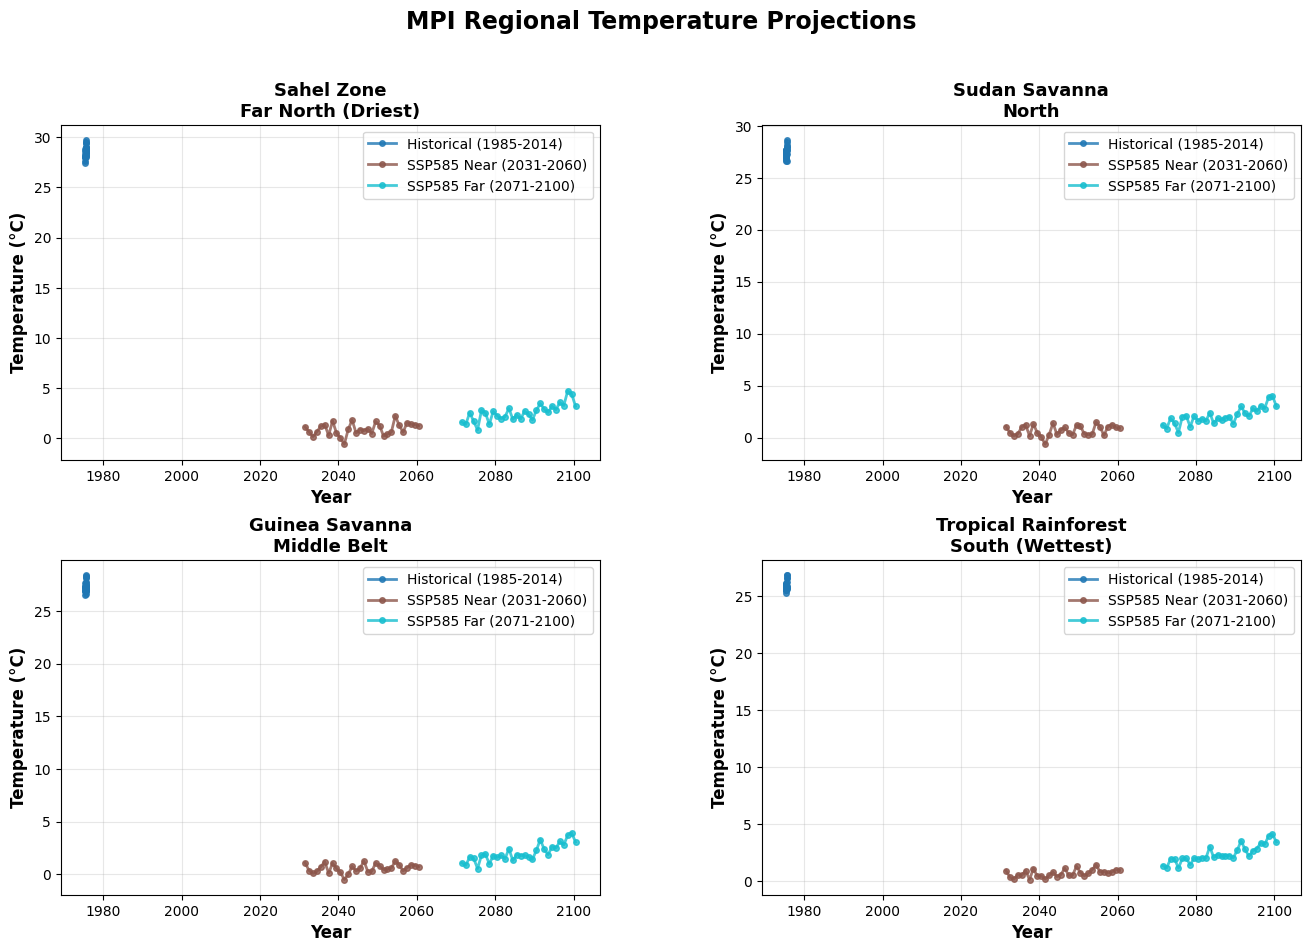

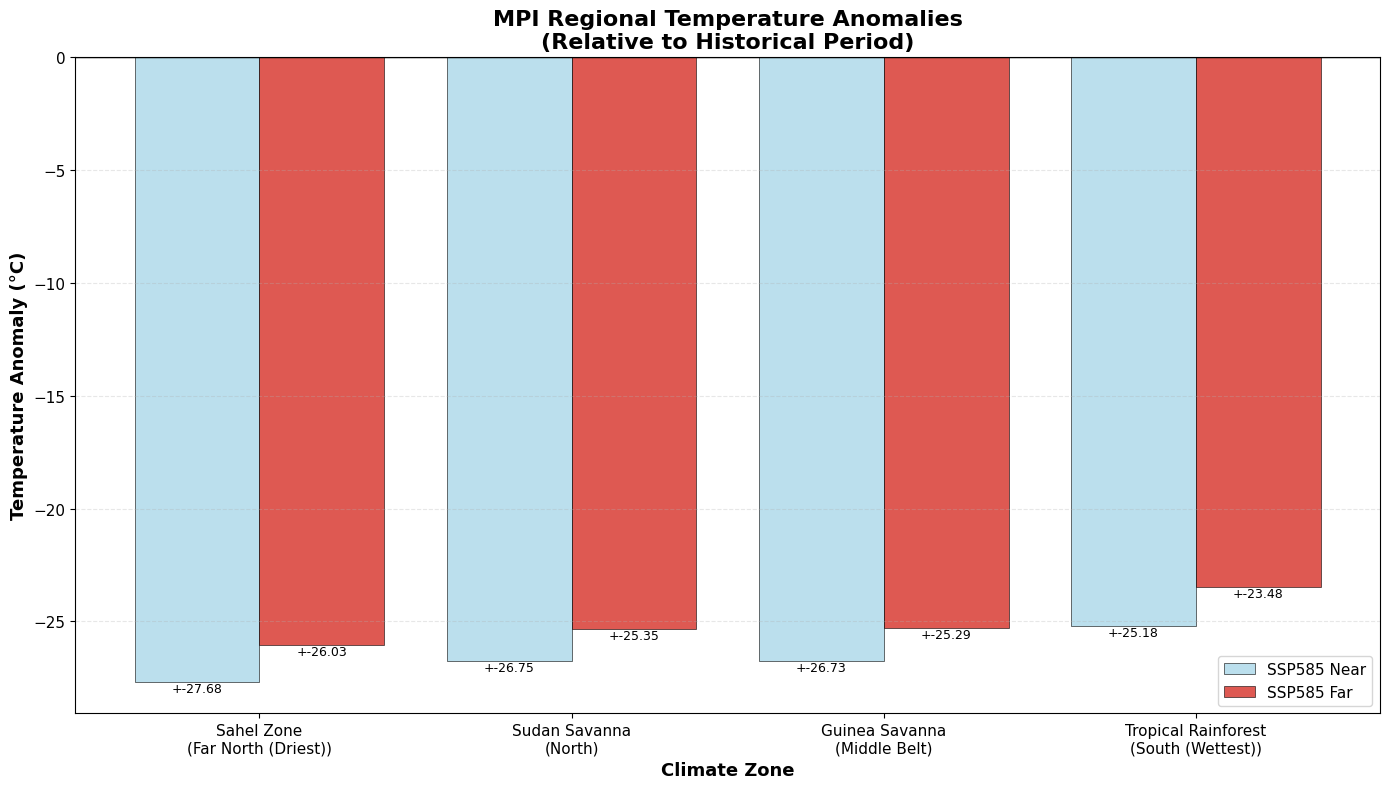

(<Figure size 1400x800 with 1 Axes>,
 <AxesSubplot: title={'center': 'MPI Regional Temperature Anomalies\n(Relative to Historical Period)'}, xlabel='Climate Zone', ylabel='Temperature Anomaly (°C)'>,
 {'SSP585 Near': {'Sahel': -27.67941290140152,
   'Sudan': -26.753943145275116,
   'Guinea': -26.729847013950348,
   'Tropical': -25.183561205863953},
  'SSP585 Far': {'Sahel': -26.02700138092041,
   'Sudan': -25.35092830657959,
   'Guinea': -25.28788685798645,
   'Tropical': -23.48434329032898}})

In [231]:
# MPI Regional Analysis
print("\n=== Running MPI Regional Analysis ===")

data_dict_mpi = {
    'Historical (1985-2014)': ds_MPI_C_annual_celsius,
    'SSP585 Near (2031-2060)': ssp585_near_future_MPI,
    'SSP585 Far (2071-2100)': ssp585_far_future_MPI
}

# Time series
plot_regional_timeseries(
    data_dict=data_dict_mpi,
    title='MPI Regional Temperature Projections',
    save_path='MPI_regional_timeseries.png'
)

# Anomalies
future_dict_mpi = {
    'SSP585 Near': ssp585_near_future_MPI,
    'SSP585 Far': ssp585_far_future_MPI
}

plot_regional_anomalies(
    baseline_data=ds_MPI_C_annual_celsius,
    future_data_dict=future_dict_mpi,
    title='MPI Regional Temperature Anomalies',
    save_path='MPI_regional_anomalies.png'
)


=== Comparing ACCESS vs MPI by Region ===


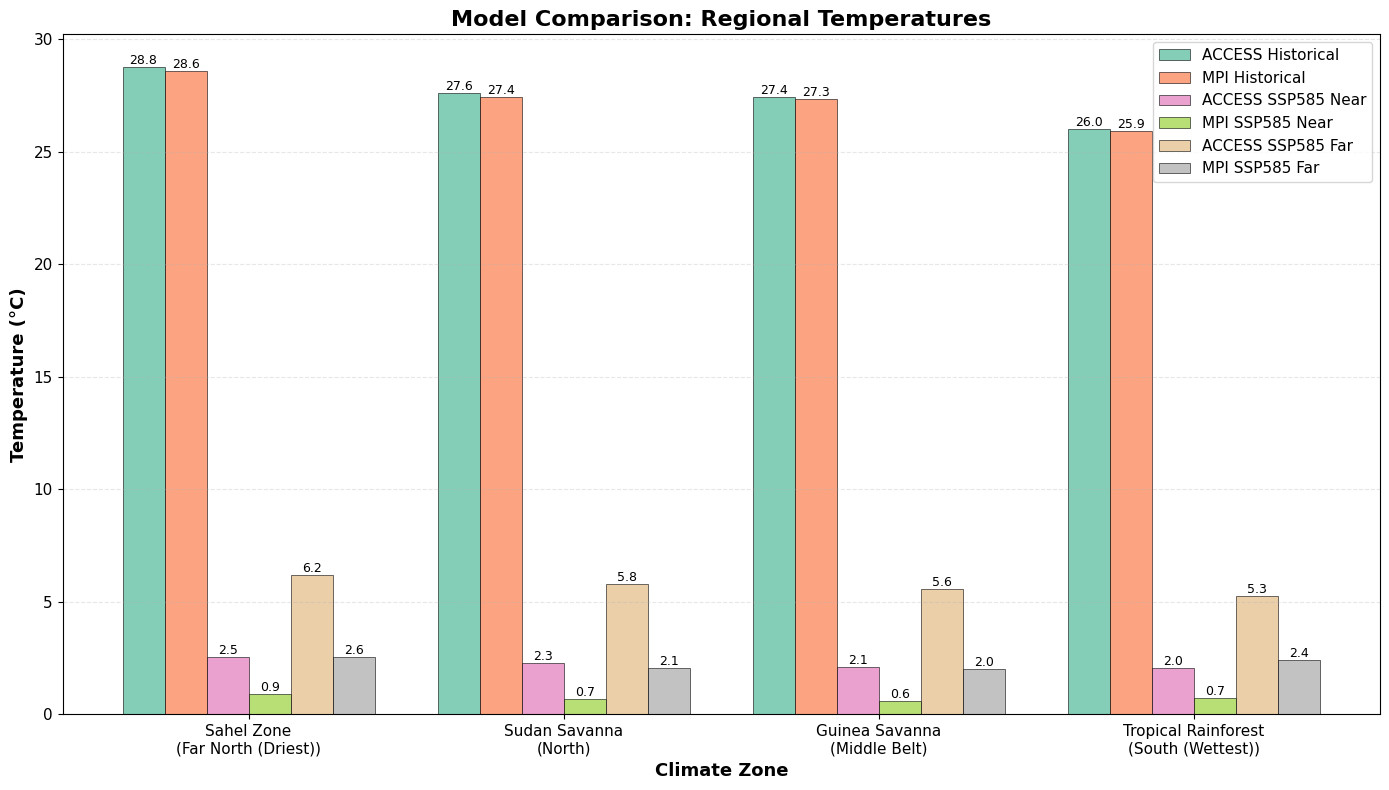

(<Figure size 1400x800 with 1 Axes>,
 <AxesSubplot: title={'center': 'Model Comparison: Regional Temperatures'}, xlabel='Climate Zone', ylabel='Temperature (°C)'>,
 {'ACCESS Historical': {'Sahel': 28.766727447509766,
   'Sudan': 27.5869140625,
   'Guinea': 27.433002471923828,
   'Tropical': 26.021453857421875},
  'MPI Historical': {'Sahel': 28.591012954711914,
   'Sudan': 27.427478790283203,
   'Guinea': 27.320405960083008,
   'Tropical': 25.89950180053711},
  'ACCESS SSP585 Near': {'Sahel': 2.539968967437744,
   'Sudan': 2.277007818222046,
   'Guinea': 2.0966336727142334,
   'Tropical': 2.0474371910095215},
  'MPI SSP585 Near': {'Sahel': 0.9116000533103943,
   'Sudan': 0.6735356450080872,
   'Guinea': 0.5905589461326599,
   'Tropical': 0.7159405946731567},
  'ACCESS SSP585 Far': {'Sahel': 6.182285785675049,
   'Sudan': 5.790616989135742,
   'Guinea': 5.582650661468506,
   'Tropical': 5.276518821716309},
  'MPI SSP585 Far': {'Sahel': 2.564011573791504,
   'Sudan': 2.0765504837036133,
 

In [232]:
# Compare models for each region
print("\n=== Comparing ACCESS vs MPI by Region ===")

comparison_data = {
    'ACCESS Historical': ds_ACCESS_C_annual_celsius,
    'MPI Historical': ds_MPI_C_annual_celsius,
    'ACCESS SSP585 Near': ssp585_near_future_access,
    'MPI SSP585 Near': ssp585_near_future_MPI,
    'ACCESS SSP585 Far': ssp585_far_future_access,
    'MPI SSP585 Far': ssp585_far_future_MPI
}

plot_regional_comparison(
    data_dict=comparison_data,
    title='Model Comparison: Regional Temperatures',
    save_path='model_comparison_regional.png'
)

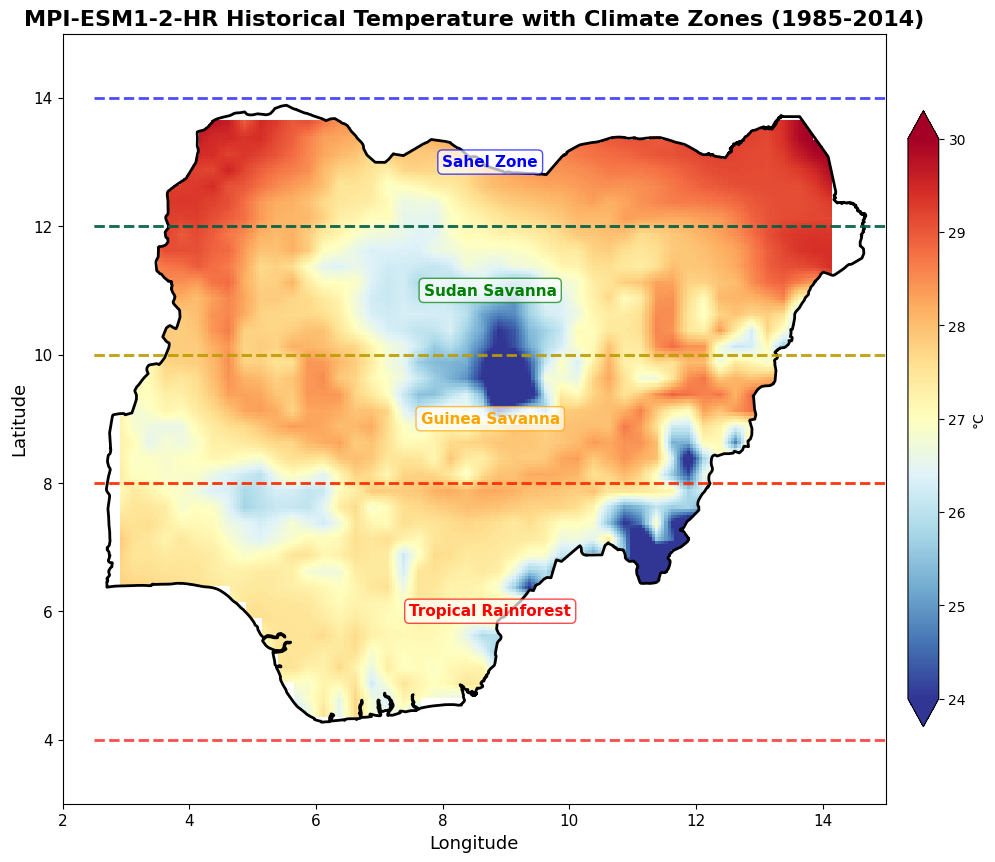

(<Figure size 1400x1000 with 2 Axes>,
 <AxesSubplot: title={'center': 'MPI-ESM1-2-HR Historical Temperature with Climate Zones (1985-2014)'}, xlabel='Longitude', ylabel='Latitude'>)

In [242]:
import matplotlib.pyplot as plt
import geopandas as gpd

shapefile_path = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"

# Use the function from the regional analysis artifact
plot_temperature_with_zones(
    data=ds_MPI_C_annual_celsius,
    shapefile_path=shapefile_path,
    vmin=24,
    vmax=30,
    cmap='RdYlBu_r',
    title='MPI-ESM1-2-HR Historical Temperature with Climate Zones (1985-2014)',
    save_path='MPI_historical_zones.png'
)

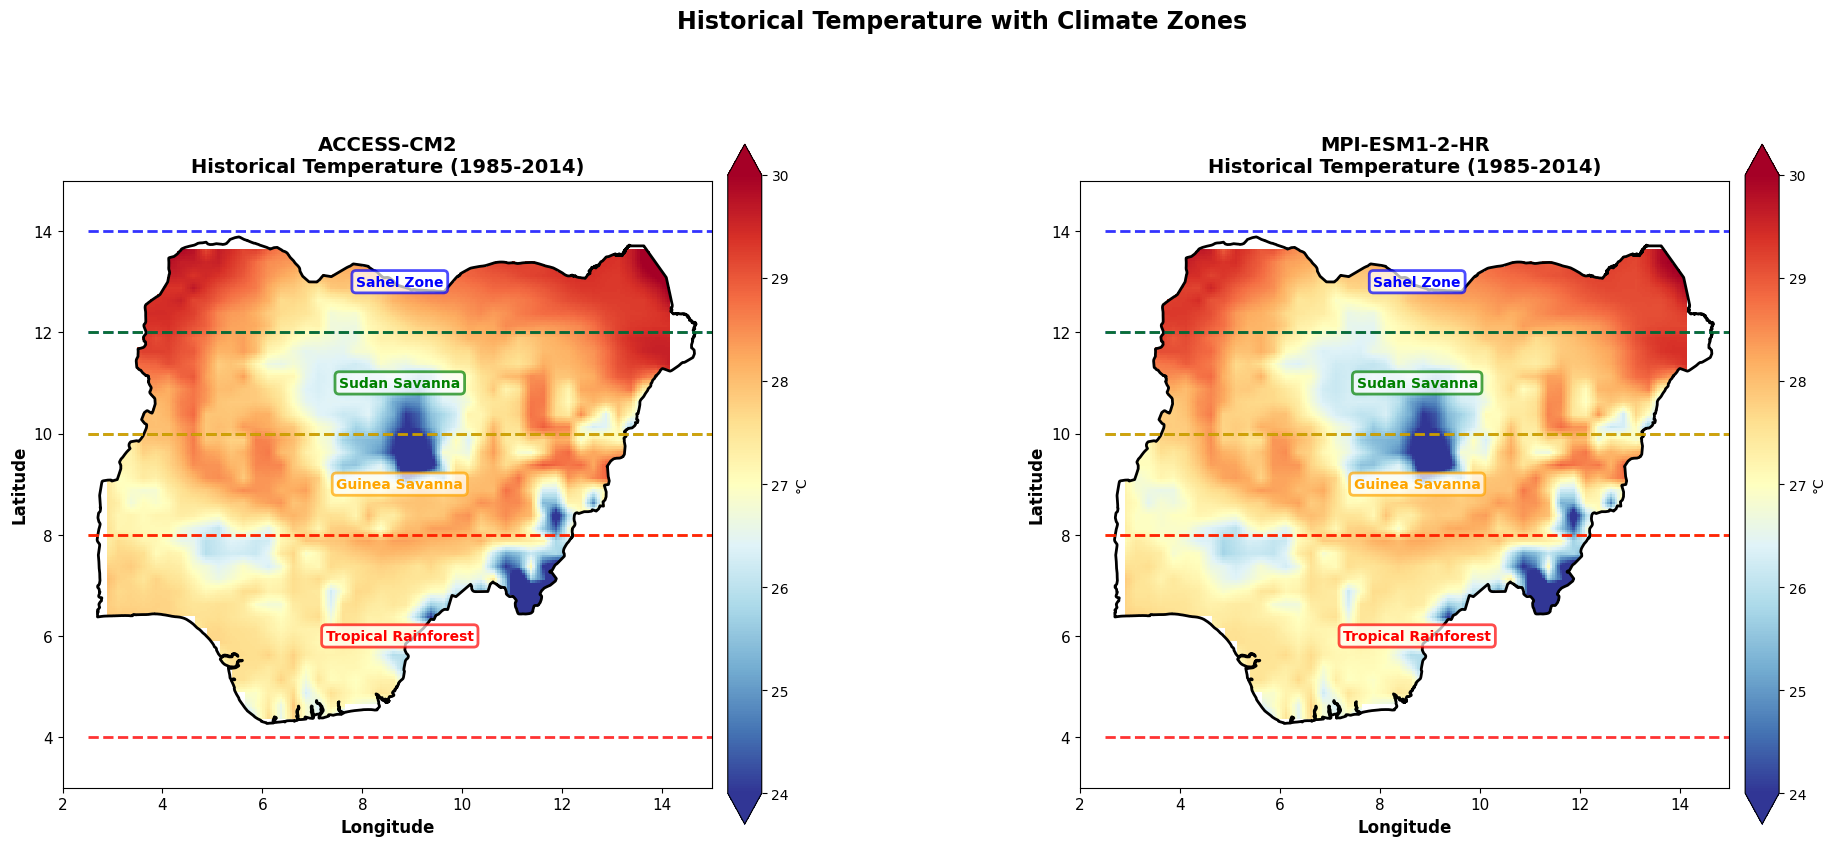

In [243]:
import matplotlib.pyplot as plt
import geopandas as gpd

shapefile_path = "/media/precious/Tpresh/CCI_2025/geoBoundaries-NGA-ADM0-all/geoBoundaries-NGA-ADM0.shp"
shp = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
zones = create_climate_zones()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.subplots_adjust(wspace=0.3, left=0.05, right=0.95, top=0.93, bottom=0.08)

models = [
    ('ACCESS-CM2', ds_ACCESS_C_annual_celsius),
    ('MPI-ESM1-2-HR', ds_MPI_C_annual_celsius)
]

colors_zones = ['blue', 'green', 'orange', 'red']

for idx, (model_name, data) in enumerate(models):
    ax = axes[idx]
    
    # If data has time dimension, take mean
    if 'time' in data.dims:
        data = data.mean(dim='time', skipna=True)
    
    # Ensure CRS
    if not hasattr(data.rio, 'crs') or data.rio.crs is None:
        data = data.rio.write_crs("EPSG:4326")
    
    # Clip to Nigeria
    data_clipped = data.rio.clip(shp.geometry, shp.crs, drop=True)
    
    # Plot temperature
    im = data_clipped.plot(
        ax=ax,
        cmap='RdYlBu_r',
        vmin=24,
        vmax=30,
        add_colorbar=True,
        cbar_kwargs={'label': '°C', 'shrink': 0.8, 'pad': 0.02}
    )
    
    # Nigeria boundary
    shp.boundary.plot(ax=ax, edgecolor='black', linewidth=2)
    
    # Draw zone boundaries
    for i, (zone_key, zone_def) in enumerate(zones.items()):
        lat_min = zone_def['lat_min']
        lat_max = zone_def['lat_max']
        lon_min = zone_def['lon_min']
        lon_max = zone_def['lon_max']
        
        # Draw horizontal lines for latitude boundaries
        ax.plot([lon_min, lon_max], [lat_min, lat_min], 
               color=colors_zones[i], linestyle='--', linewidth=2, alpha=0.8)
        ax.plot([lon_min, lon_max], [lat_max, lat_max], 
               color=colors_zones[i], linestyle='--', linewidth=2, alpha=0.8)
        
        # Add zone label
        mid_lon = (lon_min + lon_max) / 2
        mid_lat = (lat_min + lat_max) / 2
        ax.text(mid_lon, mid_lat, zone_def['name'],
               fontsize=10, fontweight='bold', color=colors_zones[i],
               ha='center', va='center',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, 
                        edgecolor=colors_zones[i], linewidth=2))
    
    # Formatting
    ax.set_xlim(2, 15)
    ax.set_ylim(3, 15)
    ax.set_title(f'{model_name}\nHistorical Temperature (1985-2014)', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=11)
    ax.grid(False)

plt.suptitle('Historical Temperature with Climate Zones', 
             fontsize=17, fontweight='bold', y=0.98)

plt.savefig('both_models_historical_zones.png', dpi=300, bbox_inches='tight')
plt.show()